In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
#Importações
import sys
from pathlib import Path, PosixPath
from copy import deepcopy

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import orjson
import pandas as pd
from IPython.display import display
from mplsoccer import Pitch
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from tqdm.auto import tqdm
import seaborn as sns

import gandula
from gandula.providers.pff.schema.gradient_event import GradientEventRow

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [3]:
MAX_FILES = None
PITCH_LENGTH = 105.0
PITCH_WIDTH = 68.0
TEST_SIZE = 0.20
RANDOM_SEED = 42
MONTE_CARLO_SIMS = 20_000
MONTE_CARLO_MAX_STEPS = 25
XT_BINS = (16, 12)
XT_TOL = 1e-6
XT_MAX_ITERS = 200
HORIZON_ACTIONS = 10

In [4]:
#LEITURA DAS TABELAS PARCIAIS GERADAS PARA FACILITAR A LEITURA
PASTA_DADOS = Path('dados')

print("⏳ Carregando suas tabelas a partir da pasta 'dados'...")

# Leitura dos arquivos
actions_df = pd.read_csv(PASTA_DADOS / 'actions_df_24_25.csv')
all_value_events_df = pd.read_csv(PASTA_DADOS / 'eventos_valor_limpos_24_25.csv')
lightweight_processing_df = pd.read_csv(PASTA_DADOS / 'lightweight_processing_df_24_25.csv')
substitutions_df = pd.read_csv(PASTA_DADOS / 'substitutions_df_24_25.csv')

print("✅ Todas as tabelas carregadas com sucesso!")

# Verificação rápida
print(f"Total de ações: {len(actions_df):,}")
print(f"Total de substituições: {len(substitutions_df):,}")

# Diagnóstico para confirmar que carregou tudo certo
print(f"✅ Extração Concluída (Via Checkpoint)!")
print(f"Total de Substituições Prontas: {len(substitutions_df):,}")
print(f"Total de Eventos de Valor Extraídos: {len(all_value_events_df):,}")

# Opcional: Mostra os gols para confirmar que está tudo OK
chutes_df = all_value_events_df[all_value_events_df['possession_events_possession_event_type'] == 'SH']
print("\n--- Resultados dos Chutes (Shot Outcomes) ---")
print(chutes_df['possession_events_shot_outcome_type'].value_counts())

⏳ Carregando suas tabelas a partir da pasta 'dados'...
✅ Todas as tabelas carregadas com sucesso!
Total de ações: 762,325
Total de substituições: 3,207
✅ Extração Concluída (Via Checkpoint)!
Total de Substituições Prontas: 3,207
Total de Eventos de Valor Extraídos: 397,818

--- Resultados dos Chutes (Shot Outcomes) ---
possession_events_shot_outcome_type
O    3429
B    2858
S    2292
G    1211
C     218
F      78
L      56
Name: count, dtype: int64


In [5]:
EVENTS_DIR = Path('dados')
players_df = pd.read_json(
    EVENTS_DIR / 'players.json'
)

In [6]:
player_names = players_df[
    ['id', 'nickname']
].drop_duplicates()

In [7]:
substitutions_df.head()

,match_id,competition_name,season,game_event_id,period,start_time,end_time,player_on_id,player_off_id,minute,player_on_name,player_off_name,team_id
0,31995,Premier League,2024-2025,24426845,2,"3,801.7020","3,801.7020","9,914.0000",105.0000,63,Joshua Zirkzee,Mason Mount,12.0000
1,31995,Premier League,2024-2025,24426846,2,"3,803.5700","3,803.5700","7,832.0000","2,123.0000",63,Alejandro Garnacho,Amad Diallo,12.0000
2,31995,Premier League,2024-2025,24426847,2,"3,994.3610","3,994.3610","1,981.0000","2,118.0000",66,Tom Cairney,Emile Smith Rowe,54.0000
3,31995,Premier League,2024-2025,24426848,2,"4,865.5990","4,865.5990",308.0000,250.0000,81,Harry Wilson,Adama Traoré,54.0000
4,31995,Premier League,2024-2025,24426849,2,"4,871.8720","4,871.8720",252.0000,"7,220.0000",81,Raúl Jiménez,Rodrigo Muniz,54.0000


In [8]:

ACTION_TYPE_MAP = {
    'PA': 'pass',
    'CR': 'cross',
    'BC': 'carry',
    'SH': 'shot',
    'IT': 'interception',
    'CH': 'challenge',
    'CL': 'clearance',
    'RE': 'rebound',
    'TC': 'touch_control',
    'FO': 'foul',
}

XT_ACTION_TYPES = ['pass', 'cross', 'carry', 'shot']



def _first_notna(*values):
    for value in values:
        if pd.notna(value):
            return value
    return np.nan



def _coerce_int(value):
    if pd.isna(value):
        return np.nan
    try:
        return int(value)
    except (TypeError, ValueError):
        return np.nan



def _safe_ball_xy(ball_snapshot):
    if not isinstance(ball_snapshot, list) or len(ball_snapshot) == 0:
        return np.nan, np.nan
    ball = ball_snapshot[0] or {}
    return ball.get('x', np.nan), ball.get('y', np.nan)




def _find_player_snapshot(row_dict, player_id):
    return _find_player_in_snapshots(row_dict.get('home_players'), row_dict.get('away_players'), player_id)



def _snapshot_with_coords(player_snapshot):
    if player_snapshot is None:
        return None
    x = player_snapshot.get('x', np.nan)
    y = player_snapshot.get('y', np.nan)
    if pd.isna(x) or pd.isna(y):
        return None
    return player_snapshot



def _executor_player_id(row_dict):
    event_type = row_dict.get('possession_events_possession_event_type')
    candidates = {
        'PA': [row_dict.get('possession_events_passer_player_id'), row_dict.get('game_events_player_id')],
        'CR': [row_dict.get('possession_events_crosser_player_id'), row_dict.get('game_events_player_id')],
        'BC': [
            row_dict.get('possession_events_ball_carrier_player_id'),
            row_dict.get('possession_events_carrier_player_id'),
            row_dict.get('game_events_player_id'),
        ],
        'SH': [row_dict.get('possession_events_shooter_player_id'), row_dict.get('game_events_player_id')],
        'CL': [row_dict.get('possession_events_clearer_player_id'), row_dict.get('game_events_player_id')],
        'RE': [row_dict.get('possession_events_rebounder_player_id'), row_dict.get('game_events_player_id')],
        'TC': [row_dict.get('possession_events_touch_player_id'), row_dict.get('game_events_player_id')],
        'CH': [row_dict.get('possession_events_challenger_player_id'), row_dict.get('game_events_player_id')],
        'IT': [row_dict.get('game_events_player_id')],
        'FO': [row_dict.get('game_events_player_id')],
    }.get(event_type, [row_dict.get('game_events_player_id')])

    return _first_notna(*candidates)



def _target_player_id(row_dict):
    event_type = row_dict.get('possession_events_possession_event_type')
    candidates = {
        'PA': [
            row_dict.get('possession_events_target_player_id'),
            row_dict.get('possession_events_receiver_player_id'),
        ],
        'CR': [row_dict.get('possession_events_target_player_id')],
        'BC': [
            row_dict.get('possession_events_target_player_id'),
            row_dict.get('possession_events_movement_player_id'),
            row_dict.get('possession_events_ball_carrier_player_id'),
            row_dict.get('possession_events_carrier_player_id'),
        ],
        'SH': [],
        'IT': [],
        'CH': [],
        'CL': [],
        'RE': [],
        'TC': [],
        'FO': [],
    }.get(event_type, [])

    return _first_notna(*candidates)



def _reverse_direction(direction):
    return 'L' if direction == 'R' else 'R'



def _infer_attack_direction(row_dict):
    direction = row_dict.get('stadium_metadata_team_attacking_direction')
    if isinstance(direction, str) and direction in {'L', 'R'}:
        return direction

    home_team = row_dict.get('game_events_home_team')
    period = row_dict.get('game_events_period')
    home_team_start_left = row_dict.get('stadium_metadata_home_team_start_left')

    if pd.isna(home_team) or pd.isna(period) or pd.isna(home_team_start_left):
        return np.nan

    period = int(period)
    home_team_start_left = bool(home_team_start_left)
    home_attacks_right_p1 = home_team_start_left
    home_direction = 'R' if home_attacks_right_p1 else 'L'

    if period % 2 == 0:
        home_direction = _reverse_direction(home_direction)

    return home_direction if bool(home_team) else _reverse_direction(home_direction)



def _orient_center_coordinates(x, y, attack_direction):
    if pd.isna(x) or pd.isna(y):
        return np.nan, np.nan
    if attack_direction == 'L':
        return -x, -y
    return x, y



def _centre_to_pitch(x, y, pitch_length=PITCH_LENGTH, pitch_width=PITCH_WIDTH):
    if pd.isna(x) or pd.isna(y):
        return np.nan, np.nan
    x_pitch = np.clip(x + pitch_length / 2.0, 0.0, pitch_length)
    y_pitch = np.clip(y + pitch_width / 2.0, 0.0, pitch_width)
    return x_pitch, y_pitch



def _raw_outcome(row_dict, action_code):
    outcome_map = {
        'PA': 'possession_events_pass_outcome_type',
        'CR': 'possession_events_cross_outcome_type',
        'BC': 'possession_events_ball_carry_outcome',
        'SH': 'possession_events_shot_outcome_type',
        'CH': 'possession_events_challenge_outcome_type',
        'CL': 'possession_events_clearance_outcome_type',
        'RE': 'possession_events_rebound_outcome_type',
        'TC': 'possession_events_touch_outcome_type',
        'FO': 'fouls_final_foul_outcome_type',
    }
    col = outcome_map.get(action_code)
    return row_dict.get(col) if col is not None else np.nan



def _future_target_snapshot_from_events(records, row_idx, target_player_id, max_seconds=5.0, control_radius=2.0):
    if pd.isna(target_player_id):
        return None

    current_row = records[row_idx]
    match_id = current_row.get('game_id')
    period = current_row.get('game_events_period')
    start_time = current_row.get('start_time')

    best_snapshot = None
    best_distance = np.inf

    for future_row in records[row_idx + 1:]:
        if future_row.get('game_id') != match_id:
            break

        future_period = future_row.get('game_events_period')
        if pd.notna(period) and pd.notna(future_period):
            base_period = int(period)
            future_period = int(future_period)
            if future_period < base_period:
                continue
            if future_period > base_period:
                break

        if pd.notna(start_time) and pd.notna(future_row.get('start_time')):
            delta_t = float(future_row.get('start_time')) - float(start_time)
            if delta_t < 0:
                continue
            if delta_t > max_seconds:
                break

        target_snapshot = _snapshot_with_coords(_find_player_snapshot(future_row, target_player_id))
        if target_snapshot is None:
            continue

        ball_x, ball_y = _safe_ball_xy(future_row.get('ball'))
        if pd.notna(ball_x) and pd.notna(ball_y):
            ball_distance = float(np.hypot(ball_x - target_snapshot['x'], ball_y - target_snapshot['y']))
            if ball_distance <= control_radius:
                return target_snapshot
            if ball_distance < best_distance:
                best_distance = ball_distance
                best_snapshot = target_snapshot
        elif best_snapshot is None:
            best_snapshot = target_snapshot

    return best_snapshot



def build_actions_from_events(flat_events_df):
    rows = []
    records = flat_events_df.to_dict('records')

    for row_idx, row_dict in enumerate(records):
        action_code = row_dict.get('possession_events_possession_event_type')
        if action_code not in ACTION_TYPE_MAP:
            continue

        action_type = ACTION_TYPE_MAP[action_code]
        executor_player_id = _executor_player_id(row_dict)
        executor_snapshot = _snapshot_with_coords(_find_player_snapshot(row_dict, executor_player_id))
        target_player_id = _target_player_id(row_dict)
        same_event_target_snapshot = _snapshot_with_coords(_find_player_snapshot(row_dict, target_player_id))

        future_target_snapshot = None
        if action_type in {'pass', 'cross', 'carry'}:
            future_target_snapshot = _future_target_snapshot_from_events(records, row_idx, target_player_id)

        target_snapshot = future_target_snapshot or same_event_target_snapshot
        endpoint_source = 'future_event_snapshot' if future_target_snapshot is not None else 'same_event_snapshot'
        if target_snapshot is None:
            endpoint_source = 'missing'

        start_x_center, start_y_center = _safe_ball_xy(row_dict.get('ball'))
        if (pd.isna(start_x_center) or pd.isna(start_y_center)) and executor_snapshot is not None:
            start_x_center = executor_snapshot.get('x', np.nan)
            start_y_center = executor_snapshot.get('y', np.nan)

        if target_snapshot is None:
            end_x_center, end_y_center = np.nan, np.nan
        else:
            end_x_center = target_snapshot.get('x', np.nan)
            end_y_center = target_snapshot.get('y', np.nan)

        attack_direction = _infer_attack_direction(row_dict)
        start_x_center, start_y_center = _orient_center_coordinates(start_x_center, start_y_center, attack_direction)
        end_x_center, end_y_center = _orient_center_coordinates(end_x_center, end_y_center, attack_direction)

        start_x, start_y = _centre_to_pitch(start_x_center, start_y_center)
        end_x, end_y = _centre_to_pitch(end_x_center, end_y_center)

        raw_outcome = _raw_outcome(row_dict, action_code)
        goal = int(action_type == 'shot' and raw_outcome == 'G')

        if action_type == 'pass':
            success = int(raw_outcome == 'C')
        elif action_type == 'cross':
            success = int(raw_outcome == 'C')
        elif action_type == 'carry':
            success = int(raw_outcome in {'R', 'L', 'C'} or target_snapshot is not None)
        elif action_type == 'shot':
            success = goal
        else:
            success = np.nan

        rows.append(
            {
                'match_id': _coerce_int(row_dict.get('game_id')),
                'competition_name': row_dict.get('competition_name'),
                'season': row_dict.get('season'),
                'game_event_id': _coerce_int(row_dict.get('game_event_id')),
                'possession_event_id': _coerce_int(row_dict.get('possession_event_id')),
                'sequence': row_dict.get('sequence'),
                'start_time': row_dict.get('start_time'),
                'end_time': row_dict.get('end_time'),
                'period': _coerce_int(row_dict.get('game_events_period')),
                'team_id': _coerce_int(row_dict.get('game_events_team_id')),
                'home_team': row_dict.get('game_events_home_team'),
                'team_side': 'home' if bool(row_dict.get('game_events_home_team')) else 'away',
                'player_id': _coerce_int(executor_player_id),
                'target_player_id': _coerce_int(target_player_id),
                'action_code': action_code,
                'action_type': action_type,
                'attack_direction': attack_direction,
                'endpoint_source': endpoint_source,
                'x': start_x,
                'y': start_y,
                'x_end': end_x,
                'y_end': end_y,
                'success': success,
                'goal': goal,
                'raw_outcome': raw_outcome,
            }
        )

    actions = pd.DataFrame(rows)
    actions = actions.sort_values(['match_id', 'period', 'start_time', 'game_event_id']).reset_index(drop=True)
    return actions


def build_actions_table_from_paths(paths):
    action_tables = []
    processing_rows = []

    for path in tqdm(paths, desc='Carregando todos os arquivos de forma leve', leave=False):
        light_events_df = load_light_events_df(path)
        action_df = build_actions_from_events(light_events_df)
        action_tables.append(action_df)
        processing_rows.append(
            {
                'file_name': Path(path).name,
                'n_action_events_after_slim': len(light_events_df),
                'n_actions_final': len(action_df),
                'n_slim_columns': len(light_events_df.columns),
            }
        )
        del light_events_df

    actions_df = pd.concat(action_tables, ignore_index=True)
    actions_df = actions_df.sort_values(['match_id', 'period', 'start_time', 'game_event_id']).reset_index(drop=True)
    processing_df = pd.DataFrame(processing_rows)
    return actions_df, processing_df


In [9]:

#actions_df, lightweight_processing_df = build_actions_table_from_paths(event_paths)

print('Nao concatenamos o dataframe completo de eventos para todos os jogos.')
print('Cada arquivo foi achatado, reduzido ao minimo necessario para a aula e descartado em seguida.')
display(lightweight_processing_df.head(10))

modeling_view_cols = [
    'match_id',
    'game_event_id',
    'action_type',
    'x',
    'y',
    'x_end',
    'y_end',
    'success',
    'goal',
    'attack_direction',
]
display(actions_df[modeling_view_cols].head(10))

coverage_rows = []
for action_type, group in actions_df.groupby('action_type'):
    coverage_rows.append(
        {
            'action_type': action_type,
            'n_actions': len(group),
            'start_coord_coverage': group[['x', 'y']].notna().all(axis=1).mean(),
            'end_coord_coverage': group[['x_end', 'y_end']].notna().all(axis=1).mean(),
            'success_rate': group['success'].mean(),
            'goal_rate': group['goal'].mean(),
        }
    )
coverage_df = pd.DataFrame(coverage_rows).sort_values('n_actions', ascending=False).reset_index(drop=True)

display(coverage_df)
display(
    actions_df[['action_type', 'raw_outcome']]
    .value_counts(dropna=False)
    .rename('n')
    .reset_index()
    .head(20)
)


Nao concatenamos o dataframe completo de eventos para todos os jogos.
Cada arquivo foi achatado, reduzido ao minimo necessario para a aula e descartado em seguida.


,file_name,n_action_events_after_slim,n_actions_final,n_slim_columns
0,32272.json,1962,1962,39
1,32048.json,2053,2053,39
2,31996.json,2012,2012,39
3,32112.json,2183,2183,39
4,32100.json,2127,2127,39
5,32111.json,2050,2050,39
6,32098.json,2107,2107,39
7,32231.json,1902,1902,39
8,32068.json,2145,2145,39
9,32275.json,1937,1937,39


,match_id,game_event_id,action_type,x,y,x_end,y_end,success,goal,attack_direction
0,31995,24426842,pass,50.8400,33.8900,43.1510,33.9450,1.0000,0,L
1,31995,24426890,interception,44.5400,33.5300,NaN,NaN,NaN,0,L
2,31995,24426890,pass,42.4200,31.3200,27.5670,27.5560,1.0000,0,L
3,31995,24426892,interception,28.0500,27.1700,NaN,NaN,NaN,0,L
4,31995,24426892,pass,31.3400,11.5800,62.3120,1.6840,1.0000,0,L
5,31995,24426893,touch_control,64.4500,6.3100,NaN,NaN,NaN,0,L
6,31995,24426895,challenge,43.5400,57.5900,NaN,NaN,NaN,0,R
7,31995,24426895,pass,39.2200,66.7700,46.2200,67.0660,1.0000,0,R
8,31995,24426897,interception,46.0000,66.8300,NaN,NaN,NaN,0,R
9,31995,24426897,pass,48.1600,66.2000,52.4300,63.1670,0.0000,0,R


,action_type,n_actions,start_coord_coverage,end_coord_coverage,success_rate,goal_rate
0,pass,356552,1.0000,0.9998,0.8347,0.0000
1,interception,257558,1.0000,0.0000,NaN,0.0000
2,challenge,66681,0.9996,0.0000,NaN,0.0000
3,clearance,16802,1.0000,0.0000,NaN,0.0000
4,carry,15673,1.0000,1.0000,1.0000,0.0000
5,rebound,15584,1.0000,0.0000,NaN,0.0000
6,cross,15451,1.0000,0.9375,0.2227,0.0000
7,shot,10142,1.0000,0.0000,0.1194,0.1194
8,touch_control,7627,1.0000,0.0000,NaN,0.0000
9,foul,255,0.9569,0.0000,NaN,0.0000


,action_type,raw_outcome,n
0,pass,C,297615
1,interception,NaN,257558
2,pass,D,44269
3,challenge,R,21180
4,challenge,D,18367
5,carry,R,13691
6,challenge,P,11055
7,clearance,P,10857
8,rebound,P,10652
9,cross,D,8611


In [10]:
actions_df.columns

Index(['match_id', 'competition_name', 'season', 'game_event_id',
       'possession_event_id', 'sequence', 'start_time', 'end_time', 'period',
       'team_id', 'home_team', 'team_side', 'player_id', 'target_player_id',
       'action_code', 'action_type', 'attack_direction', 'endpoint_source',
       'x', 'y', 'x_end', 'y_end', 'success', 'goal', 'raw_outcome'],
      dtype='str')

In [11]:

FINAL_THIRD_START_X = 70.0
PENALTY_BOX_START_X = PITCH_LENGTH - 16.5
PENALTY_BOX_WIDTH_Y = 40.32
PENALTY_BOX_Y_MIN = (PITCH_WIDTH - PENALTY_BOX_WIDTH_Y) / 2.0
PENALTY_BOX_Y_MAX = PITCH_WIDTH - PENALTY_BOX_Y_MIN

TRANSIENT_STATES = [
    'build_up',
    'middle',
    'final_third_right',
    'final_third_middle',
    'final_third_left',
    'box',
]
ABSORBING_STATES = ['goal', 'loss']
SARAH_STATES = TRANSIENT_STATES + ABSORBING_STATES
RUDD_STATE_COLORS = {
    'build_up': '#d9e6f2',
    'middle': '#c7dced',
    'final_third_right': '#f6d6bd',
    'final_third_middle': '#f4b183',
    'final_third_left': '#f6d6bd',
    'box': '#de6a2c',
}



def make_match_split(match_ids, test_size=0.30, random_state=42):
    unique_ids = np.array(sorted(pd.unique(match_ids)))
    if len(unique_ids) < 2:
        raise ValueError('Precisamos de pelo menos 2 jogos para fazer avaliacao out-of-sample.')

    rng = np.random.default_rng(random_state)
    shuffled = unique_ids.copy()
    rng.shuffle(shuffled)

    n_test = max(1, int(np.ceil(len(shuffled) * test_size)))
    n_test = min(n_test, len(shuffled) - 1)

    test_ids = np.sort(shuffled[:n_test])
    train_ids = np.sort(shuffled[n_test:])
    return train_ids.tolist(), test_ids.tolist()



def add_sequence_goal_target(actions):
    df = actions.copy()
    df['sequence_goal'] = np.nan

    valid_mask = df['sequence'].notna() & df['team_id'].notna() & df['match_id'].notna()
    seq_goal = (
        df.loc[valid_mask]
        .groupby(['match_id', 'team_id', 'sequence'])['goal']
        .transform('max')
    )
    df.loc[valid_mask, 'sequence_goal'] = seq_goal.astype(float)
    return df



def div_no_nan(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.zeros_like(num, dtype=float)
    np.divide(num, den, out=out, where=den != 0)
    return out



def safe_roc_auc(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)



def safe_roc_curve(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    if len(np.unique(y_true)) < 2:
        return None
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return {'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds}



def evaluate_binary_predictions(y_true, y_prob, model_name, target_name):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    mask = pd.notna(y_true) & pd.notna(y_prob)
    y_true = y_true[mask].astype(int)
    y_prob = y_prob[mask].astype(float)
    y_prob = np.clip(y_prob, 1e-6, 1 - 1e-6)

    metrics = {
        'model': model_name,
        'target': target_name,
        'n': len(y_true),
        'positive_rate': y_true.mean() if len(y_true) else np.nan,
        'brier_score': brier_score_loss(y_true, y_prob) if len(y_true) else np.nan,
        'roc_auc': safe_roc_auc(y_true, y_prob) if len(y_true) else np.nan,
    }
    curve = safe_roc_curve(y_true, y_prob) if len(y_true) else None
    return metrics, curve



def plot_roc_curves(curve_specs, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    plotted = False

    for spec in curve_specs:
        curve = spec.get('curve')
        label = spec.get('label', 'modelo')
        auc = spec.get('auc', np.nan)
        if curve is None:
            continue
        plotted = True
        suffix = '' if pd.isna(auc) else f' (AUC = {auc:.3f})'
        ax.plot(curve['fpr'], curve['tpr'], linewidth=2, label=label + suffix)

    ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    if plotted:
        ax.legend(loc='lower right')
    else:
        ax.text(0.5, 0.5, 'ROC indisponivel (apenas uma classe no teste).', ha='center', va='center')
    plt.show()


In [12]:

actions_df = add_sequence_goal_target(actions_df)
train_match_ids, test_match_ids = make_match_split(
    actions_df['match_id'].dropna().unique(),
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
)

split_summary = pd.DataFrame(
    {
        'split': ['train', 'test'],
        'n_matches': [len(train_match_ids), len(test_match_ids)],
        'n_actions': [
            actions_df['match_id'].isin(train_match_ids).sum(),
            actions_df['match_id'].isin(test_match_ids).sum(),
        ],
        'positive_rate_sequence_goal': [
            actions_df.loc[actions_df['match_id'].isin(train_match_ids), 'sequence_goal'].mean(),
            actions_df.loc[actions_df['match_id'].isin(test_match_ids), 'sequence_goal'].mean(),
        ],
    }
)

display(split_summary)


,split,n_matches,n_actions,positive_rate_sequence_goal
0,train,304,609055,0.0171
1,test,76,153270,0.0174


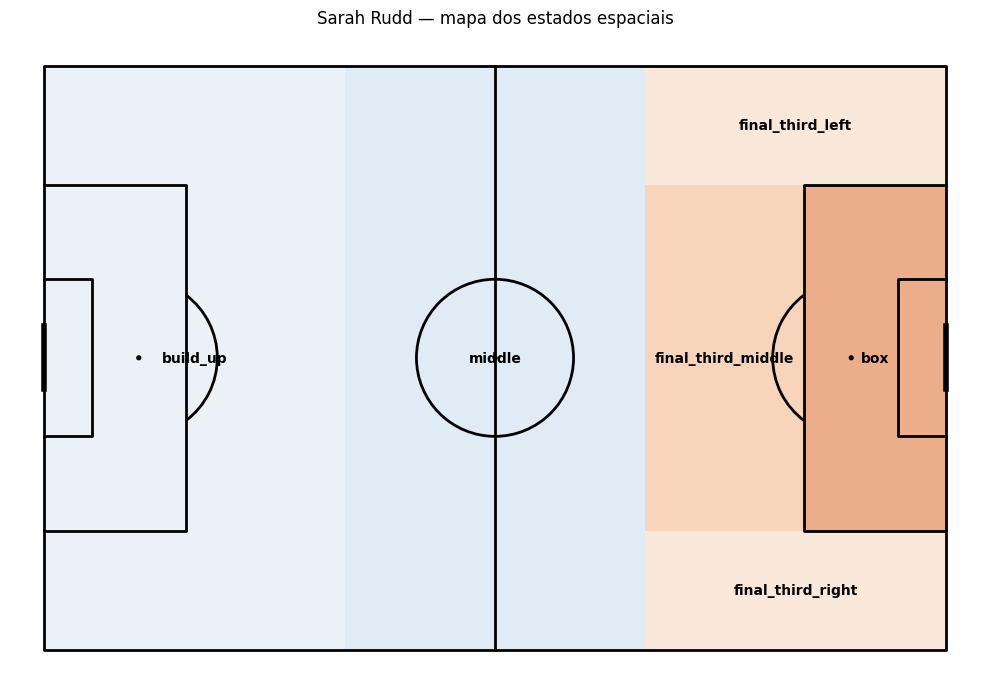

,build_up,middle,final_third_right,final_third_middle,final_third_left,box,goal,loss
build_up,"53,079.0000","16,183.0000",117.0000,227.0000,149.0000,14.0000,0.0000,"16,625.0000"
middle,"12,201.0000","96,636.0000","4,715.0000","5,158.0000","5,108.0000",527.0000,5.0000,"20,292.0000"
final_third_right,10.0000,"2,624.0000","8,758.0000","2,595.0000",14.0000,"1,546.0000",1.0000,"4,909.0000"
final_third_middle,28.0000,"2,895.0000","2,758.0000","10,824.0000","2,838.0000","2,355.0000",75.0000,"7,218.0000"
final_third_left,11.0000,"2,986.0000",15.0000,"2,879.0000","9,710.0000","1,588.0000",0.0000,"4,994.0000"
box,2.0000,9.0000,238.0000,858.0000,259.0000,"2,861.0000",882.0000,"9,848.0000"


,algebra_linear,iteracao,monte_carlo
build_up,0.0039,0.0039,0.0040
middle,0.0073,0.0073,0.0069
final_third_right,0.0161,0.0161,0.0175
final_third_middle,0.0200,0.0200,0.0200
final_third_left,0.0159,0.0159,0.0165
box,0.0750,0.0750,0.0757


,model,target,n,positive_rate,brier_score,roc_auc
0,sarah_algebra_linear,sequence_goal,80134,0.0193,0.0186,0.6637
1,sarah_iteracao,sequence_goal,80134,0.0193,0.0186,0.6637
2,sarah_monte_carlo,sequence_goal,80134,0.0193,0.0187,0.6637


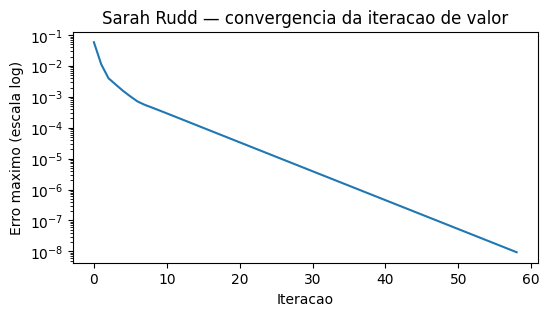

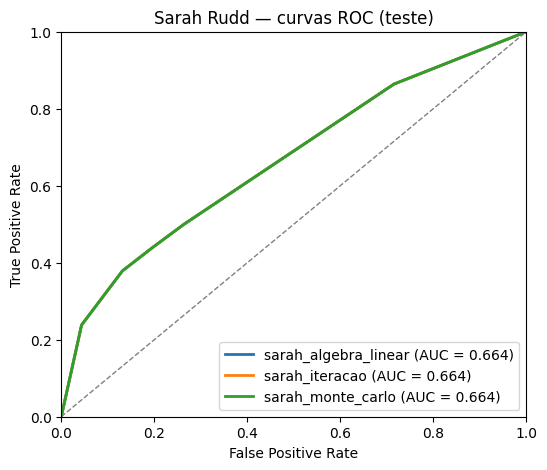

In [13]:

def rudd_state_from_xy(x, y):
    if pd.isna(x) or pd.isna(y):
        return np.nan
    if x < 35.0:
        return 'build_up'
    if x < FINAL_THIRD_START_X:
        return 'middle'
    in_penalty_lane = PENALTY_BOX_Y_MIN <= y <= PENALTY_BOX_Y_MAX
    if x >= PENALTY_BOX_START_X and in_penalty_lane:
        return 'box'
    if in_penalty_lane:
        return 'final_third_middle'
    if y > PENALTY_BOX_Y_MAX:
        return 'final_third_left'
    return 'final_third_right'



def plot_rudd_state_map():
    pitch = Pitch(
        pitch_type='custom',
        pitch_length=PITCH_LENGTH,
        pitch_width=PITCH_WIDTH,
        line_color='black',
    )
    fig, ax = pitch.draw(figsize=(10, 7))

    rectangles = [
        ('build_up', 0.0, 0.0, 35.0, PITCH_WIDTH),
        ('middle', 35.0, 0.0, FINAL_THIRD_START_X - 35.0, PITCH_WIDTH),
        ('final_third_right', FINAL_THIRD_START_X, 0.0, PITCH_LENGTH - FINAL_THIRD_START_X, PENALTY_BOX_Y_MIN),
        ('final_third_middle', FINAL_THIRD_START_X, PENALTY_BOX_Y_MIN, PENALTY_BOX_START_X - FINAL_THIRD_START_X, PENALTY_BOX_WIDTH_Y),
        ('final_third_left', FINAL_THIRD_START_X, PENALTY_BOX_Y_MAX, PITCH_LENGTH - FINAL_THIRD_START_X, PITCH_WIDTH - PENALTY_BOX_Y_MAX),
        ('box', PENALTY_BOX_START_X, PENALTY_BOX_Y_MIN, PITCH_LENGTH - PENALTY_BOX_START_X, PENALTY_BOX_WIDTH_Y),
    ]

    for state, x0, y0, width, height in rectangles:
        ax.add_patch(
            Rectangle(
                (x0, y0),
                width,
                height,
                facecolor=RUDD_STATE_COLORS[state],
                edgecolor='none',
                alpha=0.55,
                zorder=0,
            )
        )
        ax.text(
            x0 + width / 2.0,
            y0 + height / 2.0,
            state,
            ha='center',
            va='center',
            fontsize=10,
            weight='bold',
        )

    ax.set_title('Sarah Rudd — mapa dos estados espaciais')
    plt.show()



def build_rudd_dataset(actions):
    df = actions.copy()
    df = df.loc[df['action_type'].isin(XT_ACTION_TYPES) & df['x'].notna() & df['y'].notna()].copy()
    df['start_state'] = df.apply(lambda row: rudd_state_from_xy(row['x'], row['y']), axis=1)
    df['end_state'] = df.apply(lambda row: rudd_state_from_xy(row['x_end'], row['y_end']), axis=1)

    def _next_state(row):
        if row['action_type'] == 'shot':
            return 'goal' if row['goal'] == 1 else 'loss'
        if row['success'] == 1 and pd.notna(row['end_state']):
            return row['end_state']
        return 'loss'

    df['next_state'] = df.apply(_next_state, axis=1)
    df = df.loc[df['start_state'].notna() & df['sequence_goal'].notna()].copy()
    return df



def estimate_rudd_transition_matrix(df_train):
    counts = pd.DataFrame(0.0, index=SARAH_STATES, columns=SARAH_STATES)

    for row in df_train[['start_state', 'next_state']].itertuples(index=False):
        counts.loc[row.start_state, row.next_state] += 1.0

    for state in TRANSIENT_STATES:
        if counts.loc[state].sum() == 0:
            counts.loc[state, 'loss'] = 1.0

    counts.loc['goal', 'goal'] = 1.0
    counts.loc['loss', 'loss'] = 1.0

    probs = counts.div(counts.sum(axis=1), axis=0).fillna(0.0)
    return counts, probs



def solve_rudd_linear(probs):
    Q = probs.loc[TRANSIENT_STATES, TRANSIENT_STATES].to_numpy()
    R = probs.loc[TRANSIENT_STATES, ABSORBING_STATES].to_numpy()
    fundamental = np.linalg.pinv(np.eye(len(TRANSIENT_STATES)) - Q)
    absorbing_probs = fundamental @ R
    return pd.Series(absorbing_probs[:, 0], index=TRANSIENT_STATES, name='algebra_linear')



def solve_rudd_iteration(probs, tol=1e-8, max_iters=500):
    Q = probs.loc[TRANSIENT_STATES, TRANSIENT_STATES].to_numpy()
    direct_goal = probs.loc[TRANSIENT_STATES, 'goal'].to_numpy()
    values = np.zeros(len(TRANSIENT_STATES), dtype=float)
    history = []

    for _ in range(max_iters):
        new_values = direct_goal + Q @ values
        diff = np.abs(new_values - values).max()
        history.append(diff)
        values = new_values
        if diff < tol:
            break

    return pd.Series(values, index=TRANSIENT_STATES, name='iteracao'), history



def solve_rudd_monte_carlo(probs, n_sims=20_000, max_steps=25, random_state=42):
    rng = np.random.default_rng(random_state)
    probs_arr = probs.loc[SARAH_STATES, SARAH_STATES].to_numpy()
    state_to_idx = {state: idx for idx, state in enumerate(SARAH_STATES)}
    out = {}

    for start_state in TRANSIENT_STATES:
        start_idx = state_to_idx[start_state]
        goals = 0
        for _ in range(n_sims):
            current = start_idx
            for _ in range(max_steps):
                current = rng.choice(len(SARAH_STATES), p=probs_arr[current])
                state_name = SARAH_STATES[current]
                if state_name == 'goal':
                    goals += 1
                    break
                if state_name == 'loss':
                    break
        out[start_state] = goals / n_sims

    return pd.Series(out, name='monte_carlo')


plot_rudd_state_map()

rudd_df = build_rudd_dataset(actions_df)
rudd_train = rudd_df.loc[rudd_df['match_id'].isin(train_match_ids)].copy()
rudd_test = rudd_df.loc[rudd_df['match_id'].isin(test_match_ids)].copy()

rudd_counts, rudd_probs = estimate_rudd_transition_matrix(rudd_train)
rudd_linear = solve_rudd_linear(rudd_probs)
rudd_iteration, rudd_iter_history = solve_rudd_iteration(rudd_probs)
rudd_monte_carlo = solve_rudd_monte_carlo(
    rudd_probs,
    n_sims=MONTE_CARLO_SIMS,
    max_steps=MONTE_CARLO_MAX_STEPS,
    random_state=RANDOM_SEED,
)

rudd_values = pd.concat([rudd_linear, rudd_iteration, rudd_monte_carlo], axis=1)
display(rudd_counts.loc[TRANSIENT_STATES, SARAH_STATES])
display(rudd_values)

rudd_test_eval = rudd_test[['start_state', 'sequence_goal']].copy()
for column in rudd_values.columns:
    rudd_test_eval[f'pred_{column}'] = rudd_test_eval['start_state'].map(rudd_values[column])

rudd_metrics = []
rudd_roc_specs = []
for column in rudd_values.columns:
    metrics, curve = evaluate_binary_predictions(
        rudd_test_eval['sequence_goal'],
        rudd_test_eval[f'pred_{column}'],
        model_name=f'sarah_{column}',
        target_name='sequence_goal',
    )
    rudd_metrics.append(metrics)
    rudd_roc_specs.append({'label': metrics['model'], 'curve': curve, 'auc': metrics['roc_auc']})

rudd_metrics_df = pd.DataFrame(rudd_metrics).sort_values('brier_score').reset_index(drop=True)
display(rudd_metrics_df)

plt.figure(figsize=(6, 3))
plt.plot(rudd_iter_history)
plt.yscale('log')
plt.title('Sarah Rudd — convergencia da iteracao de valor')
plt.xlabel('Iteracao')
plt.ylabel('Erro maximo (escala log)')
plt.show()

plot_roc_curves(rudd_roc_specs, 'Sarah Rudd — curvas ROC (teste)')


Limite de distancia para marcar gol como outlier: 35.0 m
Gols de treino marcados como outlier: 5


,match_id,game_event_id,x,y,distance_to_goal,raw_outcome
313130,32150,31418556,38.6720,39.0820,66.5224,G
190488,32089,28848855,50.3780,35.0800,54.6327,G
481459,32233,34576926,64.4450,7.7170,48.3271,G
395205,32190,32655409,60.3850,21.4990,46.3333,G
251816,32119,30530312,65.2010,27.6930,40.2956,G


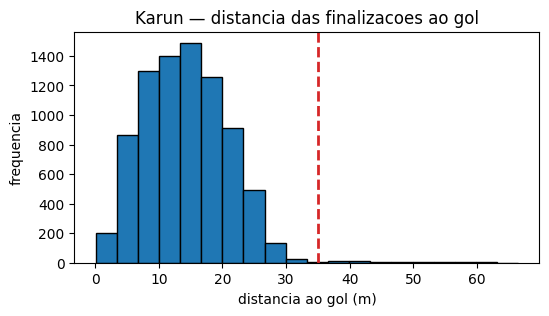

Acoes de treino usadas no Karun depois do filtro: 609,050


In [14]:

KARUN_GOAL_OUTLIER_DISTANCE = 35.0



def add_shot_distance_to_goal(actions, goal_x=PITCH_LENGTH, goal_y=PITCH_WIDTH / 2.0):
    df = actions.copy()
    df['distance_to_goal'] = np.sqrt((goal_x - df['x']) ** 2 + (goal_y - df['y']) ** 2)
    return df


xt_train = add_shot_distance_to_goal(
    actions_df.loc[actions_df['match_id'].isin(train_match_ids)].copy()
)
xt_test = add_shot_distance_to_goal(
    actions_df.loc[actions_df['match_id'].isin(test_match_ids)].copy()
)

long_goal_mask = (
    (xt_train['action_type'] == 'shot')
    & (xt_train['goal'] == 1)
    & (xt_train['distance_to_goal'] > KARUN_GOAL_OUTLIER_DISTANCE)
)

print(f'Limite de distancia para marcar gol como outlier: {KARUN_GOAL_OUTLIER_DISTANCE:.1f} m')
print(f'Gols de treino marcados como outlier: {int(long_goal_mask.sum())}')

display(
    xt_train.loc[
        long_goal_mask,
        ['match_id', 'game_event_id', 'x', 'y', 'distance_to_goal', 'raw_outcome']
    ].sort_values('distance_to_goal', ascending=False)
)

plt.figure(figsize=(6, 3))
plt.hist(
    xt_train.loc[xt_train['action_type'] == 'shot', 'distance_to_goal'].dropna(),
    bins=20,
    color='tab:blue',
    edgecolor='black',
)
plt.axvline(KARUN_GOAL_OUTLIER_DISTANCE, color='tab:red', linestyle='--', linewidth=2)
plt.title('Karun — distancia das finalizacoes ao gol')
plt.xlabel('distancia ao gol (m)')
plt.ylabel('frequencia')
plt.show()

karun_train_model_df = xt_train.loc[~long_goal_mask].copy()
print(f'Acoes de treino usadas no Karun depois do filtro: {len(karun_train_model_df):,}')


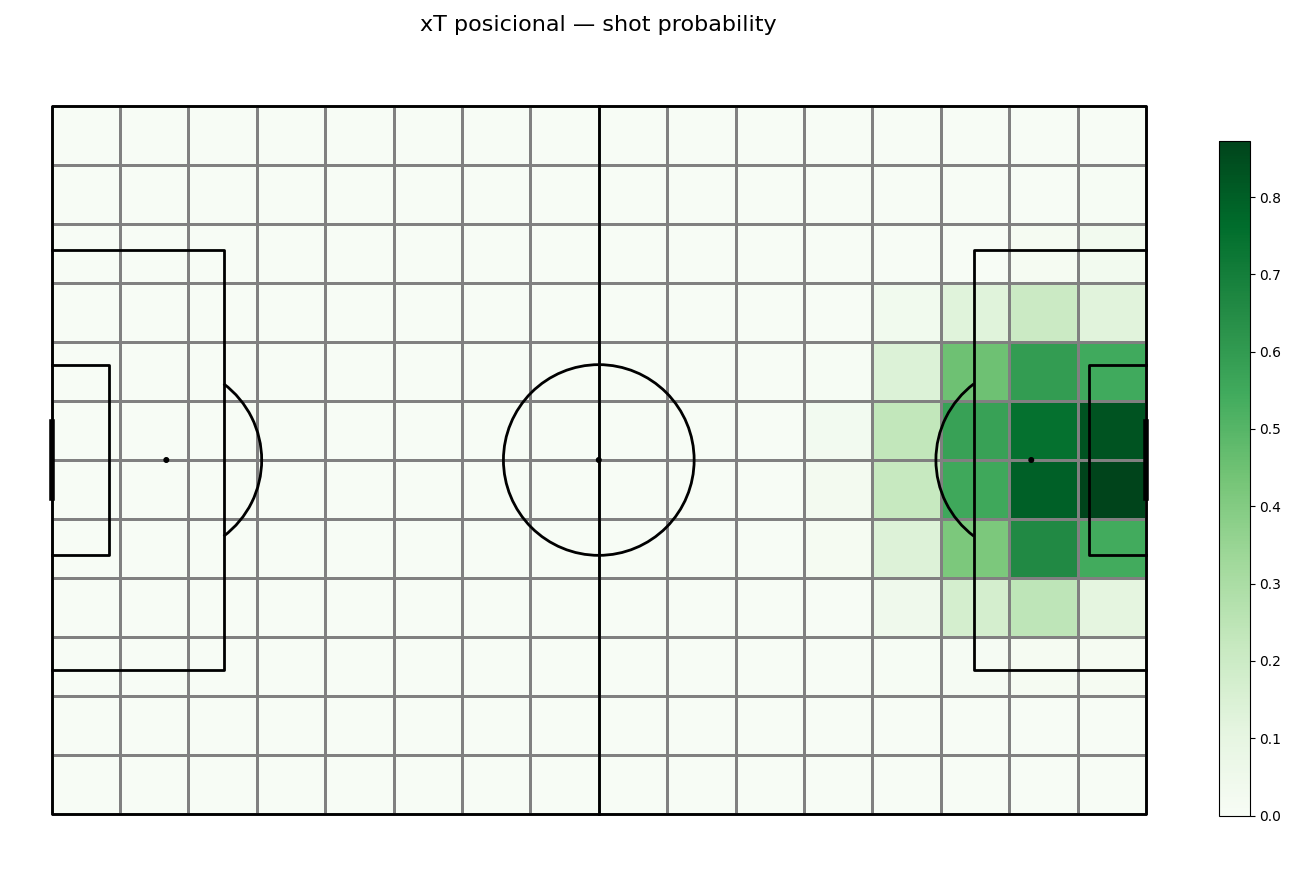

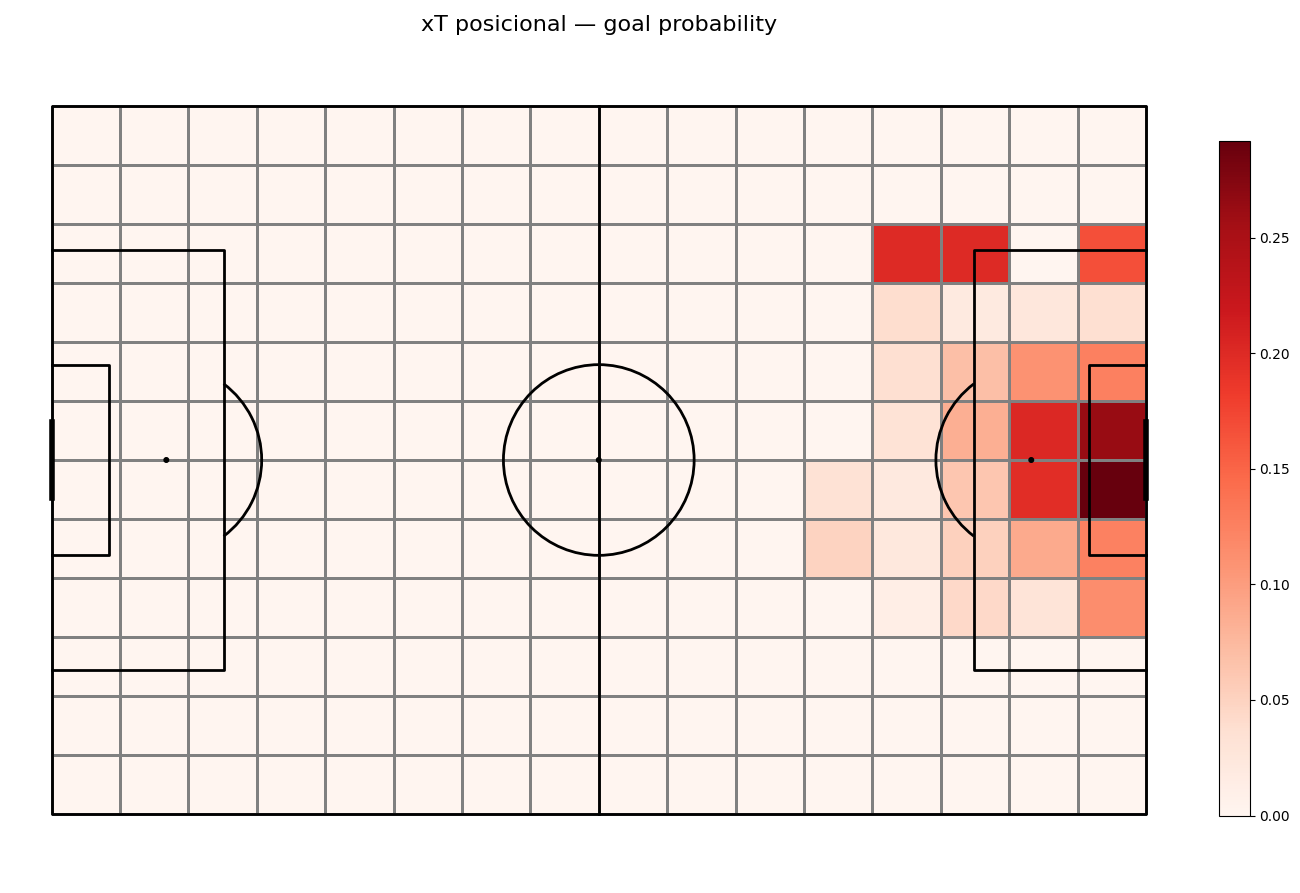

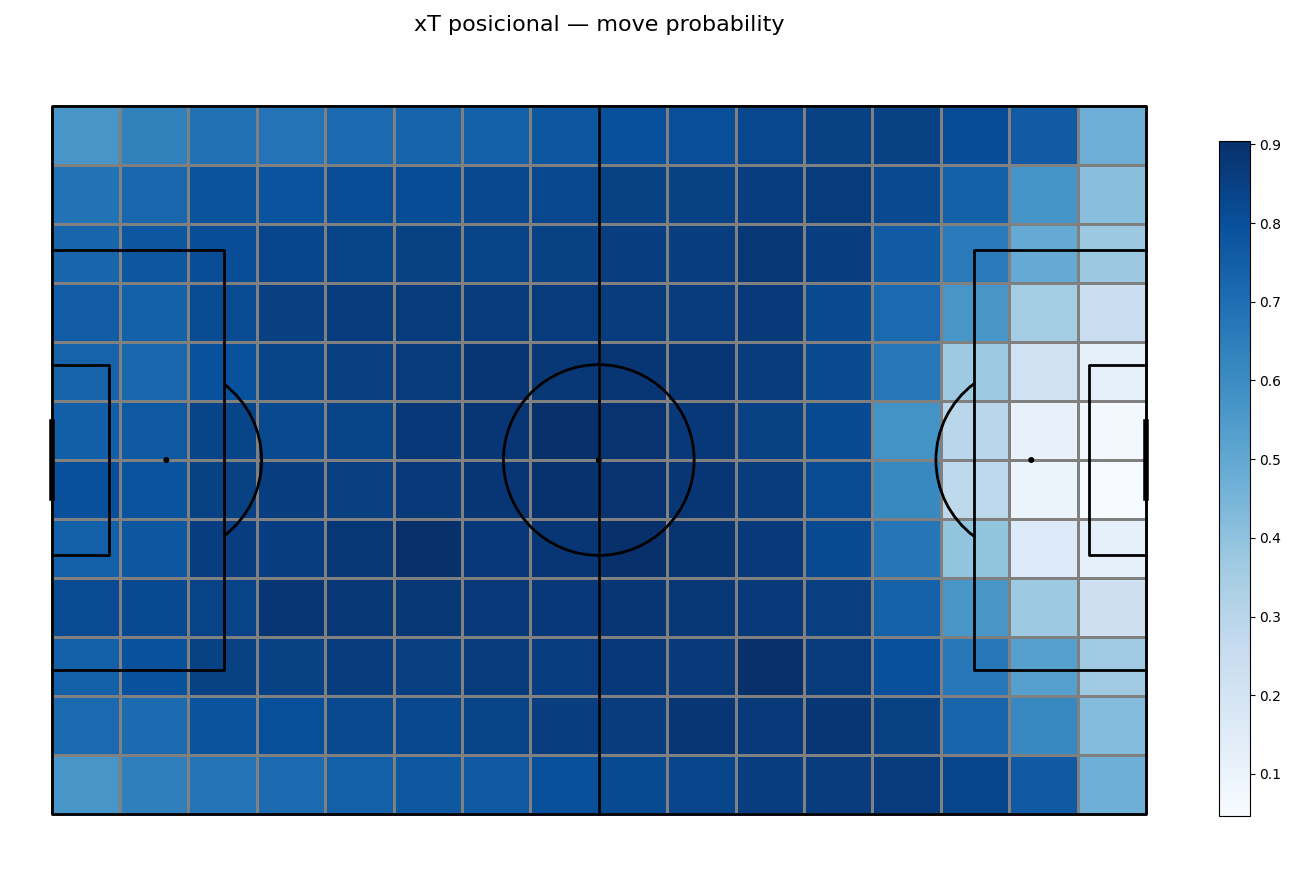

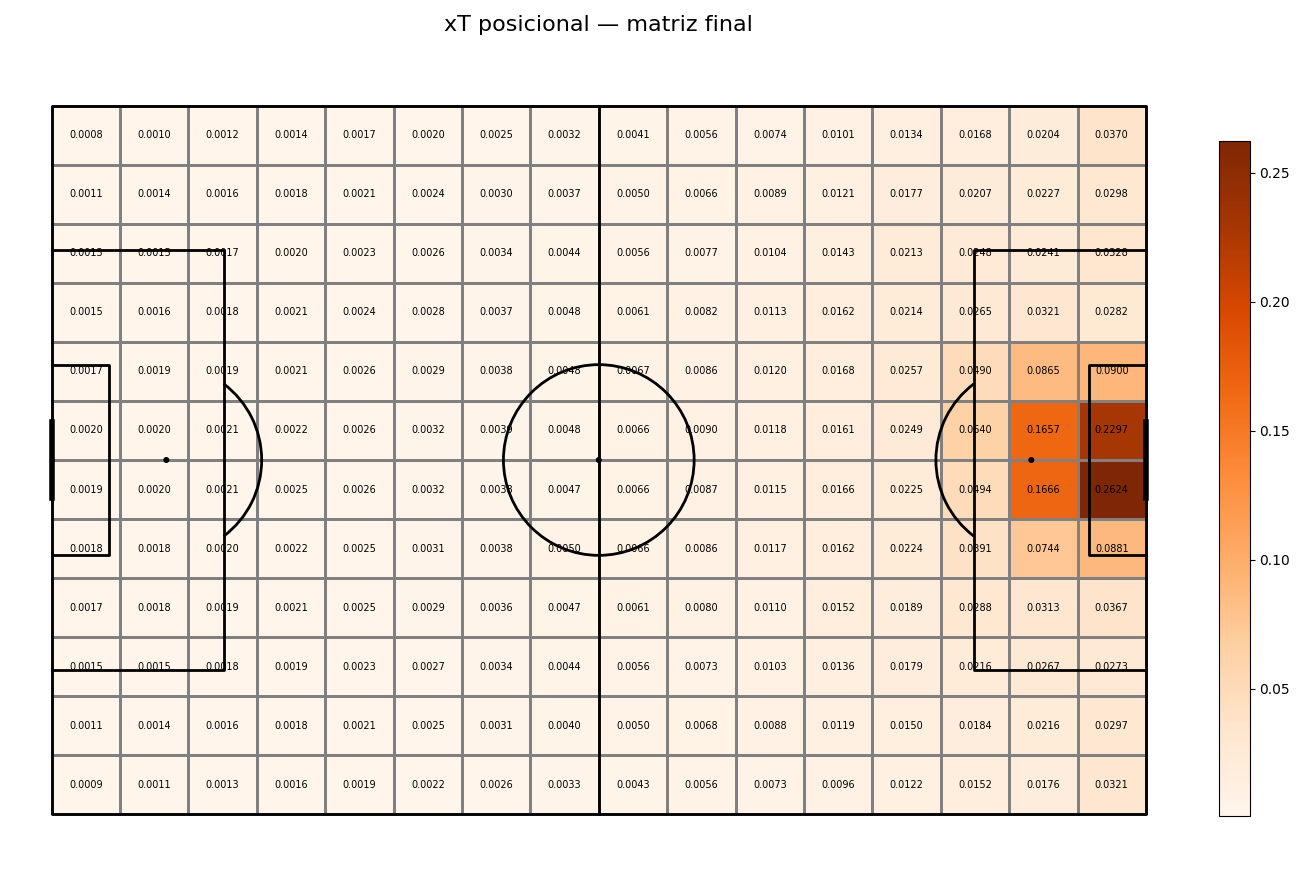

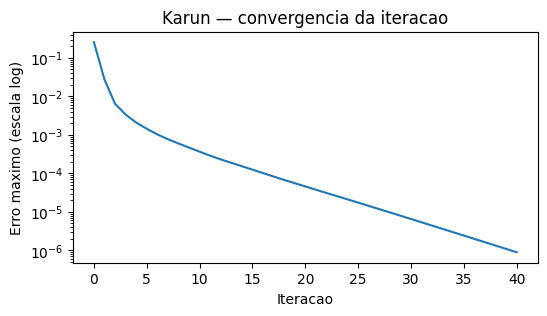

,model,target,n,positive_rate,brier_score,roc_auc
0,karun_xt,sequence_goal,152472,0.0174,0.0169,0.6560


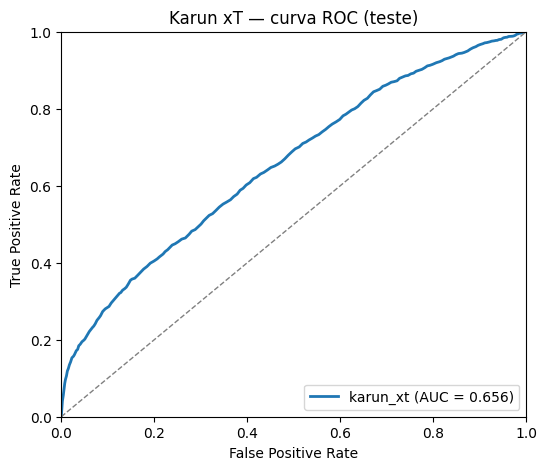

In [15]:

PITCH = Pitch(
    pitch_type='custom',
    pitch_length=PITCH_LENGTH,
    pitch_width=PITCH_WIDTH,
    line_color='black',
    line_zorder=2,
)
PITCH_TEMPLATE = PITCH.bin_statistic(
    np.array([0.5]),
    np.array([0.5]),
    statistic='count',
    bins=XT_BINS,
)



def plot_pitch_matrix(matrix, title, cmap='Oranges', annotate=False, fmt='{0:.2f}'):
    heatmap_data = deepcopy(PITCH_TEMPLATE)
    heatmap_data['statistic'] = matrix

    fig, ax = PITCH.grid(
        grid_height=0.88,
        title_height=0.06,
        axis=False,
        endnote_height=0.03,
        title_space=0,
        endnote_space=0,
    )
    pcm = PITCH.heatmap(heatmap_data, cmap=cmap, edgecolor='grey', ax=ax['pitch'])
    if annotate:
        PITCH.label_heatmap(
            heatmap_data,
            color='black',
            fontsize=7,
            ax=ax['pitch'],
            ha='center',
            va='center',
            str_format=fmt,
            zorder=3,
        )
    ax_cbar = fig.add_axes((1.0, 0.09, 0.025, 0.75))
    plt.colorbar(pcm, cax=ax_cbar)
    fig.suptitle(title, fontsize=16)
    plt.show()



def xy_to_bin_indices(x, y, bins=XT_BINS, pitch_length=PITCH_LENGTH, pitch_width=PITCH_WIDTH):
    if pd.isna(x) or pd.isna(y):
        return np.nan, np.nan
    n_x, n_y = bins
    x = min(max(float(x), 0.0), pitch_length - 1e-9)
    y = min(max(float(y), 0.0), pitch_width - 1e-9)
    bin_x = int(np.floor(x / pitch_length * n_x))
    bin_y = int(np.floor(y / pitch_width * n_y))
    return bin_x, bin_y



def add_xt_bins(actions, bins=XT_BINS):
    df = actions.copy()
    start_bins = df.apply(lambda row: xy_to_bin_indices(row['x'], row['y'], bins=bins), axis=1)
    end_bins = df.apply(lambda row: xy_to_bin_indices(row['x_end'], row['y_end'], bins=bins), axis=1)
    df['start_bin_x'] = [item[0] for item in start_bins]
    df['start_bin_y'] = [item[1] for item in start_bins]
    df['end_bin_x'] = [item[0] for item in end_bins]
    df['end_bin_y'] = [item[1] for item in end_bins]
    return df



def fit_positional_xt(actions, bins=XT_BINS, tol=XT_TOL, max_iters=XT_MAX_ITERS):
    n_x, n_y = bins
    df = add_xt_bins(actions, bins=bins)
    df = df.loc[
        df['action_type'].isin(XT_ACTION_TYPES)
        & df[['start_bin_x', 'start_bin_y']].notna().all(axis=1)
    ].copy()

    total_count = np.zeros((n_y, n_x), dtype=float)
    shot_count = np.zeros((n_y, n_x), dtype=float)
    goal_count = np.zeros((n_y, n_x), dtype=float)
    move_success_count = np.zeros((n_y, n_x), dtype=float)
    transition_count = np.zeros((n_y, n_x, n_y, n_x), dtype=float)

    for row in df.itertuples(index=False):
        sx = int(row.start_bin_x)
        sy = int(row.start_bin_y)
        total_count[sy, sx] += 1.0

        if row.action_type == 'shot':
            shot_count[sy, sx] += 1.0
            goal_count[sy, sx] += float(row.goal)
            continue

        if row.success == 1 and pd.notna(row.end_bin_x) and pd.notna(row.end_bin_y):
            ex = int(row.end_bin_x)
            ey = int(row.end_bin_y)
            move_success_count[sy, sx] += 1.0
            transition_count[sy, sx, ey, ex] += 1.0

    shot_probability = div_no_nan(shot_count, total_count)
    goal_probability = div_no_nan(goal_count, shot_count)
    move_probability = div_no_nan(move_success_count, total_count)

    transition_matrix = np.zeros_like(transition_count)
    for sy in range(n_y):
        for sx in range(n_x):
            if move_success_count[sy, sx] > 0:
                transition_matrix[sy, sx] = transition_count[sy, sx] / move_success_count[sy, sx]

    xT = np.zeros((n_y, n_x), dtype=float)
    convergence = []
    for _ in range(max_iters):
        expected_move_payoff = (transition_matrix * xT[None, None, :, :]).sum(axis=(2, 3))
        xT_new = shot_probability * goal_probability + move_probability * expected_move_payoff
        diff = np.abs(xT_new - xT).max()
        convergence.append(diff)
        xT = xT_new
        if diff < tol:
            break

    return {
        'grid_actions': df,
        'shot_probability': shot_probability,
        'goal_probability': goal_probability,
        'move_probability': move_probability,
        'transition_matrix': transition_matrix,
        'xT': xT,
        'convergence': convergence,
    }



def apply_positional_xt(actions, xt_model, bins=XT_BINS):
    df = add_xt_bins(actions, bins=bins)
    xT = xt_model['xT']

    def _lookup_start(row):
        if pd.isna(row['start_bin_x']) or pd.isna(row['start_bin_y']):
            return np.nan
        return xT[int(row['start_bin_y']), int(row['start_bin_x'])]

    def _lookup_end(row):
        if pd.isna(row['end_bin_x']) or pd.isna(row['end_bin_y']):
            return np.nan
        return xT[int(row['end_bin_y']), int(row['end_bin_x'])]

    df['xt_start'] = df.apply(_lookup_start, axis=1)
    df['xt_end'] = df.apply(_lookup_end, axis=1)
    move_mask = df['action_type'].isin(['pass', 'cross', 'carry']) & (df['success'] == 1)
    df['xt_added'] = np.where(move_mask, df['xt_end'] - df['xt_start'], np.nan)
    return df


karun_model = fit_positional_xt(karun_train_model_df)
xt_actions_df = apply_positional_xt(actions_df, karun_model)

plot_pitch_matrix(karun_model['shot_probability'], 'xT posicional — shot probability', cmap='Greens')
plot_pitch_matrix(karun_model['goal_probability'], 'xT posicional — goal probability', cmap='Reds')
plot_pitch_matrix(karun_model['move_probability'], 'xT posicional — move probability', cmap='Blues')
plot_pitch_matrix(karun_model['xT'], 'xT posicional — matriz final', cmap='Oranges', annotate=True, fmt='{0:.4f}')

plt.figure(figsize=(6, 3))
plt.plot(karun_model['convergence'])
plt.yscale('log')
plt.title('Karun — convergencia da iteracao')
plt.xlabel('Iteracao')
plt.ylabel('Erro maximo (escala log)')
plt.show()

karun_test_eval = xt_actions_df.loc[
    xt_actions_df['match_id'].isin(test_match_ids)
    & xt_actions_df['sequence_goal'].notna()
    & xt_actions_df['xt_start'].notna()
].copy()

karun_metrics, karun_curve = evaluate_binary_predictions(
    karun_test_eval['sequence_goal'],
    karun_test_eval['xt_start'],
    model_name='karun_xt',
    target_name='sequence_goal',
)
karun_metrics_df = pd.DataFrame([karun_metrics])
display(karun_metrics_df)
plot_roc_curves(
    [{'label': 'karun_xt', 'curve': karun_curve, 'auc': karun_metrics['roc_auc']}],
    'Karun xT — curva ROC (teste)',
)


In [16]:

value_adding_actions = xt_actions_df.loc[
    xt_actions_df['action_type'].isin(['pass', 'cross', 'carry'])
    & (xt_actions_df['success'] == 1)
    & xt_actions_df['xt_added'].notna()
].copy()

player_ranking = (
    value_adding_actions.groupby('player_id')['xt_added']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
    .head(15)
)
team_ranking = (
    value_adding_actions.groupby(['team_id', 'team_side'])['xt_added']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
    .head(10)
)

display(player_ranking)
display(team_ranking)


def plot_xt_story(value_actions, entity_kind='player', entity_id=None):
    if entity_kind not in {'player', 'team'}:
        raise ValueError("entity_kind deve ser 'player' ou 'team'.")
    if entity_id is None:
        raise ValueError('Defina entity_id para o exercicio.')

    key = 'player_id' if entity_kind == 'player' else 'team_id'
    subset = value_actions.loc[value_actions[key] == entity_id].copy()
    if subset.empty:
        raise ValueError('Nao encontrei acoes para esse identificador.')

    summary = (
        subset.groupby('action_type')['xt_added']
        .agg(['sum', 'mean', 'count'])
        .sort_values('sum', ascending=False)
    )
    display(summary)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    pitch = Pitch(
        pitch_type='custom',
        pitch_length=PITCH_LENGTH,
        pitch_width=PITCH_WIDTH,
        line_color='black',
    )

    pitch.draw(ax=axes[0])
    pitch.scatter(subset['x'], subset['y'], s=20, alpha=0.6, ax=axes[0])
    axes[0].set_title(f'Origens das acoes ({entity_kind}={entity_id})')

    pitch.draw(ax=axes[1])
    pitch.scatter(subset['x_end'], subset['y_end'], s=20, alpha=0.6, ax=axes[1])
    axes[1].set_title('Destinos das acoes de valor')

    summary['sum'].plot(kind='bar', ax=axes[2], color='tab:orange')
    axes[2].set_title('xT_added por tipo de acao')
    axes[2].set_ylabel('xT_added total')
    plt.tight_layout()
    plt.show()


ENTITY_KIND = 'player'  # troque para 'team' se quiser
ENTITY_ID = None        # ex.: 4793 ou 166

# Exemplo de uso:
# plot_xt_story(value_adding_actions, entity_kind=ENTITY_KIND, entity_id=ENTITY_ID)


,sum,mean,count
player_id,,,
133.0000,8.9171,0.0050,1781
"8,074.0000",8.6059,0.0060,1430
"12,779.0000",8.6028,0.0072,1201
"5,074.0000",7.4396,0.0074,1002
42.0000,7.0186,0.0047,1497
22.0000,6.7912,0.0072,940
"3,112.0000",6.4647,0.0106,608
596.0000,6.4590,0.0049,1327
"2,003.0000",6.4355,0.0064,1002


,,sum,mean,count
team_id,team_side,,,
10.0000,away,22.0155,0.0024,9172
119.0000,home,21.4391,0.0028,7577
13.0000,home,21.2766,0.0027,7853
2.0000,home,21.0626,0.0023,9275
4.0000,home,20.8635,0.0024,8537
1.0000,home,20.2608,0.0030,6804
3.0000,home,20.1494,0.0023,8676
10.0000,home,19.1148,0.0020,9795
54.0000,away,18.5500,0.0022,8492


In [17]:
# read players.json
import json
players_path = EVENTS_DIR / 'players.json'
with open(players_path, 'r') as f:
    players_data = json.load(f)

# to pandas
players_df = pd.DataFrame(players_data)
players_df['player_id'] = players_df['id'].astype(float)

player_ranking = (
    value_adding_actions.groupby('player_id')['xt_added']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
    .head(15)
).merge(players_df[['player_id', 'nickname']].drop_duplicates(), on='player_id', how='left')
player_ranking

,player_id,sum,mean,count,nickname
0,133.0000,8.9171,0.0050,1781,Bruno Fernandes
1,"8,074.0000",8.6059,0.0060,1430,Pedro Porro
2,"12,779.0000",8.6028,0.0072,1201,Mikkel Damsgaard
3,"5,074.0000",7.4396,0.0074,1002,Bryan Mbeumo
4,42.0000,7.0186,0.0047,1497,Trent Alexander-Arnold
5,22.0000,6.7912,0.0072,940,Kevin De Bruyne
6,"3,112.0000",6.4647,0.0106,608,Anthony Elanga
7,596.0000,6.4590,0.0049,1327,Cole Palmer
8,"2,003.0000",6.4355,0.0064,1002,Leif Davis
9,"4,850.0000",6.3487,0.0070,910,Matheus Cunha


,match_id,period,start_time,game_event_id,team_id,player_id,action_type,x,y,x_end,y_end,success,goal,end_was_copied_from_start,score_next_10_actions,concede_next_10_actions
0,31995,1,73.5740,24426842,54.0000,134.0000,pass,50.8400,33.8900,43.1510,33.9450,1.0000,0,0,0,0
1,31995,1,74.3410,24426890,54.0000,"12,664.0000",interception,44.5400,33.5300,44.5400,33.5300,NaN,0,1,0,0
2,31995,1,74.3410,24426890,54.0000,"12,664.0000",pass,42.4200,31.3200,27.5670,27.5560,1.0000,0,0,0,0
3,31995,1,76.9440,24426892,54.0000,257.0000,interception,28.0500,27.1700,28.0500,27.1700,NaN,0,1,0,0
4,31995,1,76.9440,24426892,54.0000,257.0000,pass,31.3400,11.5800,62.3120,1.6840,1.0000,0,0,0,0
5,31995,1,82.4490,24426893,54.0000,250.0000,touch_control,64.4500,6.3100,64.4500,6.3100,NaN,0,1,0,0
6,31995,1,84.0840,24426895,12.0000,250.0000,challenge,43.5400,57.5900,43.5400,57.5900,NaN,0,1,0,0
7,31995,1,84.0840,24426895,12.0000,"13,699.0000",pass,39.2200,66.7700,46.2200,67.0660,1.0000,0,0,0,0
8,31995,1,87.0540,24426897,12.0000,136.0000,interception,46.0000,66.8300,46.0000,66.8300,NaN,0,1,0,0
9,31995,1,87.0540,24426897,12.0000,136.0000,pass,48.1600,66.2000,52.4300,63.1670,0.0000,0,0,0,0


,action_type,n
0,pass,356552
1,interception,257558
2,challenge,66681
3,clearance,16802
4,carry,15673
5,rebound,15584
6,cross,15451
7,shot,10142
8,touch_control,7627
9,foul,255


Linhas com destino copiado do inicio: 49.28%


,model,target,n,positive_rate,brier_score,roc_auc
0,baseline_concede_next_10_actions,concede_next_10_actions,153270,0.0034,0.1930,0.7384
1,baseline_score_next_10_actions,score_next_10_actions,153270,0.0127,0.1959,0.7656


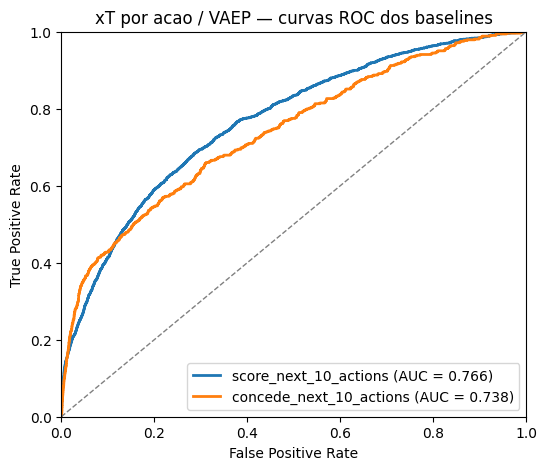

In [18]:

def build_action_features_and_targets(actions, horizon=10):
    df = actions.copy()
    keep_cols = [
        'match_id',
        'period',
        'start_time',
        'game_event_id',
        'team_id',
        'player_id',
        'action_type',
        'x',
        'y',
        'x_end',
        'y_end',
        'success',
        'goal',
    ]
    df = df[keep_cols].sort_values(['match_id', 'period', 'start_time', 'game_event_id']).reset_index(drop=True)

    missing_end_mask = df['x_end'].isna() | df['y_end'].isna()
    df.loc[df['x_end'].isna(), 'x_end'] = df.loc[df['x_end'].isna(), 'x']
    df.loc[df['y_end'].isna(), 'y_end'] = df.loc[df['y_end'].isna(), 'y']
    df['end_was_copied_from_start'] = missing_end_mask.astype(int)

    df['score_next_10_actions'] = 0
    df['concede_next_10_actions'] = 0

    for match_id, idx in df.groupby('match_id').groups.items():
        local = df.loc[idx].reset_index()
        teams = local['team_id'].to_numpy()
        goals = local['goal'].fillna(0).astype(int).to_numpy()
        score_target = np.zeros(len(local), dtype=int)
        concede_target = np.zeros(len(local), dtype=int)

        for i in range(len(local)):
            j = min(len(local), i + horizon)
            future_goals = goals[i:j].astype(bool)
            future_teams = teams[i:j]
            if future_goals.any():
                scoring_teams = future_teams[future_goals]
                score_target[i] = int(np.any(scoring_teams == teams[i]))
                concede_target[i] = int(np.any(scoring_teams != teams[i]))

        df.loc[local['index'], 'score_next_10_actions'] = score_target
        df.loc[local['index'], 'concede_next_10_actions'] = concede_target

    return df



def fit_action_baseline(train_df, test_df, target_col):
    feature_cols = ['x', 'y', 'x_end', 'y_end', 'action_type']
    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].astype(int).copy()
    X_test = test_df[feature_cols].copy()
    y_test = test_df[target_col].astype(int).copy()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                'num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                ]),
                ['x', 'y', 'x_end', 'y_end'],
            ),
            (
                'cat',
                OneHotEncoder(handle_unknown='ignore'),
                ['action_type'],
            ),
        ]
    )

    if y_train.nunique() < 2:
        model = Pipeline(
            steps=[
                ('prep', preprocessor),
                ('clf', DummyClassifier(strategy='prior')),
            ]
        )
    else:
        model = Pipeline(
            steps=[
                ('prep', preprocessor),
                ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
            ]
        )

    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)
    if proba.shape[1] == 1:
        positive_class = int(model.named_steps['clf'].classes_[0])
        y_prob = np.full(len(X_test), float(positive_class))
    else:
        class_to_idx = {int(cls): idx for idx, cls in enumerate(model.named_steps['clf'].classes_)}
        y_prob = proba[:, class_to_idx[1]]

    metrics, curve = evaluate_binary_predictions(
        y_test,
        y_prob,
        model_name=f'baseline_{target_col}',
        target_name=target_col,
    )
    return model, y_prob, metrics, curve


action_features_df = build_action_features_and_targets(actions_df, horizon=HORIZON_ACTIONS)
display(action_features_df.head(10))

display(
    action_features_df['action_type']
    .value_counts(dropna=False)
    .rename_axis('action_type')
    .reset_index(name='n')
)
print(f'Linhas com destino copiado do inicio: {action_features_df["end_was_copied_from_start"].mean():.2%}')

vaep_train = action_features_df.loc[action_features_df['match_id'].isin(train_match_ids)].copy()
vaep_test = action_features_df.loc[action_features_df['match_id'].isin(test_match_ids)].copy()

score_model, score_prob, score_metrics, score_curve = fit_action_baseline(
    vaep_train,
    vaep_test,
    target_col='score_next_10_actions',
)
concede_model, concede_prob, concede_metrics, concede_curve = fit_action_baseline(
    vaep_train,
    vaep_test,
    target_col='concede_next_10_actions',
)

vaep_metrics_df = pd.DataFrame([score_metrics, concede_metrics]).sort_values(['target', 'brier_score']).reset_index(drop=True)
display(vaep_metrics_df)

plot_roc_curves(
    [
        {'label': 'score_next_10_actions', 'curve': score_curve, 'auc': score_metrics['roc_auc']},
        {'label': 'concede_next_10_actions', 'curve': concede_curve, 'auc': concede_metrics['roc_auc']},
    ],
    'xT por acao / VAEP — curvas ROC dos baselines',
)


In [19]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import ast

def prepare_shots_data_from_csv(df):
    # 1. Filtra chutes
    shots = df[df['possession_events_possession_event_type'] == 'SH'].copy()
    
    # 2. Nova extração lendo a chave do dicionário ('x' e 'y')
    def parse_coordinate(val, key):
        try:
            if pd.isna(val):
                return np.nan
            if isinstance(val, str):
                val = ast.literal_eval(val) # Transforma string em lista de dicionário
            
            # Pega o primeiro item da lista e acessa a chave pedida ('x' ou 'y')
            if isinstance(val, list) and len(val) > 0:
                return float(val[0][key])
            elif isinstance(val, dict):
                return float(val[key])
            return np.nan
        except:
            return np.nan

    shots['X'] = shots['ball'].apply(lambda b: parse_coordinate(b, 'x'))
    shots['Y'] = shots['ball'].apply(lambda b: parse_coordinate(b, 'y'))
    
    # Remove chutes sem coordenadas
    shots = shots.dropna(subset=['X', 'Y']).copy()
    
    # 3. Geometria do Chute (Campo zero-centered)
    # Assumindo comprimento 105m (gols em X = 52.5 e X = -52.5) e largura 68m (centro Y = 0)
    # abs(X) faz com que a gente sempre calcule a distância para o gol do ataque
    shots['X_dist'] = 52.5 - abs(shots['X'])  
    shots['C'] = abs(shots['Y']) # Como o centro é 0, a distância ao centro é o próprio módulo de Y
    
    # Distância Euclidiana
    shots['Distance'] = np.sqrt(shots['X_dist']**2 + shots['C']**2)
    
    # Ângulo (Proteção contra Divisão por Zero)
    denominador = (shots['X_dist']**2 + shots['C']**2 - (7.32 / 2)**2)
    denominador = np.where(denominador == 0, 1e-6, denominador) 
    
    angle = np.arctan(7.32 * shots['X_dist'] / denominador)
    shots['Angle'] = np.where(angle > 0, angle, angle + np.pi)
    
    # 4. Definir a variável Alvo (Gol = 1)
    shots['Goal'] = shots['possession_events_shot_outcome_type'].apply(
        lambda x: 1 if str(x).strip().upper() in ['GOAL', 'G'] else 0
    )
    
    return shots.dropna(subset=['Distance', 'Angle', 'Goal'])

# ==========================================
# EXECUÇÃO E TREINAMENTO FINAL
# ==========================================

print("Preparando dados matemáticos dos chutes...")
shots_data_treino = prepare_shots_data_from_csv(all_value_events_df)

print(f"Total de chutes processados para treino: {len(shots_data_treino)}")
print(f"Total de gols encontrados no dataset: {shots_data_treino['Goal'].sum()}")

if shots_data_treino['Goal'].sum() > 0:
    print("\nTreinando modelo de xG (Regressão Logística)...")
    xg_model = smf.glm(formula="Goal ~ Distance + Angle", 
                       data=shots_data_treino, 
                       family=sm.families.Binomial()).fit()

    print("\n--- Resumo do Modelo xG Treinado ---")
    print(xg_model.summary().tables[1])
else:
    print("[ERRO] Os chutes foram lidos, mas 0 gols foram encontrados. Verifique a grafia de 'GOAL' no dataset.")

Preparando dados matemáticos dos chutes...
Total de chutes processados para treino: 10121
Total de gols encontrados no dataset: 1201

Treinando modelo de xG (Regressão Logística)...

--- Resumo do Modelo xG Treinado ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7690      0.141     -5.446      0.000      -1.046      -0.492
Distance      -0.1225      0.008    -14.737      0.000      -0.139      -0.106
Angle          0.3890      0.081      4.809      0.000       0.230       0.548


In [20]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

def generate_match_xg_report(game_id, events_df, subs_df, model, path_players=None):
    """
    Gera um relatório completo de xG e placar real para uma partida específica,
    detalhando os eventos (gols e substituições) na linha do tempo.
    Adaptado para funcionar com o novo dataframe de substituições limpo.
    """
    # 1. Carregar mapeamento dos jogadores (ID -> Nome)
    player_map = {}
    if path_players and Path(path_players).exists():
        with open(path_players, 'r', encoding='utf-8') as f:
            players_list = json.load(f)
            player_map = {int(p['id']): p.get('nickname') or f"{p['firstName']} {p['lastName']}" for p in players_list}

    def get_player_name(pid_raw):
        try:
            pid = int(float(pid_raw)) if pd.notna(pid_raw) else -1
            return player_map.get(pid, f"ID {pid_raw}")
        except:
            return f"ID {pid_raw}"

    # 2. Filtrar dados do jogo (Tolerante a diferenças de nome das colunas)
    col_events = 'match_id' if 'match_id' in events_df.columns else 'game_id'
    col_subs = 'match_id' if 'match_id' in subs_df.columns else 'game_id'
    
    match_events = events_df[events_df[col_events] == game_id].copy()
    match_subs = subs_df[subs_df[col_subs] == game_id].copy()
    
    if match_events.empty:
        print(f"❌ Nenhum evento encontrado para o ID: {game_id}")
        return
        
    # Limpa duplicatas de substituições buscando pelas colunas novas ou antigas
    if not match_subs.empty:
        c_off = 'player_off_id' if 'player_off_id' in match_subs.columns else 'game_events_player_off_id'
        c_on = 'player_on_id' if 'player_on_id' in match_subs.columns else 'game_events_player_on_id'
        match_subs = match_subs.drop_duplicates(subset=['start_time', c_off, c_on])

    # --- DESCOBRIR QUEM É O MANDANTE ---
    id_mandante = None
    if 'game_events_team_id' in match_events.columns and 'game_events_home_team' in match_events.columns:
        home_events = match_events[match_events['game_events_home_team'] == True]
        if not home_events.empty:
            id_mandante = home_events['game_events_team_id'].iloc[0]

    # 3. Extrair coordenadas e calcular xG de todos os chutes
    match_shots = prepare_shots_data_from_csv(match_events)
    if not match_shots.empty:
        match_shots['xG'] = model.predict(match_shots)
        
        # Mapeia quem é quem nos chutes
        if 'game_events_home_team' in match_shots.columns:
            match_shots['Team_Side'] = match_shots['game_events_home_team'].apply(
                lambda x: 'Mandante' if x == True else 'Visitante'
            )
        else:
            match_shots['Team_Side'] = match_shots['game_events_team_id'].apply(
                lambda tid: 'Mandante' if tid == id_mandante else 'Visitante'
            )
    else:
        match_shots = pd.DataFrame(columns=['start_time', 'Team_Side', 'xG', 'Goal'])

    # 4. Construir Linha do Tempo Unificada (Gols + Substituições)
    milestones = []
    
    # 4.1 Identificar os Gols
    goals_df = match_events[
        (match_events['possession_events_possession_event_type'] == 'SH') &
        (match_events['possession_events_shot_outcome_type'].astype(str).str.strip().str.upper().isin(['GOAL', 'G']))
    ]
    for _, goal in goals_df.iterrows():
        is_home = goal.get('game_events_home_team')
        tid = goal.get('game_events_team_id')
        side = 'Mandante' if is_home == True or tid == id_mandante else 'Visitante'
        
        milestones.append({
            'time': goal['start_time'],
            'type': 'GOAL',
            'team_str': side,
            'player_id': goal['game_events_player_id']
        })
        
    # 4.2 Identificar as Substituições (usando a base limpa)
    for _, sub in match_subs.iterrows():
        tid = sub.get('team_id')
        
        # Define o lado baseado no team_id limpo
        if pd.notna(tid) and id_mandante is not None:
            side = 'Mandante' if tid == id_mandante else 'Visitante'
        else:
            side = 'Mandante' if sub.get('game_events_home_team') == True else 'Visitante'
            
        milestones.append({
            'time': sub['start_time'],
            'type': 'SUB',
            'team_str': side,
            'player_off': sub.get('player_off_id', sub.get('game_events_player_off_id')),
            'player_on': sub.get('player_on_id', sub.get('game_events_player_on_id')),
            'name_off': sub.get('player_off_name'),
            'name_on': sub.get('player_on_name'),
            'sub_type': sub.get('game_events_player_off_type', 'Tática')
        })
        
    # 5. LINHA DO TEMPO CRONOLÓGICA
    t_start = 0
    t_end = match_events['start_time'].max() if not match_events.empty else 5400
    
    unique_times = sorted(list(set(m['time'] for m in milestones)))
    timeline = sorted(list(set([t_start] + unique_times + [t_end])))
    
    accum_home_xg, accum_away_xg = 0.0, 0.0
    score_home, score_away = 0, 0

    print("=" * 70)
    print(f"📊 RELATÓRIO ESTATÍSTICO DE xG E PLACAR - PARTIDA ID: {game_id}")
    print("=" * 70)
    print("\n⏳ ANÁLISE CRONOLÓGICA: DELTAS, GOLS E SUBSTITUIÇÕES")
    print("-" * 70)

    def format_time(seconds):
        if pd.isna(seconds): return "00:00"
        m, s = divmod(int(seconds), 60)
        return f"{m:02d}:{s:02d}"

    for i in range(len(timeline) - 1):
        t_low = timeline[i]
        t_high = timeline[i+1]
        
        if t_high > t_low:
            interval_shots = match_shots[(match_shots['start_time'] >= t_low) & (match_shots['start_time'] < t_high)]
            delta_home_xg = interval_shots[interval_shots['Team_Side'] == 'Mandante']['xG'].sum() if not interval_shots.empty else 0
            delta_away_xg = interval_shots[interval_shots['Team_Side'] == 'Visitante']['xG'].sum() if not interval_shots.empty else 0
            
            accum_home_xg += delta_home_xg
            accum_away_xg += delta_away_xg

            print(f"Intervalo: {format_time(t_low)} até {format_time(t_high)}")
            print(f"  ↳ Delta xG Mandante : +{delta_home_xg:.3f} (Total acumulado: {accum_home_xg:.2f})")
            print(f"  ↳ Delta xG Visitante: +{delta_away_xg:.3f} (Total acumulado: {accum_away_xg:.2f})")
        
        events_now = [m for m in milestones if m['time'] == t_high]
        
        goals_now = [e for e in events_now if e['type'] == 'GOAL']
        for g in goals_now:
            if g['team_str'] == 'Mandante':
                score_home += 1
            else:
                score_away += 1
                
            scorer = get_player_name(g['player_id'])
            
            print(f"\n⚽ [GOL!] aos {format_time(t_high)} - {scorer} ({g['team_str']})")
            print(f"  PLACAR ATUAL: Mandante {score_home} x {score_away} Visitante")
            print("-" * 70)
            
        subs_now = [e for e in events_now if e['type'] == 'SUB']
        if subs_now:
            print(f"\n🔄 [SUBSTITUIÇÃO] aos {format_time(t_high)}")
            print(f"  Placar Real Atual: Mandante {score_home} x {score_away} Visitante")
            print(f"  Placar xG Atual  : Mandante {accum_home_xg:.2f} x {accum_away_xg:.2f} Visitante")
            
            for sub in subs_now:
                # Usa os nomes limpos direto do DataFrame se existirem
                p_out = sub['name_off'] if pd.notna(sub.get('name_off')) else get_player_name(sub['player_off'])
                p_in = sub['name_on'] if pd.notna(sub.get('name_on')) else get_player_name(sub['player_on'])
                p_type = sub['sub_type'] if pd.notna(sub.get('sub_type')) else 'Tática'
                
                print(f"  • Equipe: {sub['team_str']}")
                print(f"    🔻 Saiu: {p_out} ({p_type})")
                print(f"    🔺 Entrou: {p_in}")
            print("-" * 70)
            
    print("🏁 Fim da partida.")
    print("=" * 70)
    print("RESUMO FINAL DA PARTIDA:")
    print(f"Placar Real: Mandante {score_home} x {score_away} Visitante")
    print(f"Placar xG  : Mandante {accum_home_xg:.2f} x {accum_away_xg:.2f} Visitante")
    print("=" * 70)

In [21]:
# ==============================================================================
# EXEMPLO DE EXECUÇÃO DO RELATÓRIO
# ==============================================================================
# Caminho do arquivo de jogadores no seu Drive Desktop local
CAMINHO_PLAYERS = Path('dados/') / 'players.json'

# Escolha qualquer ID de jogo presente no seu dataset para testar o relatório
id_jogo_teste = 31997

# Chamar a função para imprimir a análise na tela
generate_match_xg_report(
    game_id=id_jogo_teste,
    events_df=all_value_events_df,
    subs_df=substitutions_df,
    model=xg_model,
    path_players=CAMINHO_PLAYERS
)

📊 RELATÓRIO ESTATÍSTICO DE xG E PLACAR - PARTIDA ID: 31997

⏳ ANÁLISE CRONOLÓGICA: DELTAS, GOLS E SUBSTITUIÇÕES
----------------------------------------------------------------------
Intervalo: 00:00 até 25:11
  ↳ Delta xG Mandante : +0.397 (Total acumulado: 0.40)
  ↳ Delta xG Visitante: +0.097 (Total acumulado: 0.10)

⚽ [GOL!] aos 25:11 - Kai Havertz (Mandante)
  PLACAR ATUAL: Mandante 1 x 0 Visitante
----------------------------------------------------------------------
Intervalo: 25:11 até 59:08
  ↳ Delta xG Mandante : +1.139 (Total acumulado: 1.54)
  ↳ Delta xG Visitante: +0.203 (Total acumulado: 0.30)

🔄 [SUBSTITUIÇÃO] aos 59:08
  Placar Real Atual: Mandante 1 x 0 Visitante
  Placar xG Atual  : Mandante 1.54 x 0.30 Visitante
  • Equipe: Visitante
    🔻 Saiu: Jean-Ricner Bellegarde (Tática)
    🔺 Entrou: Matheus Cunha
----------------------------------------------------------------------
Intervalo: 59:08 até 71:01
  ↳ Delta xG Mandante : +0.222 (Total acumulado: 1.76)
  ↳ Delta xG 

In [22]:
#TREINAMENTO xT
import json

def build_and_apply_xt(actions_df, train_match_ids):
    """
    Treina o modelo de xT Posicional usando os jogos de treino e
    aplica a métrica (xt_added) a todas as ações da temporada.
    """
    print("Treinando modelo xT Posicional (Grade 16x12)...")
    # Filtra apenas os jogos de treino usando a lista de IDs
    df_train = actions_df[actions_df['match_id'].isin(train_match_ids)].copy()
    
    # Chama a função do notebook original para ajustar o modelo
    xt_model = fit_positional_xt(df_train)
    
    print("Aplicando xT calculado em todas as ações...")
    # Aplica o modelo criado ao dataset geral
    actions_xt_df = apply_positional_xt(actions_df, xt_model)
    
    # Preenche NaNs com 0 para facilitar as somas no relatório
    actions_xt_df['xt_added'] = actions_xt_df['xt_added'].fillna(0.0)
    
    return xt_model, actions_xt_df

In [23]:
def build_and_apply_vaep(actions_df, train_match_ids):
    """
    Cria as features de histórico, treina os baselines de probabilidade 
    e calcula o Valor Ofensivo, Defensivo e o VAEP Total de cada ação.
    """
    print("Extraindo histórico (features) de ações para o VAEP...")
    features_df = build_action_features_and_targets(actions_df, horizon=HORIZON_ACTIONS)
    
    df_train = features_df[features_df['match_id'].isin(train_match_ids)].copy()
    
    print("Ajustando modelos de Score e Concede...")
    # Usamos o fit_action_baseline aplicando a previsão no features_df completo
    score_model, score_prob, _, _ = fit_action_baseline(df_train, features_df, target_col='score_next_10_actions')
    concede_model, concede_prob, _, _ = fit_action_baseline(df_train, features_df, target_col='concede_next_10_actions')
    
    features_df['score_prob'] = score_prob
    features_df['concede_prob'] = concede_prob
    
    print("Calculando Valor Ofensivo e Defensivo...")
    # Ordena cronologicamente para garantir que a ação anterior é do mesmo time na sequência
    features_df = features_df.sort_values(['match_id', 'period', 'start_time', 'game_event_id'])
    
    # Desloca a probabilidade em 1 espaço para obter o 'P(score | antes da ação)'
    features_df['prev_score_prob'] = features_df.groupby(['match_id', 'team_id'])['score_prob'].shift(1).fillna(0.0)
    features_df['prev_concede_prob'] = features_df.groupby(['match_id', 'team_id'])['concede_prob'].shift(1).fillna(0.0)
    
    # Aplicação das fórmulas didáticas
    features_df['offensive_value'] = features_df['score_prob'] - features_df['prev_score_prob']
    features_df['defensive_value'] = features_df['prev_concede_prob'] - features_df['concede_prob']
    features_df['vaep_value'] = features_df['offensive_value'] + features_df['defensive_value']
    
    # Remove valores nulos caso ocorram no início da posse
    features_df['vaep_value'] = features_df['vaep_value'].fillna(0.0)
    
    return {'score': score_model, 'concede': concede_model}, features_df

In [24]:
def generate_xt_vaep_report(game_id, combined_actions_df, subs_df, path_players=None):
    # 1. Carregar jogadores
    player_map = {}
    if path_players and Path(path_players).exists():
        with open(path_players, 'r', encoding='utf-8') as f:
            players_list = json.load(f)
            player_map = {int(p['id']): p.get('nickname') or f"{p['firstName']} {p['lastName']}" for p in players_list}

    # 2. Filtrar Jogo
    df_actions = combined_actions_df[combined_actions_df['match_id'] == game_id].copy().reset_index(drop=True)
    df_subs = subs_df[subs_df['match_id'] == game_id].copy().reset_index(drop=True)

    if df_actions.empty:
        print(f"❌ Nenhuma ação encontrada para a partida ID: {game_id}")
        return

    # --- IDENTIFICAÇÃO DE TIME BLINDADA ---
    # Se não temos 'game_events_home_team', assumimos que o primeiro ID que aparece 
    # nas ações do mandante é o dono da casa, ou usamos uma lógica de contagem.
    # Vamos assumir que o time que tem mais ações no jogo é o mandante (ou você pode ajustar manualmente)
    contagem_times = df_actions['team_id'].value_counts()
    id_mandante = contagem_times.index[0] # Time com mais ações é o "dono da casa" provável
    
    def rotular_time(tid):
        return 'Mandante' if tid == id_mandante else 'Visitante'

    df_actions['Team_Side_Str'] = df_actions['team_id'].apply(rotular_time)
    df_subs['Team_Side_Str'] = df_subs['team_id'].apply(rotular_time)

    # Totais
    total_home_xt = df_actions[df_actions['Team_Side_Str'] == 'Mandante']['xt_added'].sum()
    total_away_xt = df_actions[df_actions['Team_Side_Str'] == 'Visitante']['xt_added'].sum()
    total_home_vaep = df_actions[df_actions['Team_Side_Str'] == 'Mandante']['vaep_value'].sum()
    total_away_vaep = df_actions[df_actions['Team_Side_Str'] == 'Visitante']['vaep_value'].sum()

    print("=" * 80)
    print(f"📊 RELATÓRIO DE AMEAÇA (xT) E VALOR (VAEP) - PARTIDA ID: {game_id}")
    print(f"🏠 Mandante (Time ID {id_mandante}) | 🚀 Visitante")
    print("=" * 80)
    print(f"🏠 Mandante  -> Total xT: {total_home_xt:.3f} | Total VAEP: {total_home_vaep:.3f}")
    print(f"🚀 Visitante -> Total xT: {total_away_xt:.3f} | Total VAEP: {total_away_vaep:.3f}")
    print("=" * 80)

    # 3. Unificar Linha do Tempo
    milestones = []
    
    # Gols
    for _, goal in df_actions[df_actions['goal'] == 1].iterrows():
        milestones.append({'time': goal['start_time'], 'type': 'GOAL', 'team_str': goal['Team_Side_Str'], 'player_id': goal['player_id']})

    # Subs
    for _, sub in df_subs.iterrows():
        milestones.append({
            'time': sub['start_time'], 'type': 'SUB',
            'team_str': sub['Team_Side_Str'],
            'name_off': sub['player_off_name'],
            'name_on': sub['player_on_name']
        })

    timeline = sorted(list(set([0] + [m['time'] for m in milestones] + [df_actions['start_time'].max()])))

    # 4. Loop de Análise
    print("\n⏳ ANÁLISE CRONOLÓGICA")
    accum_home_xt, accum_away_xt = 0.0, 0.0
    accum_home_vaep, accum_away_vaep = 0.0, 0.0
    
    for i in range(len(timeline) - 1):
        t_low, t_high = timeline[i], timeline[i+1]
        if t_high <= t_low: continue
            
        interval = df_actions[(df_actions['start_time'] >= t_low) & (df_actions['start_time'] < t_high)]
        accum_home_xt += interval[interval['Team_Side_Str'] == 'Mandante']['xt_added'].sum()
        accum_away_xt += interval[interval['Team_Side_Str'] == 'Visitante']['xt_added'].sum()
        accum_home_vaep += interval[interval['Team_Side_Str'] == 'Mandante']['vaep_value'].sum()
        accum_away_vaep += interval[interval['Team_Side_Str'] == 'Visitante']['vaep_value'].sum()

        for m in [x for x in milestones if x['time'] == t_high]:
            if m['type'] == 'SUB':
                print(f"\n🔄 [{m['team_str']}] aos {(t_high/60):.1f}' - Entrou: {m['name_on']} | Saiu: {m['name_off']}")
                print(f"   xT Acum: {accum_home_xt:.2f}x{accum_away_xt:.2f} | VAEP Acum: {accum_home_vaep:.2f}x{accum_away_vaep:.2f}")

    print("\n🏁 Fim da partida.")

In [25]:
# 1. Obter DataFrame enriquecido com xT e VAEP
# Nota: use 'actions_df' (já criada no seu notebook original) e o 'train_match_ids'

_, actions_xt_df = build_and_apply_xt(actions_df, train_match_ids)
_, actions_vaep_df = build_and_apply_vaep(actions_df, train_match_ids)

# 2. Fundimos as métricas geradas num único DataFrame Final
actions_final_df = actions_vaep_df.copy()
actions_final_df['xt_added'] = actions_xt_df['xt_added']


Treinando modelo xT Posicional (Grade 16x12)...
Aplicando xT calculado em todas as ações...
Extraindo histórico (features) de ações para o VAEP...
Ajustando modelos de Score e Concede...
Calculando Valor Ofensivo e Defensivo...


In [26]:
# ==========================================
# EXEMPLO DE EXECUÇÃO:
# ==========================================
# 3. Geramos o relatório do seu jogo de teste
id_jogo_teste = 31998 # Exemplo que estava usando
CAMINHO_PLAYERS = Path('dados/') / 'players.json'
generate_xt_vaep_report(
     game_id=id_jogo_teste,
     combined_actions_df=actions_final_df,
     subs_df=substitutions_df,
     path_players=CAMINHO_PLAYERS
)

📊 RELATÓRIO DE AMEAÇA (xT) E VALOR (VAEP) - PARTIDA ID: 31998
🏠 Mandante (Time ID 4.0) | 🚀 Visitante
🏠 Mandante  -> Total xT: 0.848 | Total VAEP: -0.381
🚀 Visitante -> Total xT: 1.045 | Total VAEP: -4.986

⏳ ANÁLISE CRONOLÓGICA

🔄 [Mandante] aos 48.6' - Entrou: Simon Adingra | Saiu: Yankuba Minteh
   xT Acum: 0.42x0.71 | VAEP Acum: -0.51x-1.62

🔄 [Visitante] aos 69.3' - Entrou: Iliman Ndiaye | Saiu: Abdoulaye Doucouré
   xT Acum: 0.43x1.01 | VAEP Acum: -0.46x-1.35

🔄 [Mandante] aos 82.3' - Entrou: Adam Webster | Saiu: Lewis Dunk
   xT Acum: 0.50x1.02 | VAEP Acum: -0.30x-3.50

🔄 [Visitante] aos 82.8' - Entrou: Beto | Saiu: Dominic Calvert-Lewin
   xT Acum: 0.50x1.02 | VAEP Acum: -0.30x-3.50

🔄 [Mandante] aos 89.0' - Entrou: Billy Gilmour | Saiu: James Milner
   xT Acum: 0.67x1.03 | VAEP Acum: 0.31x-4.74

🔄 [Mandante] aos 89.0' - Entrou: Jeremy Sarmiento | Saiu: João Pedro
   xT Acum: 0.67x1.03 | VAEP Acum: 0.31x-4.74

🔄 [Visitante] aos 91.5' - Entrou: Mason Holgate | Saiu: Jack Harrison

In [27]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

def generate_match_stats_tables(game_id, combined_actions_df, match_shots_df, path_players=None):
    """
    Gera tabelas de atributos de xG, xT e VAEP agregadas por Time, Jogador 
    e uma linha do tempo acumulada (minuto a minuto).
    """
    # 1. Carregar mapeamento dos jogadores (ID -> Nome)
    player_map = {}
    if path_players and Path(path_players).exists():
        with open(path_players, 'r', encoding='utf-8') as f:
            players_list = json.load(f)
            player_map = {int(p['id']): p.get('nickname') or f"{p['firstName']} {p['lastName']}" for p in players_list}

    def get_player_name(pid_raw):
        try:
            pid = int(pid_raw) if pd.notna(pid_raw) else -1
            return player_map.get(pid, f"ID {pid_raw}")
        except:
            return f"ID {pid_raw}"

    # 2. Filtrar Jogo
    df_actions = combined_actions_df[combined_actions_df['match_id'] == game_id].copy()
    
    if df_actions.empty:
        raise ValueError(f"Nenhuma ação encontrada para a partida ID: {game_id}")

    # Identificar nome do time
    if 'game_events_home_team' in df_actions.columns:
        df_actions['Team'] = df_actions['game_events_home_team'].apply(lambda x: 'Mandante' if x == True else 'Visitante')
    else:
        df_actions['Team'] = df_actions['team_id'].astype(str)

    # 3. Mesclar xG para dentro das Ações (usando game_event_id ou start_time)
    # Como o xG está apenas nos chutes, adicionamos 0 para o resto
    df_actions['xG'] = 0.0
    if match_shots_df is not None and not match_shots_df.empty:
        shots_game = match_shots_df[match_shots_df['game_id'] == game_id]
        if not shots_game.empty and 'game_event_id' in shots_game.columns:
            # Mapeia o xG dos chutes para as ações correspondentes
            xg_map = shots_game.set_index('game_event_id')['xG'].to_dict()
            df_actions['xG'] = df_actions['game_event_id'].map(xg_map).fillna(0.0)

    # Adiciona o nome do jogador na tabela
    df_actions['Player_Name'] = df_actions['player_id'].apply(get_player_name)

    # ---------------------------------------------------------
    # TABELA 1: AGREGADO POR TIME
    # ---------------------------------------------------------
    df_team = df_actions.groupby('Team').agg(
        Total_Acoes=('game_event_id', 'count'),
        Gols=('goal', 'sum'),
        xG=('xG', 'sum'),
        xT_Criado=('xt_added', 'sum'),
        VAEP_Total=('vaep_value', 'sum'),
        VAEP_Ofensivo=('offensive_value', 'sum'),
        VAEP_Defensivo=('defensive_value', 'sum')
    ).reset_index()
    
    # Arredondando para ficar bonito
    cols_to_round = ['xG', 'xT_Criado', 'VAEP_Total', 'VAEP_Ofensivo', 'VAEP_Defensivo']
    df_team[cols_to_round] = df_team[cols_to_round].round(3)

    # ---------------------------------------------------------
    # TABELA 2: AGREGADO POR JOGADOR
    # ---------------------------------------------------------
    df_player = df_actions.groupby(['Team', 'player_id', 'Player_Name']).agg(
        Total_Acoes=('game_event_id', 'count'),
        Gols=('goal', 'sum'),
        xG=('xG', 'sum'),
        xT_Criado=('xt_added', 'sum'),
        VAEP_Total=('vaep_value', 'sum'),
        VAEP_Ofensivo=('offensive_value', 'sum'),
        VAEP_Defensivo=('defensive_value', 'sum')
    ).reset_index()
    
    df_player[cols_to_round] = df_player[cols_to_round].round(3)
    # Ordena pelos melhores do jogo (Maior VAEP)
    df_player = df_player.sort_values(['Team', 'VAEP_Total'], ascending=[True, False]).reset_index(drop=True)

    # ---------------------------------------------------------
    # TABELA 3: EVOLUÇÃO MINUTO A MINUTO (PIVOT)
    # ---------------------------------------------------------
    # Cria uma coluna com o minuto exato da ação
    df_actions['Minute'] = (df_actions['start_time'] // 60).astype(int)
    
    # Soma o VAEP de cada jogador em cada minuto
    df_timeline = df_actions.groupby(['Team', 'Player_Name', 'Minute'])['vaep_value'].sum().reset_index()
    
    # Transforma os minutos em colunas
    df_timeline_pivot = df_timeline.pivot_table(
        index=['Team', 'Player_Name'], 
        columns='Minute', 
        values='vaep_value', 
        fill_value=0
    )
    
    # Calcula a SOMA CUMULATIVA (Para ver o valor do jogador crescendo ao longo do jogo)
    df_timeline_cumulative = df_timeline_pivot.cumsum(axis=1).round(3)

    return df_team, df_player, df_timeline_cumulative

# ==========================================
# EXEMPLO DE EXECUÇÃO
# ==========================================
# Supondo que você já tem o 'xg_model' treinado, você precisa prever o xG do jogo antes:
match_shots = prepare_shots_data_from_csv(all_value_events_df[all_value_events_df['game_id'] == id_jogo_teste])
if not match_shots.empty:
    match_shots['xG'] = xg_model.predict(match_shots)

# Gera as três tabelas
tb_team, tb_player, tb_timeline = generate_match_stats_tables(
    game_id=id_jogo_teste,
    combined_actions_df=actions_final_df,
    match_shots_df=match_shots,  # Passa o DF de chutes com a coluna xG calculada
    path_players=CAMINHO_PLAYERS
)

print("✅ TABELA 1: Agregado por Time")
display(tb_team)

print("\n✅ TABELA 2: Agregado por Jogador (Top 5 de cada time)")
display(tb_player.groupby('Team').head(5))

print("\n✅ TABELA 3: Evolução Acumulada do VAEP Minuto a Minuto (amostra)")
# Mostra os primeiros 15 minutos do jogo como exemplo
display(tb_timeline.iloc[:, :15].head(10))

✅ TABELA 1: Agregado por Time


,Team,Total_Acoes,Gols,xG,xT_Criado,VAEP_Total,VAEP_Ofensivo,VAEP_Defensivo
0,4.0,1170,4,2.6090,0.8480,-0.3810,0.2020,-0.5830
1,8.0,799,1,2.7790,1.0450,0.2580,0.6960,-0.4370



✅ TABELA 2: Agregado por Jogador (Top 5 de cada time)


,Team,player_id,Player_Name,Total_Acoes,Gols,xG,xT_Criado,VAEP_Total,VAEP_Ofensivo,VAEP_Defensivo
0,4.0,"10,704.0000",Kaoru Mitoma,70,1,0.9200,-0.0030,4.2900,1.8800,2.4110
1,4.0,"1,917.0000",Jan Paul van Hecke,173,0,0.0000,0.0590,3.4260,2.1070,1.3190
2,4.0,"22,047.0000",Yankuba Minteh,29,0,0.0000,0.2160,2.7400,0.7550,1.9860
3,4.0,439.0000,Adam Webster,59,0,0.0000,0.0260,1.8640,1.5170,0.3470
4,4.0,49.0000,James Milner,63,0,0.0000,0.1980,1.7650,0.3470,1.4190
27,8.0,169.0000,Jordan Pickford,82,0,0.0000,0.0820,7.0620,7.2120,-0.1510
28,8.0,"3,258.0000",Tim Iroegbunam,67,0,0.3450,0.0150,4.9980,1.2910,3.7070
29,8.0,"2,015.0000",Jack Harrison,64,1,0.6380,0.2950,3.5630,1.9640,1.5990
30,8.0,197.0000,Dominic Calvert-Lewin,33,0,0.0000,0.0020,2.2670,0.1730,2.0940
31,8.0,420.0000,Abdoulaye Doucouré,35,0,0.6340,0.1250,1.7800,0.4130,1.3670



✅ TABELA 3: Evolução Acumulada do VAEP Minuto a Minuto (amostra)


Minute                         2       3       4       5       6       7   \
Team Player_Name                                                            
4.0  Abdoulaye Doucouré    0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Adam Webster          0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Ashley Young          0.0000 -0.3410 -0.3410 -0.3410 -0.3410 -0.3410   
     Beto                  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Billy Gilmour         0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Danny Welbeck         0.0000  0.0000  0.0000  0.0600  0.0600  0.0600   
     Dominic Calvert-Lewin 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Dwight McNeil         0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Idrissa Gueye         0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Iliman Ndiaye         0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   

Minute                          8       9       10      11      12      13  \
Team Player_Name                                                             
4.0  Abdoulaye Doucouré     0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Adam Webster           0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Ashley Young          -0.3410 -0.3410 -0.3410 -0.3410 -0.3410 -0.3410   
     Beto                   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Billy Gilmour          0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Danny Welbeck          0.0600  0.1350  0.1960  0.1960  0.1960  0.1960   
     Dominic Calvert-Lewin  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Dwight McNeil          0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Idrissa Gueye          0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
     Iliman Ndiaye          0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   

Minute                          14      15      16  
Team Player_Name                                    
4.0  Abdoulaye Doucouré     0.0000  0.0000  0.0000  
     Adam Webster           0.0000  0.0000  0.0000  
     Ashley Young          -0.3410 -0.3410 -0.3410  
     Beto                   0.0000  0.0000  0.0000  
     Billy Gilmour          0.0000  0.0000  0.0000  
     Danny Welbeck          0.1960  0.1960  0.1960  
     Dominic Calvert-Lewin  0.0000  0.0000  0.0000  
     Dwight McNeil          0.0000  0.0000  0.0000  
     Idrissa Gueye          0.0000  0.0000  0.0000  
     Iliman Ndiaye          0.0000  0.0000  0.0000

In [28]:
import plotly.graph_objects as go
import pandas as pd

def plot_match_momentum(game_id, actions_df, subs_df, metric='vaep_value'):
    """
    Gera gráfico de momentum com Gols e Janelas Inteligentes de Substituição.
    Substituições do mesmo time em <30s são unificadas em uma única linha.
    """
    # 1. Preparar os dados
    df_game = actions_df[actions_df['match_id'] == game_id].copy().reset_index(drop=True)
    df_subs = subs_df[subs_df['match_id'] == game_id].copy().reset_index(drop=True)
    
    if df_game.empty:
        print("Nenhuma ação encontrada para este jogo.")
        return

    # 2. Identificar quem é Mandante e quem é Visitante
    contagem_times = df_game['team_id'].value_counts()
    id_mandante = contagem_times.index[0] 
    
    def rotular_time(tid):
        return 'Mandante' if tid == id_mandante else 'Visitante'

    df_game['Team'] = df_game['team_id'].apply(rotular_time)
    if not df_subs.empty:
        df_subs['Team'] = df_subs['team_id'].apply(rotular_time)

    # 3. Calcular a soma cumulativa do gráfico
    df_game['minute'] = df_game['start_time'] / 60
    df_game = df_game.sort_values('minute')
    
    home_data = df_game[df_game['Team'] == 'Mandante'].copy()
    away_data = df_game[df_game['Team'] == 'Visitante'].copy()
    
    if metric not in home_data.columns:
        print(f"Erro: A métrica '{metric}' não foi encontrada.")
        return
        
    home_data['cumulative_metric'] = home_data[metric].cumsum()
    away_data['cumulative_metric'] = away_data[metric].cumsum()

    # Ponto zero para o gráfico nascer do chão
    home_data = pd.concat([pd.DataFrame({'minute': [0], 'cumulative_metric': [0]}), home_data], ignore_index=True)
    away_data = pd.concat([pd.DataFrame({'minute': [0], 'cumulative_metric': [0]}), away_data], ignore_index=True)

    # 4. AGRUPAMENTO INTELIGENTE DE SUBSTITUIÇÕES (< 30 segundos)
    df_subs_agrupado = pd.DataFrame()
    if not df_subs.empty:
        # Ordenar por time e tempo
        df_subs = df_subs.sort_values(by=['Team', 'start_time']).copy()
        
        # Calcula a diferença de tempo (em segundos) para a substituição anterior do mesmo time
        df_subs['time_diff'] = df_subs.groupby('Team')['start_time'].diff().fillna(0)
        
        # Uma nova 'janela' nasce se a diferença for maior que 30 segundos
        df_subs['nova_janela'] = (df_subs['time_diff'] > 30).astype(int)
        
        # Cria um ID único para a janela usando soma cumulativa
        df_subs['window_id'] = df_subs.groupby('Team')['nova_janela'].cumsum()
        
        # Agrupa os dados baseados nessa janela
        df_subs_agrupado = df_subs.groupby(['Team', 'window_id']).agg(
            start_time=('start_time', 'first'), # Pega o tempo da 1ª substituição da janela
            qtd_subs=('Team', 'count')          # Conta quantos jogadores saíram nessa janela
        ).reset_index()

    # 5. Construir Figura Principal (Linhas)
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=home_data['minute'], y=home_data['cumulative_metric'],
        mode='lines', name='Mandante',
        line=dict(shape='hv', width=2, color='#1f77b4'), 
        fill='tozeroy', fillcolor='rgba(31, 119, 180, 0.1)'
    ))

    fig.add_trace(go.Scatter(
        x=away_data['minute'], y=away_data['cumulative_metric'],
        mode='lines', name='Visitante',
        line=dict(shape='hv', width=2, color='#d62728'),
        fill='tozeroy', fillcolor='rgba(214, 39, 40, 0.1)'
    ))

    # 6. Consolidar todos os Eventos (Gols + Subs Agrupadas)
    lista_eventos = []
    
    # 6.1 Adicionar GOLS
    if 'goal' in df_game.columns:
        df_gols = df_game[df_game['goal'] == 1]
        for _, gol in df_gols.iterrows():
            lista_eventos.append({
                'minuto': gol['start_time'] / 60,
                'tipo': 'GOL',
                'team': gol['Team']
            })
            
    # 6.2 Adicionar SUBS AGRUPADAS
    if not df_subs_agrupado.empty:
        for _, sub in df_subs_agrupado.iterrows():
            lista_eventos.append({
                'minuto': sub['start_time'] / 60,
                'tipo': 'SUB',
                'team': sub['Team'],
                'qtd': sub['qtd_subs'] # Guarda a quantidade de trocas
            })

    # Ordenar eventos cronologicamente para aplicar o anti-colisão perfeitamente
    lista_eventos = sorted(lista_eventos, key=lambda x: x['minuto'])

    # 7. Plotar Eventos com Sistema Anti-Colisão Vertical
    nivel_y_base = 1.02  # Altura base do texto
    nivel_y_atual = nivel_y_base
    ultimo_minuto_anotado = -100

    for ev in lista_eventos:
        minuto = ev['minuto']
        lado = 'M' if ev['team'] == 'Mandante' else 'V'
        
        # Define Estilos baseados no tipo de evento
        if ev['tipo'] == 'GOL':
            cor_linha = '#000000' # Preto para Gols
            estilo_linha = 'dot' 
            texto = f"⚽ ({lado})"
        else:
            cor_linha = '#1f77b4' if ev['team'] == 'Mandante' else '#d62728'
            estilo_linha = 'dash'
            
            # Formata o texto dependendo de quantas substituições rolaram na janela
            if ev['qtd'] > 1:
                texto = f"{ev['qtd']} ({lado})"
            else:
                texto = f"({lado})"

        # SISTEMA ANTI-COLISÃO (Empilha se estiver a < 3 minutos do último evento)
        if (minuto - ultimo_minuto_anotado) < 3.0:
            nivel_y_atual += 0.06 
            if nivel_y_atual > 1.25: 
                nivel_y_atual = nivel_y_base
        else:
            nivel_y_atual = nivel_y_base 
            
        ultimo_minuto_anotado = minuto

        # Desenha a linha
        fig.add_vline(x=minuto, line_width=1.5, line_dash=estilo_linha, line_color=cor_linha, opacity=0.8)
        
        # Desenha o texto do evento
        fig.add_annotation(
            x=minuto,
            y=nivel_y_atual,
            yref="paper", 
            text=texto,
            showarrow=False,
            font=dict(color=cor_linha, size=11, weight='bold'),
            xanchor='center',
            yanchor='bottom'
        )

    # 8. Layout
    nomes_metricas = {'vaep_value': 'VAEP (Valor das Ações)', 'xt_added': 'xT (Expected Threat)', 'xG': 'xG (Expected Goals)'}
    titulo_metrica = nomes_metricas.get(metric, metric.upper())

    fig.update_layout(
        title=f"Evolução do Jogo: {titulo_metrica} Acumulado",
        xaxis_title="Minuto do Jogo", yaxis_title="Acumulado",
        hovermode="x unified", template="plotly_white",
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
        margin=dict(l=40, r=40, t=100, b=40) 
    )

    fig.show(renderer="browser")

In [29]:
# 1. Recalcular o xG apenas para os chutes deste jogo específico
match_events_teste = all_value_events_df[all_value_events_df['game_id'] == id_jogo_teste]
match_shots = prepare_shots_data_from_csv(match_events_teste)

if not match_shots.empty:
    match_shots['xG'] = xg_model.predict(match_shots)

# 2. Injetar o xG na tabela de ações (actions_final_df)
# Primeiro, criamos a coluna preenchida com 0 (já que passes e dribles têm xG = 0)
actions_final_df['xG'] = 0.0

# Depois, transferimos os valores de xG dos chutes usando o 'game_event_id' como ponte
if not match_shots.empty and 'game_event_id' in match_shots.columns:
    xg_map = match_shots.set_index('game_event_id')['xG'].to_dict()
    actions_final_df['xG'] = actions_final_df['game_event_id'].map(xg_map).fillna(0.0)

print("✅ Coluna 'xG' adicionada com sucesso à tabela de ações!")


✅ Coluna 'xG' adicionada com sucesso à tabela de ações!


In [30]:
# ==========================================
# COMO EXECUTAR:
# ==========================================
id_jogo_teste = 31998

# Para ver o gráfico de VAEP:
plot_match_momentum(id_jogo_teste, actions_final_df, substitutions_df, metric='vaep_value')

# Para ver o gráfico de xT:
plot_match_momentum(id_jogo_teste, actions_final_df, substitutions_df, metric='xt_added')

# Para ver o gráfico de xG:
plot_match_momentum(id_jogo_teste, actions_final_df, substitutions_df, metric='xG')

# INICIO DOS TESTES DE MODELAGEM

In [31]:
import pandas as pd
import numpy as np

# Dicionário de Pesos de Posição (Exemplo)
POS_WEIGHTS = {
    'GK': -1, 'LB': -1, 'LCB': -1, 'CB': -1, 'RCB': -1, 'RB': -1, 'LWB': -1, 'RWB': -1,
    'DM': 0, 'LDM': 0, 'RDM': 0, 'CM': 0, 'LCM': 0, 'RCM': 0, 'LM': 0, 'RM': 0, 'AM': 0,
    'LW': 1, 'RW': 1, 'CF': 1, 'ST': 1, 'SS': 1
}

def classificar_janela_substituicao(df_subs_janela):
    """
    Classifica se a janela foi Ofensiva, Defensiva ou Neutra.
    (Requer que seu dataframe tenha colunas indicando a posição, ex: 'pos_off', 'pos_on'.
     Se não tiver, você pode adaptar para buscar no players.json)
    """
    saldo_tatico = 0
    for _, sub in df_subs_janela.iterrows():
        # Fallback para 'CM' (Neutro) caso a posição não seja encontrada
        pos_out = sub.get('player_off_pos', 'CM') 
        pos_in = sub.get('player_on_pos', 'CM')
        
        peso_out = POS_WEIGHTS.get(pos_out, 0)
        peso_in = POS_WEIGHTS.get(pos_in, 0)
        saldo_tatico += (peso_in - peso_out)
        
    if saldo_tatico > 0: return 'Ofensiva'
    elif saldo_tatico < 0: return 'Defensiva'
    else: return 'Neutra'

def avaliar_janela_modelos(t_start, t_end, team_id, df_actions, subs_players_on):
    """
    Calcula o Plus-Minus para Gols (Baseline), xG, xT e VAEP.
    Retorna um dicionário com os scores normalizados por minuto.
    """
    duracao_min = (t_end - t_start) / 60.0
    if duracao_min <= 0:
        return { 'PM_Gols': 0, 'PM_xG': 0, 'PM_xT': 0, 'PM_VAEP': 0, 'PM_Ponderado': 0, 'Duracao_Min': 0 }
        
    # Filtra as ações da janela
    acoes = df_actions[(df_actions['start_time'] >= t_start) & (df_actions['start_time'] < t_end)]
    
    acoes_time = acoes[acoes['team_id'] == team_id]
    acoes_adv = acoes[acoes['team_id'] != team_id]

    # Cálculos dos Deltas Brutos (Time - Adversário)
    delta_gols = acoes_time['goal'].sum() - acoes_adv['goal'].sum()
    delta_xg = acoes_time.get('xG', pd.Series(0, index=acoes_time.index)).sum() - acoes_adv.get('xG', pd.Series(0, index=acoes_adv.index)).sum()
    delta_xt = acoes_time['xt_added'].sum() - acoes_adv['xt_added'].sum()
    delta_vaep = acoes_time['vaep_value'].sum() - acoes_adv['vaep_value'].sum()

    # Normalização pelo tempo (Taxa por minuto)
    score_gols = delta_gols / duracao_min
    score_xg = delta_xg / duracao_min
    score_xt = delta_xt / duracao_min
    score_vaep = delta_vaep / duracao_min

    # Regra de Final de Jogo (Aplica apenas às métricas avançadas, gols são sagrados)
    min_sub = t_start / 60.0
    if min_sub > 82:
        # Pega as ações exclusivas de quem entrou
        acoes_reservas = acoes_time[acoes_time['player_id'].isin(subs_players_on)]
        impacto_reservas = acoes_reservas['vaep_value'].sum()
        
        # Se os reservas mal tocaram na bola / não geraram valor, anula os scores avançados
        if abs(impacto_reservas) < 0.05:
            score_xg, score_xt, score_vaep = 0.0, 0.0, 0.0

    # Modelo Ponderado (Você pode ajustar esses pesos depois no seu estudo)
    # Ex: 50% VAEP (Geral), 30% xT (Ameaça/Posse), 20% xG (Finalização)
    score_ponderado = (score_vaep * 0.5) + (score_xt * 0.3) + (score_xg * 0.2)

    return {
        'Duracao_Min': duracao_min,
        'PM_Gols_Baseline': score_gols,
        'PM_xG': score_xg,
        'PM_xT': score_xt,
        'PM_VAEP': score_vaep,
        'PM_Ponderado': score_ponderado
    }

import pandas as pd

def avaliar_janela_modelos_ponderada(t_start, t_next_sub, t_end_game, team_id, df_actions, subs_players_on, peso_primario=1.0, peso_secundario=0.4):
    """
    Calcula o Plus-Minus utilizando duas janelas com pesos diferentes.
    - Primária: impacto direto até a próxima troca.
    - Secundária: impacto diluído até o fim do jogo.
    """
    # 1. Calcular as durações (em minutos)
    dur_primaria = (t_next_sub - t_start) / 60.0
    dur_secundaria = (t_end_game - t_next_sub) / 60.0
    
    duracao_ponderada = (dur_primaria * peso_primario) + (dur_secundaria * peso_secundario)
    
    if duracao_ponderada <= 0:
        return { 'PM_Gols_Baseline': 0, 'PM_xG': 0, 'PM_xT': 0, 'PM_VAEP': 0, 'PM_Ponderado': 0, 'Duracao_Real_Min': 0 }

    # 2. Separar as ações nos dois blocos de tempo
    acoes_p = df_actions[(df_actions['start_time'] >= t_start) & (df_actions['start_time'] < t_next_sub)]
    acoes_s = df_actions[(df_actions['start_time'] >= t_next_sub) & (df_actions['start_time'] <= t_end_game)]

    # Função interna auxiliar para extrair o saldo (Team - Adv) de um bloco de ações
    def calcular_saldos(df_bloco):
        if df_bloco.empty:
            return {'gols': 0, 'xg': 0, 'xt': 0, 'vaep': 0}
            
        time = df_bloco[df_bloco['team_id'] == team_id]
        adv = df_bloco[df_bloco['team_id'] != team_id]
        
        return {
            'gols': time['goal'].sum() - adv['goal'].sum(),
            'xg': time.get('xG', pd.Series(0, index=time.index)).sum() - adv.get('xG', pd.Series(0, index=adv.index)).sum(),
            'xt': time['xt_added'].sum() - adv['xt_added'].sum(),
            'vaep': time['vaep_value'].sum() - adv['vaep_value'].sum()
        }

    # 3. Pegar os saldos das duas janelas
    saldo_p = calcular_saldos(acoes_p)
    saldo_s = calcular_saldos(acoes_s)

    # 4. Calcular a Taxa Ponderada por Minuto para cada métrica
    score_gols = ((saldo_p['gols'] * peso_primario) + (saldo_s['gols'] * peso_secundario)) / duracao_ponderada
    score_xg = ((saldo_p['xg'] * peso_primario) + (saldo_s['xg'] * peso_secundario)) / duracao_ponderada
    score_xt = ((saldo_p['xt'] * peso_primario) + (saldo_s['xt'] * peso_secundario)) / duracao_ponderada
    score_vaep = ((saldo_p['vaep'] * peso_primario) + (saldo_s['vaep'] * peso_secundario)) / duracao_ponderada

    # 5. Regra de Final de Jogo (Aplica-se ao impacto direto dos jogadores em todo o tempo restante)
    min_sub = t_start / 60.0
    if min_sub > 82:
        # Pega todas as ações dali até o fim do jogo
        acoes_restantes = df_actions[(df_actions['start_time'] >= t_start) & (df_actions['start_time'] <= t_end_game)]
        acoes_reservas = acoes_restantes[(acoes_restantes['team_id'] == team_id) & (acoes_restantes['player_id'].isin(subs_players_on))]
        
        impacto_reservas = acoes_reservas['vaep_value'].sum()
        
        # Se entraram e não fizeram nada (não geraram VAEP), zera os scores avançados
        if abs(impacto_reservas) < 0.05:
            score_xg, score_xt, score_vaep = 0.0, 0.0, 0.0

    # 6. Score Final Ponderado do Modelo
    score_ponderado = (score_vaep * 0.5) + (score_xt * 0.3) + (score_xg * 0.2)

    return {
        'Duracao_Real_Min': dur_primaria + dur_secundaria, # O tempo real até o fim do jogo
        'PM_Gols_Baseline': score_gols,
        'PM_xG': score_xg,
        'PM_xT': score_xt,
        'PM_VAEP': score_vaep,
        'PM_Ponderado': score_ponderado
    }

In [32]:
import pandas as pd

def avaliar_janela_contextual(t_start, t_next_sub, t_end_game, team_id, df_actions, subs_players_on):
    """
    Avalia a substituição separando Valores Ofensivos e Defensivos e
    penalizando a Exposição ao Risco (xG e xT Adversário).
    """
    # 1. CÁLCULO DOS TEMPOS (Com Decaimento)
    dur_primaria = (t_next_sub - t_start) / 60.0
    dur_secundaria = (t_end_game - t_next_sub) / 60.0
    duracao_ponderada = (dur_primaria * 1.0) + (dur_secundaria * 0.4)
    
    if duracao_ponderada <= 0:
        return {'PM_Gols_Baseline': 0, 'PM_xG': 0, 'PM_xT': 0, 'PM_VAEP': 0, 'PM_Ponderado': 0, 'Duracao_Real_Min': 0, 'Game_State': 'Desconhecido'}

    # 2. LEITURA DO GAME STATE (PLACAR ATUAL)
    acoes_passadas = df_actions[df_actions['start_time'] < t_start]
    gols_pro = acoes_passadas[acoes_passadas['team_id'] == team_id]['goal'].sum()
    gols_contra = acoes_passadas[acoes_passadas['team_id'] != team_id]['goal'].sum()
    saldo_atual = gols_pro - gols_contra
    
    if saldo_atual > 0: status_jogo = 'Vencendo'
    elif saldo_atual < 0: status_jogo = 'Perdendo'
    else: status_jogo = 'Empatando'

    # 3. EXTRAÇÃO DAS MÉTRICAS SEPARADAS (Pró e Contra)
    acoes_p = df_actions[(df_actions['start_time'] >= t_start) & (df_actions['start_time'] < t_next_sub)]
    acoes_s = df_actions[(df_actions['start_time'] >= t_next_sub) & (df_actions['start_time'] <= t_end_game)]

    def extrair_metricas(df_bloco):
        if df_bloco.empty: 
            return {'gols_pro':0, 'gols_con':0, 'xg_pro':0, 'xg_con':0, 'xt_pro':0, 'xt_con':0, 'ovaep_pro':0, 'ovaep_con':0, 'dvaep_pro':0, 'dvaep_con':0}
            
        time = df_bloco[df_bloco['team_id'] == team_id]
        adv = df_bloco[df_bloco['team_id'] != team_id]
        
        return {
            'gols_pro': time['goal'].sum(), 
            'gols_con': adv['goal'].sum(),
            'xg_pro': time.get('xG', pd.Series(0, index=time.index)).sum(), 
            'xg_con': adv.get('xG', pd.Series(0, index=adv.index)).sum(),
            'xt_pro': time['xt_added'].sum(), 
            'xt_con': adv['xt_added'].sum(),
            'ovaep_pro': time['offensive_value'].sum(), 
            'ovaep_con': adv['offensive_value'].sum(),
            'dvaep_pro': time['defensive_value'].sum(), 
            'dvaep_con': adv['defensive_value'].sum()
        }

    met_p = extrair_metricas(acoes_p)
    met_s = extrair_metricas(acoes_s)

    # Função auxiliar para calcular a Taxa por Minuto de qualquer métrica com os pesos de tempo
    def calc_taxa(campo):
        return ((met_p[campo] * 1.0) + (met_s[campo] * 0.4)) / duracao_ponderada

    rate = {k: calc_taxa(k) for k in met_p.keys()}

    # Saldos Tradicionais (Apenas para exportação ao DataFrame)
    score_gols = rate['gols_pro'] - rate['gols_con']
    score_xg = rate['xg_pro'] - rate['xg_con']
    score_xt = rate['xt_pro'] - rate['xt_con']
    score_vaep = (rate['ovaep_pro'] + rate['dvaep_pro']) - (rate['ovaep_con'] + rate['dvaep_con'])

    # ==========================================
    # 4. PESOS DINÂMICOS & PENALIZAÇÃO DE EXPOSIÇÃO
    # ==========================================
    if status_jogo == 'Vencendo':
        # VENCENDO: A defesa é ouro. O ataque importa pouco.
        # Prêmio gigante para VAEP Defensivo próprio. Punição severa se o adversário conseguir gerar xG ou xT (Exposição).
        score_ponderado = (rate['dvaep_pro'] * 1.2) - (rate['xg_con'] * 0.6) - (rate['xt_con'] * 0.3) + (score_vaep * 0.2)
        
    elif status_jogo == 'Perdendo':
        # PERDENDO: É preciso atacar de forma incisiva (Volume e Chance).
        # Porém, se o time se desorganizar e tomar contra-ataques letais (xg_con), a nota é destruída.
        score_ponderado = (rate['ovaep_pro'] * 0.5) + (rate['xg_pro'] * 0.5) + (rate['xt_pro'] * 0.3) - (rate['xg_con'] * 0.8)
        
    else:
        # EMPATANDO: Modelo de domínio total. Subtraímos explicitamente as ameaças do adversário.
        saldo_ovaep = rate['ovaep_pro'] - rate['ovaep_con']
        saldo_dvaep = rate['dvaep_pro'] - rate['dvaep_con']
        score_ponderado = (saldo_ovaep * 0.4) + (saldo_dvaep * 0.4) + (score_xt * 0.2)

    # ==========================================
    # 5. REGRA DE GARBAGE TIME (Minutos Finais)
    # ==========================================
    min_sub = t_start / 60.0
    if min_sub >= 84: 
        acoes_restantes = df_actions[(df_actions['start_time'] >= t_start) & (df_actions['start_time'] <= t_end_game)]
        acoes_reservas = acoes_restantes[(acoes_restantes['team_id'] == team_id) & (acoes_restantes['player_id'].isin(subs_players_on))]
        
        fez_gol = acoes_reservas['goal'].sum() > 0
        impacto_vaep = acoes_reservas['vaep_value'].sum()
        
        # Se os reservas não ajudaram diretamente de forma mensurável, neutraliza a janela.
        if not fez_gol and abs(impacto_vaep) < 0.15:
            score_ponderado = 0.0
            score_vaep = 0.0
            score_xt = 0.0
            score_xg = 0.0

    return {
        'Game_State': status_jogo,
        'Duracao_Real_Min': dur_primaria + dur_secundaria,
        'PM_Gols_Baseline': score_gols,
        'PM_xG': score_xg,
        'PM_xT': score_xt,
        'PM_VAEP': score_vaep,
        'PM_Ponderado': score_ponderado
    }

In [33]:
def gerar_dataset_modelos_substituicao(actions_df, subs_df):
    """
    Motor que varre os jogos gerando as notas considerando a janela dupla.
    """
    resultados = []
    jogos = subs_df['match_id'].unique()
    
    print(f"Processando {len(jogos)} jogos para o modelo com Decaimento Temporal...")
    
    for game_id in jogos:
        df_game_actions = actions_df[actions_df['match_id'] == game_id].copy()
        df_game_subs = subs_df[subs_df['match_id'] == game_id].copy()
        
        if df_game_actions.empty or df_game_subs.empty:
            continue
            
        t_end_game = df_game_actions['start_time'].max()
        
        # Agrupar substituições simultâneas (< 30 segundos de diferença)
        df_game_subs = df_game_subs.sort_values(by=['team_id', 'start_time'])
        df_game_subs['time_diff'] = df_game_subs.groupby('team_id')['start_time'].diff().fillna(0)
        df_game_subs['window_id'] = (df_game_subs['time_diff'] > 30).astype(int).groupby(df_game_subs['team_id']).cumsum()
        
        janelas = df_game_subs.groupby(['team_id', 'window_id'])
        
        for (team_id, w_id), sub_grupo in janelas:
            t_start = sub_grupo['start_time'].min()
            jogadores_in = sub_grupo['player_on_id'].tolist()
            
            # Localiza qual é a próxima substituição (t_next_sub)
            subs_futuras = df_game_subs[(df_game_subs['team_id'] == team_id) & (df_game_subs['start_time'] > t_start + 30)]
            t_next_sub = subs_futuras['start_time'].min() if not subs_futuras.empty else t_end_game
            
            perfil_tatico = classificar_janela_substituicao(sub_grupo)
            
            notas = avaliar_janela_contextual(
                t_start=t_start, 
                t_next_sub=t_next_sub, 
                t_end_game=t_end_game, 
                team_id=team_id, 
                df_actions=df_game_actions, 
                subs_players_on=jogadores_in
            )
            
            if notas['Duracao_Real_Min'] >= 1.0:
                resultados.append({
                    'match_id': game_id,
                    'team_id': team_id,
                    'start_time': t_start,
                    'minuto_jogo': t_start / 60.0,
                    'jogadores_entraram': len(jogadores_in),
                    'perfil_tatico': perfil_tatico,
                    'Game_State': notas['Game_State'], # <- ADICIONADO AQUI
                    'duracao_total_min': notas['Duracao_Real_Min'],
                    'PM_Gols_Baseline': notas['PM_Gols_Baseline'],
                    'PM_xG': notas['PM_xG'],
                    'PM_xT': notas['PM_xT'],
                    'PM_VAEP': notas['PM_VAEP'],
                    'PM_Ponderado': notas['PM_Ponderado']
                })

    df_resultados = pd.DataFrame(resultados)
    print("✅ Dataset de Modelos Ponderados gerado com sucesso!")
    return df_resultados

In [34]:
# Gera o dataframe com as notas de todos os modelos
df_modelos_subs = gerar_dataset_modelos_substituicao(actions_final_df, substitutions_df)

# Exibe uma amostra dos resultados
display(df_modelos_subs.head())

Processando 380 jogos para o modelo com Decaimento Temporal...
✅ Dataset de Modelos Ponderados gerado com sucesso!


,match_id,team_id,start_time,minuto_jogo,jogadores_entraram,perfil_tatico,Game_State,duracao_total_min,PM_Gols_Baseline,PM_xG,PM_xT,PM_VAEP,PM_Ponderado
0,31995,12.0000,"3,801.7020",63.3617,2,Neutra,Empatando,34.3961,0.0154,0.0000,-0.0049,-0.0206,-0.0092
1,31995,12.0000,"5,025.1580",83.7526,2,Neutra,Empatando,14.0051,0.0535,0.0000,0.0147,-0.0029,0.0018
2,31995,12.0000,"5,213.1130",86.8852,1,Neutra,Empatando,10.8725,0.0920,0.0000,0.0120,0.0188,0.0099
3,31995,54.0000,"3,994.3610",66.5727,1,Neutra,Empatando,31.1851,-0.0189,0.0000,0.0062,0.0155,0.0075
4,31995,54.0000,"4,865.5990",81.0933,2,Neutra,Empatando,16.6644,-0.0692,0.0000,-0.0080,0.0601,0.0225


🔍 ANÁLISE 1: MATRIZ DE CORRELAÇÃO DAS MÉTRICAS


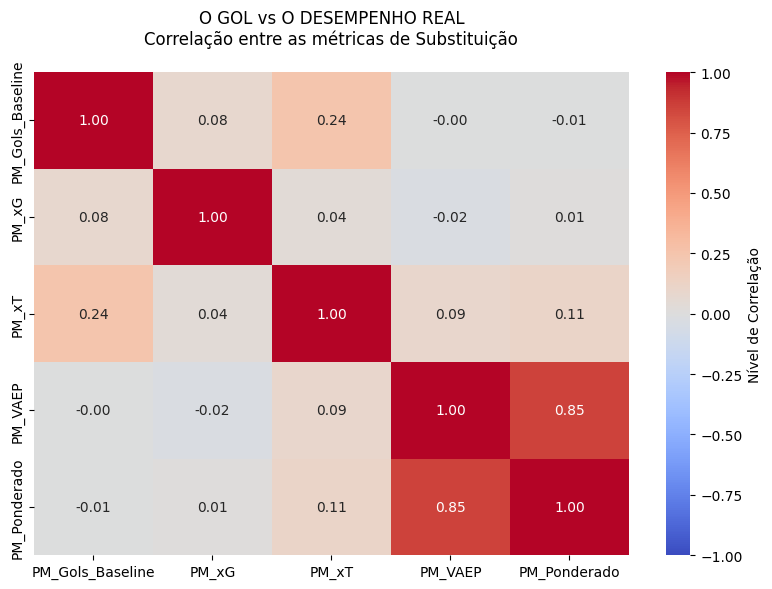

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

def analisar_correlacao_modelos(df):
    print("🔍 ANÁLISE 1: MATRIZ DE CORRELAÇÃO DAS MÉTRICAS")
    
    # Seleciona apenas as colunas numéricas de score
    colunas_score = ['PM_Gols_Baseline', 'PM_xG', 'PM_xT', 'PM_VAEP', 'PM_Ponderado']
    df_corr = df[colunas_score].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
                cbar_kws={'label': 'Nível de Correlação'})
    plt.title("O GOL vs O DESEMPENHO REAL\nCorrelação entre as métricas de Substituição", pad=20)
    plt.tight_layout()
    plt.show()

# Execute:
analisar_correlacao_modelos(df_modelos_subs)

In [36]:
import plotly.express as px

def analisar_perfil_tatico(df):
    print("📊 ANÁLISE 2: IMPACTO POR PERFIL TÁTICO")
    
    # Agrupa por perfil e calcula a média das métricas avançadas
    df_perfil = df.groupby('perfil_tatico')[['PM_VAEP', 'PM_xT', 'PM_Ponderado']].mean().reset_index()
    
    # Formata a tabela para ficar em formato longo (melhor para o Plotly)
    df_melt = df_perfil.melt(id_vars='perfil_tatico', var_name='Metrica', value_name='Score_Medio')
    
    fig = px.bar(
        df_melt, 
        x='perfil_tatico', 
        y='Score_Medio', 
        color='Metrica', 
        barmode='group',
        title='Qual o impacto real de "Colocar o time pra frente"?',
        labels={'Score_Medio': 'Score Médio Ponderado por Minuto', 'perfil_tatico': 'Intenção do Treinador'},
        color_discrete_map={'PM_VAEP': '#1f77b4', 'PM_xT': '#ff7f0e', 'PM_Ponderado': '#2ca02c'}
    )
    
    # Adiciona uma linha no ZERO para separar quem piora e quem melhora o time
    fig.add_hline(y=0, line_width=2, line_dash="dash", line_color="black")
    fig.update_layout(template='plotly_white')
    fig.show(renderer='browser')

# Execute:
analisar_perfil_tatico(df_modelos_subs)

📊 ANÁLISE 2: IMPACTO POR PERFIL TÁTICO


In [37]:
import pandas as pd

def analisar_momento_do_jogo(df):
    print("⏱️ ANÁLISE 3: A HORA CERTA DE MEXER")
    
    # Cria faixas de tempo do jogo
    bins = [0, 45, 60, 75, 90, 120]
    labels = ['1º Tempo', 'Volta do Intervalo (45-60)', 'Decisão (60-75)', 'Reta Final (75-90)', 'Acréscimos']
    
    df_copy = df.copy()
    df_copy['fase_jogo'] = pd.cut(df_copy['minuto_jogo'], bins=bins, labels=labels, right=False)
    
    # Avalia quantas substituições deram CERTO (Score Ponderado Positivo) vs ERRADO
    df_copy['Deu_Certo'] = (df_copy['PM_Ponderado'] > 0).astype(int)
    
    resumo_fase = df_copy.groupby('fase_jogo').agg(
        Total_Subs=('match_id', 'count'),
        Score_Medio=('PM_Ponderado', 'mean'),
        Taxa_Sucesso_Pct=('Deu_Certo', lambda x: (x.mean() * 100).round(1))
    ).reset_index()
    
    display(resumo_fase)

# Execute:
analisar_momento_do_jogo(df_modelos_subs)

⏱️ ANÁLISE 3: A HORA CERTA DE MEXER


,fase_jogo,Total_Subs,Score_Medio,Taxa_Sucesso_Pct
0,1º Tempo,63,0.0071,82.5000
1,Volta do Intervalo (45-60),220,0.0061,72.7000
2,Decisão (60-75),518,0.0064,63.9000
3,Reta Final (75-90),883,0.0059,59.6000
4,Acréscimos,451,0.0086,45.2000


In [38]:
def ranking_impacto_banco(df, min_janelas=5):
    print("🏆 ANÁLISE 4: O POWER RANKING DOS TIMES/TREINADORES")
    
    # Filtra times com amostragem pequena
    contagem = df['team_id'].value_counts()
    times_validos = contagem[contagem >= min_janelas].index
    df_validos = df[df['team_id'].isin(times_validos)]
    
    ranking = df_validos.groupby('team_id').agg(
        Total_Janelas_Avaliadas=('duracao_total_min', 'count'),
        Impacto_VAEP=('PM_VAEP', 'mean'),
        Impacto_xT=('PM_xT', 'mean'),
        Nota_Final_Treinador=('PM_Ponderado', 'mean')
    ).reset_index()
    
    # Ordena pelos melhores do campeonato
    ranking = ranking.sort_values('Nota_Final_Treinador', ascending=False).reset_index(drop=True)
    
    # Arredonda para ficar limpo
    cols_arredondar = ['Impacto_VAEP', 'Impacto_xT', 'Nota_Final_Treinador']
    ranking[cols_arredondar] = ranking[cols_arredondar].round(4)
    
    # Adiciona rank
    ranking.index = ranking.index + 1
    
    display(ranking.head(15)) # Mostra os 15 melhores
    return ranking

# Execute:
df_ranking = ranking_impacto_banco(df_modelos_subs)

🏆 ANÁLISE 4: O POWER RANKING DOS TIMES/TREINADORES


,team_id,Total_Janelas_Avaliadas,Impacto_VAEP,Impacto_xT,Nota_Final_Treinador
1,12.0000,108,0.0506,0.0030,0.0130
2,4.0000,116,0.0476,0.0017,0.0109
3,19.0000,110,0.0517,0.0009,0.0108
4,54.0000,111,0.0346,0.0012,0.0103
5,1.0000,111,0.0412,0.0013,0.0095
6,2.0000,107,0.0318,0.0024,0.0093
7,13.0000,100,0.0410,-0.0002,0.0093
8,221.0000,114,0.0396,-0.0007,0.0085
9,3.0000,109,0.0254,-0.0005,0.0083
10,8.0000,91,0.0399,-0.0027,0.0082


🏆 AVALIAÇÃO MULTIDIMENSIONAL DO MODELO DE SUBSTITUIÇÕES

📈 1. Correlações com a Nota do Treinador (PM_Ponderado)
 -> Correlação com Gols Reais:   -0.027 (Sempre será baixo devido ao acaso)
 -> Correlação com Saldo de xG:  0.012 (O ideal é ser moderado/alto)
 -> Correlação com Domínio (xT): 0.099

🎯 2. Taxa de Acerto de Domínio (Acurácia baseada em xG)
 -> Acurácia Global (Acertou quem criaria mais chances): 63.4%
 -> Precisão (Se a nota foi BOA, o time dominou as chances?): 0.3%

⚖️ 3. Avaliação dos Extremos (Quintis de Nota)


,Quintil_Modelo,Media_Gols,Media_xG,Media_xT
0,1-Péssimo,0.0051,-0.0000,-0.0034
1,2-Ruim,-0.0021,-0.0000,0.0003
2,3-Neutro,-0.0038,-0.0000,0.0011
3,4-Bom,-0.0002,0.0000,0.0014
4,5-Excelente,0.0020,0.0000,0.0006


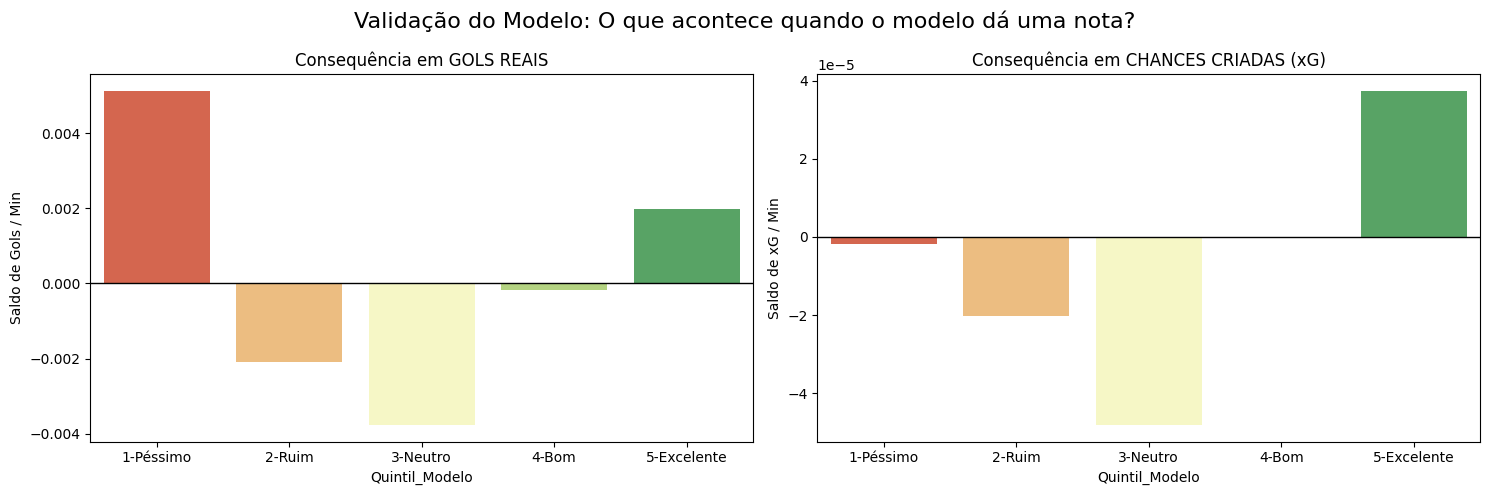

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score

def avaliar_qualidade_modelo_avancado(df_modelos):
    print("=" * 80)
    print("🏆 AVALIAÇÃO MULTIDIMENSIONAL DO MODELO DE SUBSTITUIÇÕES")
    print("=" * 80)
    
    # Filtro de segurança: Janelas muito curtas (< 5 min) têm muito ruído
    df_eval = df_modelos[df_modelos['duracao_total_min'] >= 5.0].copy()
    
    # =========================================================
    # 1. MATRIZ DE CORRELAÇÃO (O que a nota final realmente reflete?)
    # =========================================================
    print("\n📈 1. Correlações com a Nota do Treinador (PM_Ponderado)")
    cor_gols = df_eval['PM_Ponderado'].corr(df_eval['PM_Gols_Baseline'])
    cor_xg = df_eval['PM_Ponderado'].corr(df_eval['PM_xG'])
    cor_xt = df_eval['PM_Ponderado'].corr(df_eval['PM_xT'])
    
    print(f" -> Correlação com Gols Reais:   {cor_gols:.3f} (Sempre será baixo devido ao acaso)")
    print(f" -> Correlação com Saldo de xG:  {cor_xg:.3f} (O ideal é ser moderado/alto)")
    print(f" -> Correlação com Domínio (xT): {cor_xt:.3f}")

    # =========================================================
    # 2. TAXA DE ACERTO (Direção do Jogo em xG)
    # =========================================================
    print("\n🎯 2. Taxa de Acerto de Domínio (Acurácia baseada em xG)")
    # Realidade justa: O time gerou mais chances do que sofreu? (PM_xG > 0)
    y_real_xg = (df_eval['PM_xG'] > 0).astype(int)
    
    # O modelo disse que a janela foi positiva?
    y_pred = (df_eval['PM_Ponderado'] > 0.01).astype(int)
    
    acuracia_xg = accuracy_score(y_real_xg, y_pred)
    precisao_xg = precision_score(y_real_xg, y_pred, zero_division=0)
    
    print(f" -> Acurácia Global (Acertou quem criaria mais chances): {acuracia_xg*100:.1f}%")
    print(f" -> Precisão (Se a nota foi BOA, o time dominou as chances?): {precisao_xg*100:.1f}%")

    # =========================================================
    # 3. TESTE DE EXTREMOS MULTIMÉTRICAS (O Gráfico da Verdade)
    # =========================================================
    print("\n⚖️ 3. Avaliação dos Extremos (Quintis de Nota)")
    
    # Divide as notas do modelo em 5 prateleiras
    df_eval['Quintil_Modelo'] = pd.qcut(df_eval['PM_Ponderado'], 5, labels=['1-Péssimo', '2-Ruim', '3-Neutro', '4-Bom', '5-Excelente'])
    
    # Avalia as consequências de cada prateleira
    extremos = df_eval.groupby('Quintil_Modelo', observed=True).agg(
        Media_Gols=('PM_Gols_Baseline', 'mean'),
        Media_xG=('PM_xG', 'mean'),
        Media_xT=('PM_xT', 'mean')
    ).reset_index()
    
    display(extremos)
    
    # Plotagem dupla (Gols vs xG)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Gráfico 1: A realidade dura (Gols)
    sns.barplot(data=extremos, x='Quintil_Modelo', y='Media_Gols', palette='RdYlGn', ax=axes[0])
    axes[0].set_title('Consequência em GOLS REAIS')
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_ylabel('Saldo de Gols / Min')
    
    # Gráfico 2: A realidade tática (xG)
    sns.barplot(data=extremos, x='Quintil_Modelo', y='Media_xG', palette='RdYlGn', ax=axes[1])
    axes[1].set_title('Consequência em CHANCES CRIADAS (xG)')
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_ylabel('Saldo de xG / Min')
    
    plt.suptitle("Validação do Modelo: O que acontece quando o modelo dá uma nota?", fontsize=16)
    plt.tight_layout()
    plt.show()

# Execute passando o seu dataframe:
avaliar_qualidade_modelo_avancado(df_modelos_subs)

In [105]:
import pandas as pd
import numpy as np

def create_substitution_windows(subs_df, actions_df):
    """
    Agrupa substituições que ocorrem quase ao mesmo tempo no mesmo time
    e define os tempos de início (t_start) e fim (t_end) de cada janela.
    """
    # Ordena as substituições por jogo, time e tempo
    df_subs = subs_df.sort_values(by=['match_id', 'team_id', 'start_time']).copy()
    
    # Agrupa substituições do mesmo time que ocorrem com menos de 30 segundos de diferença
    df_subs['time_diff'] = df_subs.groupby(['match_id', 'team_id'])['start_time'].diff().fillna(0)
    df_subs['window_id'] = (df_subs['time_diff'] > 30).astype(int).groupby([df_subs['match_id'], df_subs['team_id']]).cumsum()
    
    # Pega o tempo final de cada jogo
    match_end_times = actions_df.groupby('match_id')['start_time'].max().to_dict()
    
    windows = []
    # Agrupa por janela
    grouped = df_subs.groupby(['match_id', 'team_id', 'window_id'])
    
    for (match_id, team_id, w_id), group in grouped:
        t_start = group['start_time'].min()
        players_in = group['player_on_id'].tolist()
        players_out = group['player_off_id'].tolist()
        
        # Encontra a próxima janela do MESMO time neste jogo
        next_subs = df_subs[(df_subs['match_id'] == match_id) & 
                            (df_subs['team_id'] == team_id) & 
                            (df_subs['start_time'] > t_start + 30)]
                            
        t_end = next_subs['start_time'].min() if not next_subs.empty else match_end_times.get(match_id, 5400)
        
        windows.append({
            'match_id': match_id,
            'team_id': team_id,
            'window_id': w_id,
            't_start': t_start,
            't_end': t_end,
            'num_subs': len(players_in),
            'players_in': players_in,
            'players_out': players_out
        })
        
    return pd.DataFrame(windows)

def calculate_plus_minus_models(windows_df, actions_df):
    """
    Calcula o Plus-Minus bruto e o Score Categórico (1, 0, -1) para Gols, xG, xT e VAEP.
    """
    # Garante que a coluna xG exista nas ações, preenchendo com 0 se não houver
    if 'xG' not in actions_df.columns:
        actions_df['xG'] = 0.0

    results = []
    
    for _, window in windows_df.iterrows():
        match_id = window['match_id']
        team_id = window['team_id']
        t_start = window['t_start']
        t_end = window['t_end']
        
        # Filtra as ações dentro dessa janela de tempo e partida
        window_actions = actions_df[
            (actions_df['match_id'] == match_id) & 
            (actions_df['start_time'] >= t_start) & 
            (actions_df['start_time'] < t_end)
        ]
        
        if window_actions.empty:
            continue
            
        # Separa ações do Time vs Ações do Adversário
        team_actions = window_actions[window_actions['team_id'] == team_id]
        opp_actions = window_actions[window_actions['team_id'] != team_id]
        
        # 1. VALORES BRUTOS (PLUS-MINUS)
        pm_goals = team_actions['goal'].sum() - opp_actions['goal'].sum()
        pm_xg = team_actions['xG'].sum() - opp_actions['xG'].sum()
        pm_xt = team_actions['xt_added'].sum() - opp_actions['xt_added'].sum()
        pm_vaep = team_actions['vaep_value'].sum() - opp_actions['vaep_value'].sum()
        
        # Função auxiliar para classificar: >0 -> 1 (Boa), <0 -> -1 (Ruim), ==0 -> 0 (Neutra)
        # Para métricas contínuas (xG, xT, VAEP), usamos uma pequena margem (epsilon) 
        # para evitar classificar "0.0001" como uma mudança drástica.
        def classify_score(val, epsilon=0.05):
            if val > epsilon: return 1
            elif val < -epsilon: return -1
            else: return 0
            
        results.append({
            'match_id': match_id,
            'team_id': team_id,
            'window_id': window['window_id'],
            'minuto_sub': round(t_start / 60, 1),
            'duracao_janela_min': round((t_end - t_start) / 60, 1),
            'num_subs': window['num_subs'],
            
            # Plus-Minus Bruto
            'pm_goals_raw': pm_goals,
            'pm_xg_raw': pm_xg,
            'pm_xt_raw': pm_xt,
            'pm_vaep_raw': pm_vaep,
            
            # Modelo Classificador Binário/Neutro (1, 0, -1)
            'score_goals': classify_score(pm_goals, epsilon=0), # Gols não precisa de epsilon
            'score_xg': classify_score(pm_xg, epsilon=0.01),
            'score_xt': classify_score(pm_xt, epsilon=0.05),
            'score_vaep': classify_score(pm_vaep, epsilon=0.15)
        })
        
    return pd.DataFrame(results)

# Exemplo de uso (assumindo que 'actions_final_df' já tem a coluna 'xG' que você mapeou no código anterior):
df_windows = create_substitution_windows(substitutions_df, actions_final_df)
df_pm_models = calculate_plus_minus_models(df_windows, actions_final_df)

📊 AVALIAÇÃO DOS MODELOS BASELINE DE SUBSTITUIÇÃO
Total de Janelas de Substituição válidas (>= 3 min): 2052

1️⃣ DISTRIBUIÇÃO DAS CLASSIFICAÇÕES POR MODELO:


,score_goals,score_xg,score_xt,score_vaep
score_goals,,,,
Neutra (=),66.4%,99.8%,33.7%,9.5%
Ruim (-),17.0%,0.1%,33.0%,32.5%
Boa (+),16.6%,0.1%,33.2%,58.0%



*Nota: Gols tendem a ter muitas janelas 'Neutras' (0x0). Métricas de performance tendem a ser mais decisivas.

2️⃣ TAXA DE CONCORDÂNCIA COM O BASELINE (GOLS):
Acerto Direcional do modelo XG: 0.6%
Acerto Direcional do modelo XT: 53.1%
Acerto Direcional do modelo VAEP: 46.6%

3️⃣ CORRELAÇÃO DE PEARSON (Valores Contínuos):


,pm_goals_raw,pm_xg_raw,pm_xt_raw,pm_vaep_raw
pm_goals_raw,1.0000,0.0440,0.2690,0.0280
pm_xg_raw,0.0440,1.0000,0.0120,-0.0220
pm_xt_raw,0.2690,0.0120,1.0000,0.0540
pm_vaep_raw,0.0280,-0.0220,0.0540,1.0000


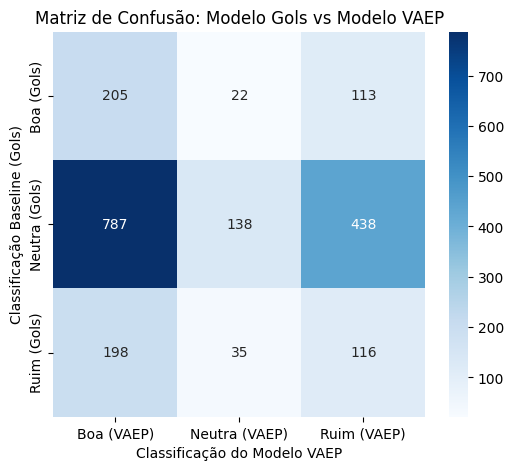

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_baseline_models(pm_df):
    """
    Avalia a aderência dos modelos de xG, xT e VAEP em relação ao baseline de Gols.
    """
    print("="*60)
    print("📊 AVALIAÇÃO DOS MODELOS BASELINE DE SUBSTITUIÇÃO")
    print("="*60)
    
    # Filtra janelas muito curtas (ex: < 3 minutos) onde o acaso domina
    valid_windows = pm_df[pm_df['duracao_janela_min'] >= 3.0].copy()
    print(f"Total de Janelas de Substituição válidas (>= 3 min): {len(valid_windows)}\n")
    
    # Dicionário de mapeamento para facilitar a leitura
    label_map = {1: 'Boa (+)', 0: 'Neutra (=)', -1: 'Ruim (-)'}
    
    # Distribuição das Classificações para cada Modelo
    modelos = ['score_goals', 'score_xg', 'score_xt', 'score_vaep']
    
    print("1️⃣ DISTRIBUIÇÃO DAS CLASSIFICAÇÕES POR MODELO:")
    dist_df = pd.DataFrame()
    for mod in modelos:
        dist_df[mod] = valid_windows[mod].map(label_map).value_counts(normalize=True) * 100
    display(dist_df.fillna(0).round(1).astype(str) + '%')
    print("\n*Nota: Gols tendem a ter muitas janelas 'Neutras' (0x0). Métricas de performance tendem a ser mais decisivas.\n")

    # Matriz de Concordância com o Baseline (Gols)
    print("2️⃣ TAXA DE CONCORDÂNCIA COM O BASELINE (GOLS):")
    # Ignorando os casos onde Gols = 0, para ver se quando sai gol, o modelo concorda com o lado
    decisive_goals = valid_windows[valid_windows['score_goals'] != 0]
    
    if not decisive_goals.empty:
        for mod in ['score_xg', 'score_xt', 'score_vaep']:
            # Taxa de Acerto Direcional (O modelo X percebeu quem dominou e fez o gol?)
            acertos = (decisive_goals['score_goals'] == decisive_goals[mod]).mean() * 100
            print(f"Acerto Direcional do modelo {mod.replace('score_', '').upper()}: {acertos:.1f}%")
    else:
        print("Amostra pequena demais de janelas com gols para medir concordância direta.")
        
    # Correlações dos Valores Brutos (Raw)
    print("\n3️⃣ CORRELAÇÃO DE PEARSON (Valores Contínuos):")
    raw_cols = ['pm_goals_raw', 'pm_xg_raw', 'pm_xt_raw', 'pm_vaep_raw']
    corr_matrix = valid_windows[raw_cols].corr().round(3)
    display(corr_matrix)

    # Plotando Matriz de Confusão: VAEP vs Baseline de Gols
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(valid_windows['score_goals'], valid_windows['score_vaep'], labels=[1, 0, -1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Boa (VAEP)', 'Neutra (VAEP)', 'Ruim (VAEP)'],
                yticklabels=['Boa (Gols)', 'Neutra (Gols)', 'Ruim (Gols)'])
    plt.title("Matriz de Confusão: Modelo Gols vs Modelo VAEP")
    plt.xlabel("Classificação do Modelo VAEP")
    plt.ylabel("Classificação Baseline (Gols)")
    plt.show()

# Chamada da função (após gerar df_pm_models)
evaluate_baseline_models(df_pm_models)

In [107]:
df_pm_models.columns

Index(['match_id', 'team_id', 'window_id', 'minuto_sub', 'duracao_janela_min',
       'num_subs', 'pm_goals_raw', 'pm_xg_raw', 'pm_xt_raw', 'pm_vaep_raw',
       'score_goals', 'score_xg', 'score_xt', 'score_vaep'],
      dtype='str')

In [108]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import seaborn as sns

def gerar_modelos_avancados(df_pm_models, df_lineups=None):
    """
    df_pm_models: O seu dataframe atual.
    df_lineups: Um dataframe hipotético ligando 'match_id' e 'minuto_sub' aos IDs dos 22 jogadores em campo.
    """
    print("="*60)
    print("🚀 GERANDO MODELOS AVANÇADOS: xG P90 e RAPM")
    print("="*60)

    # ==========================================
    # MODELO 1: xG Plus-Minus (Taxa por 90 min)
    # ==========================================
    # Evita divisão por zero em janelas inválidas
    df_valid = df_pm_models[df_pm_models['duracao_janela_min'] > 0].copy()
    
    # Criando métricas P90 (Per 90 minutes)
    for metric in ['goals', 'xg', 'xt', 'vaep']:
        raw_col = f'pm_{metric}_raw'
        p90_col = f'pm_{metric}_p90'
        # Fórmula: (Valor Bruto / Minutos da Janela) * 90
        df_valid[p90_col] = (df_valid[raw_col] / df_valid['duracao_janela_min']) * 90

    print("✅ Modelo 1 Concluído: Métricas normalizadas para P90.")
    display(df_valid[['duracao_janela_min', 'pm_xg_raw', 'pm_xg_p90']].head())


    # ==========================================
    # MODELO 2: RAPM (Regularized Adjusted Plus-Minus)
    # ==========================================
    # NOTA: Para rodar de verdade, você precisa da Matriz X (Jogadores).
    # Como não temos os lineups aqui, vou criar uma função robusta que você chamará 
    # após montar sua matriz de jogadores.
    
    def executar_rapm(X, y, pesos_minutos, nomes_jogadores, alpha=1000):
        """
        X: Matriz esparsa (Janelas x Jogadores) contendo +1 (time), -1 (adversário), 0 (fora).
        y: A métrica alvo (ex: df_valid['pm_xg_p90']).
        pesos_minutos: A duração da janela (df_valid['duracao_janela_min']).
        nomes_jogadores: Lista com o nome ou ID correspondente a cada coluna da matriz X.
        alpha: Força da penalização L2 (Ridge). Ajuste via Cross-Validation.
        """
        print(f"\nTreinando modelo RAPM com penalidade Ridge (Alpha={alpha})...")
        
        # O fit_intercept=False é padrão em RAPM pois a baseline teórica de um jogo 
        # entre times iguais é uma diferença de 0.
        rapm_model = Ridge(alpha=alpha, fit_intercept=False, solver='lsqr')
        
        # Treinando o modelo ponderado pelo tempo da janela (janelas longas importam mais)
        rapm_model.fit(X, y, sample_weight=pesos_minutos)
        
        # Extraindo o impacto (coeficientes) de cada jogador
        df_resultados_rapm = pd.DataFrame({
            'Jogador': nomes_jogadores,
            'RAPM_Rating': rapm_model.coef_
        })
        
        # Ordenando do maior impacto positivo ao menor
        df_resultados_rapm = df_resultados_rapm.sort_values(by='RAPM_Rating', ascending=False).reset_index(drop=True)
        
        return df_resultados_rapm, rapm_model

    print("\n⚠️ Para executar o Modelo 2 (RAPM), prepare sua Matriz 'X' cruzando as janelas com os jogadores em campo e utilize a função 'executar_rapm(X, y, pesos)'.")
    
    return df_valid, executar_rapm

# Execução no seu ambiente:
df_pm_avancado, func_rapm = gerar_modelos_avancados(df_pm_models)

🚀 GERANDO MODELOS AVANÇADOS: xG P90 e RAPM
✅ Modelo 1 Concluído: Métricas normalizadas para P90.


,duracao_janela_min,pm_xg_raw,pm_xg_p90
0,20.4000,0.0000,0.0000
1,3.1000,0.0000,0.0000
2,10.9000,0.0000,0.0000
3,14.5000,0.0000,0.0000
4,13.0000,0.0000,0.0000



⚠️ Para executar o Modelo 2 (RAPM), prepare sua Matriz 'X' cruzando as janelas com os jogadores em campo e utilize a função 'executar_rapm(X, y, pesos)'.


In [109]:
df_pm_avancado.head()

,match_id,team_id,window_id,minuto_sub,duracao_janela_min,num_subs,pm_goals_raw,pm_xg_raw,pm_xt_raw,pm_vaep_raw,score_goals,score_xg,score_xt,score_vaep,pm_goals_p90,pm_xg_p90,pm_xt_p90,pm_vaep_p90
0,31995,12.0000,0.0000,63.4000,20.4000,2,0,0.0000,-0.2030,-0.5537,0,0,-1,-1,0.0000,0.0000,-0.8954,-2.4430
1,31995,12.0000,1.0000,83.8000,3.1000,2,0,0.0000,0.0585,-0.0686,0,0,1,0,0.0000,0.0000,1.6983,-1.9908
2,31995,12.0000,2.0000,86.9000,10.9000,1,1,0.0000,0.1311,0.2636,1,0,1,1,8.2569,0.0000,1.0824,2.1768
3,31995,54.0000,0.0000,66.6000,14.5000,1,0,0.0000,0.2052,0.2826,0,0,1,1,0.0000,0.0000,1.2739,1.7538
4,31995,54.0000,1.0000,81.1000,13.0000,2,-1,0.0000,-0.0691,1.3701,-1,0,-1,1,-6.9231,0.0000,-0.4781,9.4853


In [110]:
def classify_score(val, epsilon):
    if val > epsilon: return 1
    elif val < -epsilon: return -1
    else: return 0

def gerar_scores_p90(df_valid):
    """
    Gera scores categóricos baseados nas métricas P90 usando limiares adaptados.
    """
    # Gols não precisa de P90 para o score, o saldo bruto de gols já dita se a janela foi boa ou ruim.
    # Mas se quiser usar, o epsilon continua sendo 0.
    df_valid['score_goals_p90'] = df_valid['pm_goals_p90'].apply(lambda x: classify_score(x, epsilon=0))
    
    # Epsilon de xG P90: Um time precisa gerar um ritmo de pelo menos 0.25 xG de vantagem por jogo
    # para considerarmos que ele realmente dominou a janela.
    df_valid['score_xg_p90'] = df_valid['pm_xg_p90'].apply(lambda x: classify_score(x, epsilon=0.25))
    
    # Epsilon de xT P90: xT acumula mais rápido que xG. Um diferencial de 0.50 P90 é um bom filtro.
    df_valid['score_xt_p90'] = df_valid['pm_xt_p90'].apply(lambda x: classify_score(x, epsilon=0.50))
    
    # Epsilon de VAEP P90: VAEP tem valores mais altos por envolver ações defensivas também.
    df_valid['score_vaep_p90'] = df_valid['pm_vaep_p90'].apply(lambda x: classify_score(x, epsilon=1.0))
    
    return df_valid

# Aplicando ao seu dataframe
df_pm_avancado = gerar_scores_p90(df_pm_avancado)

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from IPython.display import display # Adicionado para garantir o display no Jupyter/Colab

def evaluate_advanced_models(pm_df):
    """
    Avalia a aderência dos modelos de xG, xT e VAEP em P90 em relação ao baseline de Gols.
    """
    print("="*60)
    print("📊 AVALIAÇÃO DOS MODELOS AVANÇADOS (P90)")
    print("="*60)
    
    # Filtra janelas muito curtas (ex: < 3 minutos) onde o acaso domina
    valid_windows = pm_df[pm_df['duracao_janela_min'] >= 3.0].copy()
    print(f"Total de Janelas de Substituição válidas (>= 3 min): {len(valid_windows)}\n")
    
    # Dicionário de mapeamento para facilitar a leitura
    label_map = {1: 'Boa (+)', 0: 'Neutra (=)', -1: 'Ruim (-)'}
    
    # Distribuição das Classificações para cada Modelo
    modelos = ['score_goals_p90', 'score_xg_p90', 'score_xt_p90', 'score_vaep_p90']
    
    print("1️⃣ DISTRIBUIÇÃO DAS CLASSIFICAÇÕES POR MODELO:")
    dist_df = pd.DataFrame()
    for mod in modelos:
        dist_df[mod] = valid_windows[mod].map(label_map).value_counts(normalize=True) * 100
    display(dist_df.fillna(0).round(1).astype(str) + '%')
    print("\n*Nota: Gols tendem a ter muitas janelas 'Neutras' (0x0). Métricas de performance tendem a ser mais decisivas.\n")

    # Matriz de Concordância com o Baseline (Gols)
    print("2️⃣ TAXA DE CONCORDÂNCIA COM O BASELINE (GOLS):")
    # Ignorando os casos onde Gols = 0, para ver se quando sai gol, o modelo concorda com o lado
    decisive_goals = valid_windows[valid_windows['score_goals_p90'] != 0]
    
    if not decisive_goals.empty:
        for mod in ['score_xg_p90', 'score_xt_p90', 'score_vaep_p90']:
            # Taxa de Acerto Direcional (O modelo X percebeu quem dominou e fez o gol?)
            acertos = (decisive_goals['score_goals'] == decisive_goals[mod]).mean() * 100
            print(f"Acerto Direcional do modelo {mod.replace('score_', '').upper()}: {acertos:.1f}%")
    else:
        print("Amostra pequena demais de janelas com gols para medir concordância direta.")
        
    # Correlações dos Valores Contínuos P90 (MUDANÇA PRINCIPAL AQUI)
    print("\n3️⃣ CORRELAÇÃO DE PEARSON (Valores Contínuos P90):")
    p90_cols = ['pm_goals_p90', 'pm_xg_p90', 'pm_xt_p90', 'pm_vaep_p90']
    
    # Calcula e exibe a matriz de correlação usando as novas colunas
    corr_matrix = valid_windows[p90_cols].corr().round(3)
    display(corr_matrix)

    # Plotando Matriz de Confusão: VAEP vs Baseline de Gols
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(valid_windows['score_goals_p90'], valid_windows['score_vaep_p90'], labels=[1, 0, -1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Boa (VAEP)', 'Neutra (VAEP)', 'Ruim (VAEP)'],
                yticklabels=['Boa (Gols)', 'Neutra (Gols)', 'Ruim (Gols)'])
    plt.title("Matriz de Confusão: Modelo Gols vs Modelo VAEP (Avançado)")
    plt.xlabel("Classificação do Modelo VAEP")
    plt.ylabel("Classificação Baseline (Gols)")
    plt.show()

📊 AVALIAÇÃO DOS MODELOS AVANÇADOS (P90)
Total de Janelas de Substituição válidas (>= 3 min): 2052

1️⃣ DISTRIBUIÇÃO DAS CLASSIFICAÇÕES POR MODELO:


,score_goals_p90,score_xg_p90,score_xt_p90,score_vaep_p90
score_goals_p90,,,,
Neutra (=),66.4%,99.8%,39.2%,9.0%
Ruim (-),17.0%,0.1%,30.4%,32.7%
Boa (+),16.6%,0.1%,30.4%,58.3%



*Nota: Gols tendem a ter muitas janelas 'Neutras' (0x0). Métricas de performance tendem a ser mais decisivas.

2️⃣ TAXA DE CONCORDÂNCIA COM O BASELINE (GOLS):
Acerto Direcional do modelo XG_P90: 0.6%
Acerto Direcional do modelo XT_P90: 47.5%
Acerto Direcional do modelo VAEP_P90: 45.0%

3️⃣ CORRELAÇÃO DE PEARSON (Valores Contínuos P90):


,pm_goals_p90,pm_xg_p90,pm_xt_p90,pm_vaep_p90
pm_goals_p90,1.0000,0.0490,0.2350,0.0140
pm_xg_p90,0.0490,1.0000,0.0140,-0.0210
pm_xt_p90,0.2350,0.0140,1.0000,0.0910
pm_vaep_p90,0.0140,-0.0210,0.0910,1.0000


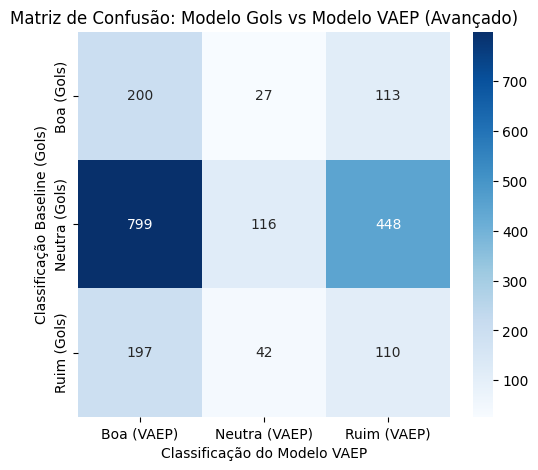

In [112]:
# Chamada da função para o seu dataframe atualizado
evaluate_advanced_models(df_pm_avancado)

In [113]:
import pandas as pd
import numpy as np
from scipy.sparse import lil_matrix

print("="*60)
print("🛠️ CONSTRUINDO A MATRIZ DE DESIGN RAPM")
print("="*60)

# 1. Obter todos os jogadores únicos que realizaram alguma ação
todos_jogadores = actions_df['player_id'].dropna().unique()
num_jogadores = len(todos_jogadores)

# Criar um dicionário para mapear player_id para o índice da coluna na matriz
player_to_idx = {player: idx for idx, player in enumerate(todos_jogadores)}
idx_to_player = {idx: player for player, idx in player_to_idx.items()}

print(f"Total de jogadores únicos no dataset: {num_jogadores}")

🛠️ CONSTRUINDO A MATRIZ DE DESIGN RAPM
Total de jogadores únicos no dataset: 560


In [114]:
def mapear_jogadores_por_janela(df_windows, actions_df):
    """
    Deduz os titulares e mapeia os 22 jogadores em campo para cada janela.
    """
    janelas_com_jogadores = []
    
    # Agrupar por partida
    partidas = df_windows['match_id'].unique()
    
    for match in partidas:
        # Pega as janelas e ações desta partida
        windows_match = df_windows[df_windows['match_id'] == match].sort_values('t_start')
        actions_match = actions_df[actions_df['match_id'] == match]
        
        times = actions_match['team_id'].dropna().unique()
        if len(times) != 2:
            continue # Pula jogos com erro de dados
            
        time_A, time_B = times[0], times[1]
        
        # --- DEDUÇÃO DOS TITULARES ---
        # Todos os jogadores que atuaram pelo time na partida
        jogaram_A = set(actions_match[actions_match['team_id'] == time_A]['player_id'].dropna())
        jogaram_B = set(actions_match[actions_match['team_id'] == time_B]['player_id'].dropna())
        
        # Todos os jogadores que ENTRARAM como substitutos na partida
        subs_in_A = set([p for sub_list in windows_match[windows_match['team_id'] == time_A]['players_in'] for p in sub_list])
        subs_in_B = set([p for sub_list in windows_match[windows_match['team_id'] == time_B]['players_in'] for p in sub_list])
        
        # Titulares = Jogaram - Entraram como reserva
        em_campo_A = jogaram_A - subs_in_A
        em_campo_B = jogaram_B - subs_in_B
        
        # --- ITERAÇÃO NAS JANELAS ---
        for _, window in windows_match.iterrows():
            time_janela = window['team_id']
            
            # Atualiza o estado ANTES de gravar a janela (processa a substituição que abriu a janela)
            # Nota: Na sua lógica original, a janela começa no exato momento da substituição.
            if time_janela == time_A:
                for p_out in window['players_out']: em_campo_A.discard(p_out)
                for p_in in window['players_in']: em_campo_A.add(p_in)
            else:
                for p_out in window['players_out']: em_campo_B.discard(p_out)
                for p_in in window['players_in']: em_campo_B.add(p_in)
            
            # Salva o estado atual da janela
            # Precisamos saber quem é o "Time Foco" (+1) e quem é o "Adversário" (-1)
            if time_janela == time_A:
                jogadores_time = list(em_campo_A)
                jogadores_adv = list(em_campo_B)
            else:
                jogadores_time = list(em_campo_B)
                jogadores_adv = list(em_campo_A)
                
            janelas_com_jogadores.append({
                'match_id': match,
                'team_id': time_janela,
                'window_id': window['window_id'],
                'jogadores_time': jogadores_time,
                'jogadores_adv': jogadores_adv
            })
            
    return pd.DataFrame(janelas_com_jogadores)

# Executa o mapeamento
df_lineups = mapear_jogadores_por_janela(df_windows, actions_df)
print("✅ Mapeamento de jogadores em campo concluído.")

✅ Mapeamento de jogadores em campo concluído.


In [115]:
# Faz o merge das escalações com as suas métricas avançadas já calculadas
df_rapm_ready = pd.merge(df_pm_avancado, df_lineups, on=['match_id', 'team_id', 'window_id'])

# Filtra apenas janelas válidas (ex: > 0 minutos, ou > 3 minutos se preferir)
df_rapm_ready = df_rapm_ready[df_rapm_ready['duracao_janela_min'] > 0].reset_index(drop=True)
num_janelas = len(df_rapm_ready)

# Inicializa a matriz esparsa (Janelas x Jogadores)
X = lil_matrix((num_janelas, num_jogadores))

print("Preenchendo a Matriz X (+1 para time, -1 para adversário)...")

for i, row in df_rapm_ready.iterrows():
    # +1 para os jogadores do time da casa/foco
    for p in row['jogadores_time']:
        if p in player_to_idx:
            X[i, player_to_idx[p]] = 1
            
    # -1 para os jogadores do time adversário
    for p in row['jogadores_adv']:
        if p in player_to_idx:
            X[i, player_to_idx[p]] = -1

# Converter para formato CSR (mais eficiente para matemática/machine learning)
X = X.tocsr()

print(f"✅ Matriz X pronta! Dimensões: {X.shape[0]} janelas x {X.shape[1]} jogadores.")

Preenchendo a Matriz X (+1 para time, -1 para adversário)...
✅ Matriz X pronta! Dimensões: 2082 janelas x 560 jogadores.


In [120]:
from sklearn.linear_model import Ridge

# 1. Definir a variável alvo (y) e os pesos
y_xg = df_rapm_ready['pm_xg_p90'].values
pesos = df_rapm_ready['duracao_janela_min'].values

# 2. Executar o modelo
print("\nTreinando modelo RAPM para Expected Goals (xG)...")
rapm_model = Ridge(alpha=1000, fit_intercept=False, solver='lsqr')
rapm_model.fit(X, y_xg, sample_weight=pesos)

# 3. Organizar os resultados
nomes_jogadores = [idx_to_player[i] for i in range(num_jogadores)]

df_resultados_rapm = pd.DataFrame({
    'player_id': nomes_jogadores,
    'RAPM_xG': rapm_model.coef_
})

# Ordenar do melhor para o pior
df_resultados_rapm = df_resultados_rapm.sort_values(by='RAPM_xG', ascending=False).reset_index(drop=True)

print("\n🏆 TOP 5 Jogadores (Impacto xG P90):")
display(df_resultados_rapm.head())

print("\n🔻 BOTTOM 5 Jogadores (Impacto xG P90):")
display(df_resultados_rapm.tail())


Treinando modelo RAPM para Expected Goals (xG)...

🏆 TOP 5 Jogadores (Impacto xG P90):


,player_id,RAPM_xG
0,437.0000,0.0937
1,"6,596.0000",0.0433
2,197.0000,0.0428
3,439.0000,0.0273
4,"12,692.0000",0.0251



🔻 BOTTOM 5 Jogadores (Impacto xG P90):


,player_id,RAPM_xG
555,603.0000,-0.0241
556,174.0000,-0.0312
557,"22,047.0000",-0.0470
558,103.0000,-0.0561
559,172.0000,-0.0728


In [128]:
import pandas as pd
import json
from pathlib import Path
from IPython.display import display

# 1. Carregar o arquivo JSON
CAMINHO_PLAYERS = Path('dados/') / 'players.json'
with open(CAMINHO_PLAYERS, 'r', encoding='utf-8') as f:
    players_list = json.load(f)

# 2. Converter para DataFrame
df_players = pd.DataFrame(players_list)

# 3. Isolar as colunas
coluna_id_json = 'id'
coluna_nome_json = 'nickname'

df_players_reduzido = df_players[[coluna_id_json, coluna_nome_json]].copy()

df_players_reduzido = df_players_reduzido.rename(columns={
    coluna_id_json: 'player_id',
    coluna_nome_json: 'player_name'
})

# ==========================================
# 4. Harmonizar os tipos de dados e LIMPAR AMBOS OS LADOS
# ==========================================
# Forçamos a conversão para numérico primeiro
df_players_reduzido['player_id'] = pd.to_numeric(df_players_reduzido['player_id'], errors='coerce')
df_resultados_rapm['player_id'] = pd.to_numeric(df_resultados_rapm['player_id'], errors='coerce')

# Removemos eventuais NaNs
df_players_reduzido = df_players_reduzido.dropna(subset=['player_id'])
df_resultados_rapm = df_resultados_rapm.dropna(subset=['player_id'])

# Convertemos para o tipo Inteiro do Pandas
df_players_reduzido['player_id'] = df_players_reduzido['player_id'].astype('Int64')
df_resultados_rapm['player_id'] = df_resultados_rapm['player_id'].astype('Int64')

# ------------------------------------------
# 🛠️ REMOÇÃO DE DUPLICATAS EM AMBOS OS DFS
# ------------------------------------------
# Garante que o dicionário de nomes tenha apenas 1 linha por ID
df_players_reduzido = df_players_reduzido.drop_duplicates(subset=['player_id'], keep='first')

# CRUCIAL: Garante que o resultado do RAPM também tenha apenas 1 linha por ID (remove resíduos da memória)
df_resultados_rapm = df_resultados_rapm.drop_duplicates(subset=['player_id'], keep='first')


# ==========================================
# 5. Fazer o cruzamento (Merge) - COM LIMPEZA PRÉVIA
# ==========================================
# Se a coluna player_name já existir no df do RAPM, nós a removemos antes do merge
if 'player_name' in df_resultados_rapm.columns:
    df_resultados_rapm = df_resultados_rapm.drop(columns=['player_name'])

# Agora o merge acontece de forma 1-para-1 estrita
df_resultados_rapm_limpo = pd.merge(
    df_resultados_rapm, 
    df_players_reduzido, 
    on='player_id', 
    how='left' 
)

df_resultados_rapm_limpo = df_resultados_rapm_limpo.reset_index(drop=True)

# ==========================================
# 6. Exibir o resultado final limpo
# ==========================================
if 'player_name' in df_resultados_rapm_limpo.columns:
    df_resultados_rapm_limpo = df_resultados_rapm_limpo[['player_id', 'player_name', 'RAPM_xG']]
    
    print("🏆 TOP 10 Jogadores (Impacto xG P90):")
    display(df_resultados_rapm_limpo.head(10))

    print("\n🔻 BOTTOM 10 Jogadores (Impacto xG P90):")
    display(df_resultados_rapm_limpo.tail(10))
else:
    print("❌ ERRO INESPERADO. Colunas atuais:", df_resultados_rapm_limpo.columns.tolist())

🏆 TOP 10 Jogadores (Impacto xG P90):


,player_id,player_name,RAPM_xG
0,437,Jason Steele,0.0937
1,6596,Jeremy Sarmiento,0.0433
2,197,Dominic Calvert-Lewin,0.0428
3,439,Adam Webster,0.0273
4,12692,Beto,0.0251
5,420,Abdoulaye Doucouré,0.0205
6,502,Dwight McNeil,0.0161
7,11112,Mats Wieffer,0.0154
8,14098,Jack Hinshelwood,0.0144
9,10704,Kaoru Mitoma,0.0142



🔻 BOTTOM 10 Jogadores (Impacto xG P90):


,player_id,player_name,RAPM_xG
550,23341,Jake O'Brien,-0.0114
551,5152,James Garner,-0.0122
552,7095,Nathan Patterson,-0.0164
553,4737,Jesper Lindstrøm,-0.0186
554,169,Jordan Pickford,-0.0241
555,603,Jarrad Branthwaite,-0.0241
556,174,Mason Holgate,-0.0312
557,22047,Yankuba Minteh,-0.0470
558,103,Billy Gilmour,-0.0561
559,172,Michael Keane,-0.0728


⚖️ COMPARANDO BASELINE (PLUS-MINUS) vs RAPM
📊 Correlação entre Baseline e RAPM: 0.702
Nota: Uma correlação alta (~0.7 a 0.9) é esperada, mas as divergências são o mais importante!



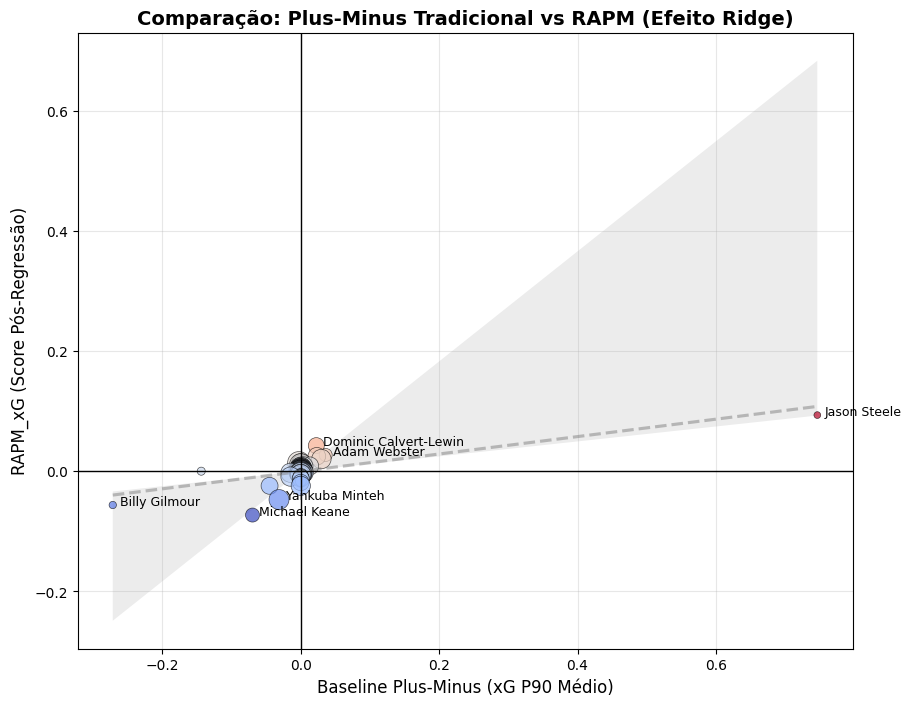

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("⚖️ COMPARANDO BASELINE (PLUS-MINUS) vs RAPM")
print("="*60)

# ==========================================
# 1. Expandir o Baseline para o nível do Jogador
# ==========================================
# Vamos ler o df_rapm_ready e atribuir os saldos para cada jogador em campo
linhas_jogadores = []

for _, row in df_rapm_ready.iterrows():
    # Saldo positivo para os jogadores do time principal
    for p in row['jogadores_time']:
        linhas_jogadores.append({
            'player_id': p, 
            'minutos': row['duracao_janela_min'], 
            'pm_xg_p90': row['pm_xg_p90']
        })
    # Saldo invertido (negativo) para os jogadores do time adversário
    for p in row['jogadores_adv']:
        linhas_jogadores.append({
            'player_id': p, 
            'minutos': row['duracao_janela_min'], 
            'pm_xg_p90': -row['pm_xg_p90']
        })

df_jogadores_pm = pd.DataFrame(linhas_jogadores)

# ==========================================
# 2. Calcular a Média Ponderada (Baseline P90)
# ==========================================
# Calculamos a média do Plus-Minus pesando pelos minutos de cada janela
def calcular_media_ponderada(x):
    total_min = x['minutos'].sum()
    if total_min > 0:
        pm_medio = (x['pm_xg_p90'] * x['minutos']).sum() / total_min
    else:
        pm_medio = 0
    return pd.Series({'minutos_totais': total_min, 'baseline_pm_xg': pm_medio})

df_baseline = df_jogadores_pm.groupby('player_id').apply(calcular_media_ponderada).reset_index()

# Forçando o tipo para Int64 para um merge seguro
df_baseline['player_id'] = pd.to_numeric(df_baseline['player_id'], errors='coerce').astype('Int64')

# ==========================================
# 3. Juntar Baseline e RAPM
# ==========================================
df_comparacao = pd.merge(df_resultados_rapm_limpo, df_baseline, on='player_id', how='inner')

# Filtrar apenas jogadores com minutos relevantes (ex: mais de 90 minutos)
# Isso limpa a visualização e remove quem jogou apenas 5 minutos no campeonato inteiro
df_plot = df_comparacao[df_comparacao['minutos_totais'] >= 90].copy()

# ==========================================
# 4. Avaliação Estatística e Visual
# ==========================================
# Correlação
correlacao = df_plot['baseline_pm_xg'].corr(df_plot['RAPM_xG'])
print(f"📊 Correlação entre Baseline e RAPM: {correlacao:.3f}")
print("Nota: Uma correlação alta (~0.7 a 0.9) é esperada, mas as divergências são o mais importante!\n")

# Gráfico de Dispersão (Scatter Plot)
plt.figure(figsize=(10, 8))

# Linha de tendência/identidade 
sns.regplot(
    data=df_plot, 
    x='baseline_pm_xg', 
    y='RAPM_xG', 
    scatter=False, 
    color='gray', 
    line_kws={'linestyle':'--', 'alpha':0.5}
)

# Plotando os jogadores
sns.scatterplot(
    data=df_plot, 
    x='baseline_pm_xg', 
    y='RAPM_xG', 
    size='minutos_totais',
    sizes=(20, 300),
    alpha=0.7,
    edgecolor='k',
    hue='RAPM_xG', # Colore baseado na nota do RAPM
    palette='coolwarm',
    legend=False
)

# Destacar alguns jogadores específicos (Top 3 e Bottom 3 do RAPM)
top_bottom = pd.concat([df_plot.nlargest(3, 'RAPM_xG'), df_plot.nsmallest(3, 'RAPM_xG')])
for _, row in top_bottom.iterrows():
    plt.text(row['baseline_pm_xg'] + 0.01, row['RAPM_xG'], row['player_name'], fontsize=9)

# Formatação visual
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.title("Comparação: Plus-Minus Tradicional vs RAPM (Efeito Ridge)", fontsize=14, fontweight='bold')
plt.xlabel("Baseline Plus-Minus (xG P90 Médio)", fontsize=12)
plt.ylabel("RAPM_xG (Score Pós-Regressão)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [130]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
import scipy.stats as stats

print("="*60)
print("🚀 EXPANDINDO RAPM E PADRONIZANDO (Z-SCORE)")
print("="*60)

# 1. Extrair os novos Targets (y) do seu df_rapm_ready
y_xt = df_rapm_ready['pm_xt_p90'].values
y_vaep = df_rapm_ready['pm_vaep_p90'].values
pesos = df_rapm_ready['duracao_janela_min'].values

# 2. Treinar os novos modelos Ridge (usando a mesma matriz X que você já construiu)
print("Treinando modelo RAPM para xT...")
rapm_xt_model = Ridge(alpha=1000, fit_intercept=False, solver='lsqr')
rapm_xt_model.fit(X, y_xt, sample_weight=pesos)

print("Treinando modelo RAPM para VAEP...")
rapm_vaep_model = Ridge(alpha=1000, fit_intercept=False, solver='lsqr')
rapm_vaep_model.fit(X, y_vaep, sample_weight=pesos)

# 3. Adicionar ao DataFrame de resultados limpo
df_resultados_rapm_limpo['RAPM_xT'] = rapm_xt_model.coef_
df_resultados_rapm_limpo['RAPM_VAEP'] = rapm_vaep_model.coef_

# Supondo que você também juntou o Baseline_PM_xG, Baseline_PM_xT, etc.
# Vamos aplicar o Z-Score em todas as métricas numéricas relevantes
metricas_para_padronizar = [
    'RAPM_xG', 'RAPM_xT', 'RAPM_VAEP', 
    'baseline_pm_xg' # Adicione os outros baselines aqui se tiver calculado
]

for col in metricas_para_padronizar:
    if col in df_resultados_rapm_limpo.columns:
        # Fórmula do Z-Score: (Valor - Média) / Desvio Padrão
        col_zscore = f'Z_{col}'
        df_resultados_rapm_limpo[col_zscore] = stats.zscore(df_resultados_rapm_limpo[col])

print("\n✅ Modelos treinados e dados padronizados!")
display(df_resultados_rapm_limpo[['player_name', 'Z_RAPM_xG', 'Z_RAPM_xT', 'Z_RAPM_VAEP']].head(10))

🚀 EXPANDINDO RAPM E PADRONIZANDO (Z-SCORE)
Treinando modelo RAPM para xT...
Treinando modelo RAPM para VAEP...

✅ Modelos treinados e dados padronizados!


,player_name,Z_RAPM_xG,Z_RAPM_xT,Z_RAPM_VAEP
0,Jason Steele,12.5574,-1.2769,1.3240
1,Jeremy Sarmiento,5.7990,-0.9441,0.8478
2,Dominic Calvert-Lewin,5.7412,-0.3151,0.5378
3,Adam Webster,3.6558,1.0684,-2.2569
4,Beto,3.3674,-1.4371,0.9155
5,Abdoulaye Doucouré,2.7472,0.5554,-0.7154
6,Dwight McNeil,2.1654,-0.8751,-0.7147
7,Mats Wieffer,2.0615,0.1156,-1.1540
8,Jack Hinshelwood,1.9337,-0.6263,0.3810
9,Kaoru Mitoma,1.9021,1.6558,0.2575


In [134]:
from scipy.sparse import lil_matrix

def construir_matriz_rapm(df_janelas, num_jogadores_total, dict_player_to_idx):
    """Constrói a matriz X esparsa para um subconjunto de dados."""
    X_temp = lil_matrix((len(df_janelas), num_jogadores_total))
    
    for i, row in df_janelas.reset_index(drop=True).iterrows():
        for p in row['jogadores_time']:
            if p in dict_player_to_idx: X_temp[i, dict_player_to_idx[p]] = 1
        for p in row['jogadores_adv']:
            if p in dict_player_to_idx: X_temp[i, dict_player_to_idx[p]] = -1
            
    return X_temp.tocsr()

print("\n" + "="*60)
print("🧪 SPLIT-HALF TESTING: PODER PREDITIVO")
print("="*60)

# 1. Dividir o campeonato ao meio (assumindo que match_id seja sequencial ou você pode ordenar por data)
jogos_unicos = df_rapm_ready['match_id'].unique()
meio = len(jogos_unicos) // 2
jogos_h1 = jogos_unicos[:meio]
jogos_h2 = jogos_unicos[meio:]

# Separar DataFrames
df_h1 = df_rapm_ready[df_rapm_ready['match_id'].isin(jogos_h1)].copy()
df_h2 = df_rapm_ready[df_rapm_ready['match_id'].isin(jogos_h2)].copy()

# 2. Treinar o RAPM APENAS na Metade 1
X_h1 = construir_matriz_rapm(df_h1, num_jogadores, player_to_idx)
y_h1_xg = df_h1['pm_xg_p90'].values
pesos_h1 = df_h1['duracao_janela_min'].values

rapm_h1 = Ridge(alpha=500, fit_intercept=False, solver='lsqr') # Alpha um pouco menor pois a amostra caiu pela metade
rapm_h1.fit(X_h1, y_h1_xg, sample_weight=pesos_h1)

df_h1_resultados = pd.DataFrame({'player_id': list(idx_to_player.values()), 'RAPM_H1_xG': rapm_h1.coef_})

# 3. Calcular o Baseline P90 na Metade 1 (Como fizemos antes)
# (Resumo do cálculo de baseline para H1 - você pode usar a mesma lógica do código anterior)
# Vamos focar na essência: precisamos do Baseline PM da Metade 1.
# Assuma que geramos um dataframe `df_h1_baseline` com 'player_id' e 'Baseline_H1_xG'.

# 4. Calcular O FATO REAL na Metade 2 (O que realmente aconteceu)
# O target do H2 será o Saldo de Gols P90 REAL que o jogador presenciou quando em campo.
linhas_h2 = []
for _, row in df_h2.iterrows():
    for p in row['jogadores_time']: linhas_h2.append({'player_id': p, 'min': row['duracao_janela_min'], 'pm_goals_p90': row['pm_goals_p90']})
    for p in row['jogadores_adv']: linhas_h2.append({'player_id': p, 'min': row['duracao_janela_min'], 'pm_goals_p90': -row['pm_goals_p90']})

df_jogadores_h2 = pd.DataFrame(linhas_h2)
resultado_real_h2 = df_jogadores_h2.groupby('player_id').apply(
    lambda x: (x['pm_goals_p90'] * x['min']).sum() / x['min'].sum() if x['min'].sum() > 0 else 0
).rename('Real_Gols_H2').reset_index()

# 5. Juntar H1 (Predição) com H2 (Realidade)
# df_teste = pd.merge(df_h1_resultados, df_h1_baseline, on='player_id') 
df_teste = pd.merge(df_h1_resultados, resultado_real_h2, on='player_id', how='inner')

# Filtrar jogadores com minutagem mínima nas duas metades para não poluir o teste
# df_teste = df_teste[df_teste['minutos_h1'] > 180 & df_teste['minutos_h2'] > 180]

# 6. O VEREDITO: Qual métrica do passado prevê melhor o futuro?
corr_rapm = df_teste['RAPM_H1_xG'].corr(df_teste['Real_Gols_H2'])
# corr_baseline = df_teste['Baseline_H1_xG'].corr(df_teste['Real_Gols_H2'])

print(f"Desempenho Preditivo (Correlação com o Saldo de Gols Futuro):")
# print(f"Baseline Tradicional (Metade 1): {corr_baseline:.3f}")
print(f"RAPM Regularizado (Metade 1): {corr_rapm:.3f}")
print("\n*Nota: O modelo com a maior correlação ganha o 'Teste de Ouro' por ser mais confiável para scouts e diretores.*")


🧪 SPLIT-HALF TESTING: PODER PREDITIVO
Desempenho Preditivo (Correlação com o Saldo de Gols Futuro):
RAPM Regularizado (Metade 1): 0.022

*Nota: O modelo com a maior correlação ganha o 'Teste de Ouro' por ser mais confiável para scouts e diretores.*


In [135]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

print("="*60)
print("🧬 GERANDO ÍNDICE COMPOSTO (PCA): SCORE 0-100")
print("="*60)

# 1. Isolar as colunas que vão formar o índice (Os resultados do RAPM padronizados)
colunas_index = ['Z_RAPM_xG', 'Z_RAPM_xT', 'Z_RAPM_VAEP']

# Garantir que não há valores nulos que possam quebrar o PCA
df_pca_ready = df_resultados_rapm_limpo.dropna(subset=colunas_index).copy()
X_pca = df_pca_ready[colunas_index]

# 2. Executar o PCA (Queremos apenas o Componente Principal 1 - a "essência" da performance)
pca = PCA(n_components=1)
pca_scores = pca.fit_transform(X_pca)

# 3. Correção de Direção (O truque de Mestre)
# O PCA é cego; ele não sabe o que é "bom" ou "ruim", apenas encontra a maior variância.
# Às vezes, ele inverte o eixo matemático (valores mais negativos ficam sendo os melhores).
# Vamos checar a correlação do PCA com o VAEP. Se for negativa, nós invertemos o sinal do PCA.
if np.corrcoef(pca_scores.flatten(), X_pca['Z_RAPM_VAEP'])[0, 1] < 0:
    pca_scores = pca_scores * -1

df_pca_ready['PCA_Raw'] = pca_scores

# 4. Transformar em um Score Escalonado (0 a 100) para uso "Humano"
scaler = MinMaxScaler(feature_range=(0, 100))
df_pca_ready['Sub_Impact_Score'] = scaler.fit_transform(df_pca_ready[['PCA_Raw']])

# Arredondar para ficar bonito no relatório
df_pca_ready['Sub_Impact_Score'] = df_pca_ready['Sub_Impact_Score'].round(1)

# Ordenar os jogadores do Melhor para o Pior baseado no novo Score
df_final_ranking = df_pca_ready.sort_values(by='Sub_Impact_Score', ascending=False).reset_index(drop=True)

# 5. Entendendo o Modelo (Extraindo os Pesos)
# O seu treinador vai perguntar: "Do que é feito esse score?". Aqui está a resposta.
pesos_pca = pca.components_[0]
if np.corrcoef(pca_scores.flatten(), X_pca['Z_RAPM_VAEP'])[0, 1] < 0:
    pesos_pca = pesos_pca * -1 # Ajusta os pesos se o eixo foi invertido

print("\n⚖️ PESOS DO ÍNDICE (Composição da Nota):")
for metrica, peso in zip(colunas_index, pesos_pca):
    # Transforma em porcentagem aproximada de importância
    importancia = (abs(peso) / sum(abs(pesos_pca))) * 100
    print(f"🔹 {metrica.replace('Z_RAPM_', '')}: {importancia:.1f}%")

# 6. Exibir o Ranking Final
colunas_exibicao = ['player_name', 'Sub_Impact_Score', 'Z_RAPM_xG', 'Z_RAPM_xT', 'Z_RAPM_VAEP']
print("\n🏆 TOP 10 JOGADORES - IMPACTO DE SUBSTITUIÇÃO:")
display(df_final_ranking[colunas_exibicao].head(10))

print("\n🔻 BOTTOM 5 JOGADORES:")
display(df_final_ranking[colunas_exibicao].tail(5))

🧬 GERANDO ÍNDICE COMPOSTO (PCA): SCORE 0-100

⚖️ PESOS DO ÍNDICE (Composição da Nota):
🔹 xG: 33.4%
🔹 xT: 33.5%
🔹 VAEP: 33.0%

🏆 TOP 10 JOGADORES - IMPACTO DE SUBSTITUIÇÃO:


,player_name,Sub_Impact_Score,Z_RAPM_xG,Z_RAPM_xT,Z_RAPM_VAEP
0,Jason Steele,100.0000,12.5574,-1.2769,1.3240
1,Jeremy Sarmiento,69.9000,5.7990,-0.9441,0.8478
2,Dominic Calvert-Lewin,66.0000,5.7412,-0.3151,0.5378
3,Beto,62.5000,3.3674,-1.4371,0.9155
4,Myles Lewis-Skelly,57.7000,-0.0763,-0.5457,4.0759
5,Tim Iroegbunam,56.0000,1.7953,0.1878,2.5040
6,Matheus Nunes,55.0000,-0.1426,-1.7115,2.2731
7,Craig Dawson,53.5000,-0.2349,-2.4253,1.2729
8,Paris Maghoma,53.2000,0.0378,-0.9509,2.4164
9,Mateo Kovacic,52.9000,0.0240,-2.0498,1.2341



🔻 BOTTOM 5 JOGADORES:


,player_name,Sub_Impact_Score,Z_RAPM_xG,Z_RAPM_xT,Z_RAPM_VAEP
555,Charlie Taylor,23.1000,-0.0684,4.2768,0.1637
556,André Onana,17.8000,0.0420,1.6488,-3.9576
557,Yankuba Minteh,14.0000,-6.2983,0.0659,-0.1139
558,Billy Gilmour,9.5000,-7.5113,0.3134,0.2195
559,Michael Keane,0.0000,-9.7554,-0.0896,-0.3318


In [53]:
import json
import pandas as pd
from pathlib import Path

# 1. Carregar o arquivo JSON
CAMINHO_PLAYERS = Path('dados/') / 'players.json'

with open(CAMINHO_PLAYERS, 'r', encoding='utf-8') as f:
    players_list = json.load(f)

# 2. Criar o Dicionário de Mapeamento de Posição (ID -> Posição)
player_pos_map = {}
for p in players_list:
    try:
        pid = int(p['id'])
        # AGORA SIM: Buscando a chave exata do seu arquivo!
        pos = p.get('positionGroupType', 'CM') 
        player_pos_map[pid] = str(pos).upper()
    except Exception as e:
        continue

# 3. Função segura para buscar a posição
def get_player_position(pid_raw):
    try:
        pid = int(float(pid_raw)) # Converte de string/float para int
        return player_pos_map.get(pid, 'CM') # Retorna 'CM' se não achar o ID
    except:
        return 'CM'

# 4. Injetar as colunas no DataFrame de Substituições
substitutions_df['player_on_pos'] = substitutions_df['player_on_id'].apply(get_player_position)
substitutions_df['player_off_pos'] = substitutions_df['player_off_id'].apply(get_player_position)

# 5. Verificação!
print("✅ Colunas de Posição Adicionadas com Sucesso!")
display(substitutions_df[['player_on_name', 'player_on_pos', 'player_off_name', 'player_off_pos']].head())

✅ Colunas de Posição Adicionadas com Sucesso!


,player_on_name,player_on_pos,player_off_name,player_off_pos
0,Joshua Zirkzee,CF,Mason Mount,AM
1,Alejandro Garnacho,LW,Amad Diallo,RW
2,Tom Cairney,CM,Emile Smith Rowe,AM
3,Harry Wilson,RW,Adama Traoré,RW
4,Raúl Jiménez,CF,Rodrigo Muniz,CF
